# Spatial S1 Half Comparison (Combined-Locked Labels)

This notebook compares pooled spatial heatmaps using combined-session CS labels as reference.


In [49]:

import os
import sys
import copy
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.ma as ma
from tqdm.auto import tqdm

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
import types
local_utils_path = os.path.join(parent_dir, 'utils')
if 'utils' in sys.modules:
    del sys.modules['utils']
utils_pkg = types.ModuleType('utils')
utils_pkg.__path__ = [local_utils_path]
sys.modules['utils'] = utils_pkg
from utils.GRC_helpers import analyze_place_cell_single_moving

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})


In [50]:

# Config
DATA_FOLDER = os.path.abspath('../data')
FIGURE_SAVE_FOLDER = os.path.abspath('../figures/CKII_pooled')
os.makedirs(FIGURE_SAVE_FOLDER, exist_ok=True)

CB_NUM_THRESHOLD = 10
LABEL_SOURCE = "combined_locked"
CONDITIONS = ("session1_full", "s1_1st", "s1_2nd")
MISSING_S2_POLICY = "na_panel"
CACHE_VERSION = "v6_s1half_full"
REBUILD_CACHE = False

# Spatial recompute parameters (match Figures.ipynb defaults)
ANALYSIS_PARAMS = {
    'place_field_threshold': 0.4,
    'min_peak_rate': 0.4,
    'max_field_area_ratio': 1/2,
    'min_field_bins': 10,
    'speed_threshold': 3,
    'min_duration_s': 0.25,
    'merge_gap_s': 0.0,
    'kernel_size': 51,
    'bin_size': 1.5,
    'width_real': 35.5,
    'height_real': 20.0,
    'theta_freqs': (4, 8),
    'slow_freqs': 2,
    'smooth_sigma': 2.0,
    'num_shuffles': 1000,
    'random_seed': 42,
    'min_occupancy_s': 0.001,
    'occ_smooth_sigma': 2.0,
    'ss_shape_min_separation_ms': 14.0,
}

# Keep this off for spatial-only workflow; clipping helpers still support complex payloads.
INCLUDE_COMPLEX_PAYLOAD = False
PLOT_SPIKE_SHAPES = False

MAX_CELLS_PER_FIG = 10

# Outlier handling for map-correlation analyses
REMOVE_LOW_SS_OUTLIER = False
SS_R_OUTLIER_THRESHOLD = 0.1

# Optional fixed scales (None = auto from loaded cells)
SELECTED_THETA_VLIM = [0, 0.2]
SELECTED_SLOW_VLIM = [-0.15, 0.15]

print(f"Data folder: {DATA_FOLDER}")
print(f"Figure save folder: {FIGURE_SAVE_FOLDER}")
print(f"CS+ threshold: n_cb_in_pf >= {CB_NUM_THRESHOLD}")
print(f"Remove low-SS-r outliers: {REMOVE_LOW_SS_OUTLIER} (threshold={SS_R_OUTLIER_THRESHOLD})")
print("Split mode: Session1_full + S1_1st + S1_2nd")


Data folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data
Figure save folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled
CS+ threshold: n_cb_in_pf >= 10
Remove low-SS-r outliers: False (threshold=0.1)
Split mode: Session1_full + S1_1st + S1_2nd


In [51]:

# Data discovery (same CKII naming pattern as V2)
ckii_folders = sorted([
    d for d in os.listdir(DATA_FOLDER)
    if os.path.isdir(os.path.join(DATA_FOLDER, d)) and d.startswith('CKII_')
])

dataset_registry = []
for folder in ckii_folders:
    dataset_dir = os.path.join(DATA_FOLDER, folder)
    pooled_path = os.path.join(dataset_dir, 'pooled_stats.pkl')
    spatial_path = os.path.join(dataset_dir, 'spatial_analysis_full.pkl')
    merged_path = os.path.join(dataset_dir, 'merged_aligned_data.pkl')

    has_required = os.path.exists(pooled_path) and os.path.exists(spatial_path)
    has_merged = os.path.exists(merged_path)

    has_session2 = False
    frame_ranges = {'s1_1st': None, 's1_2nd': None, 'session1_full': None}
    if has_merged:
        with open(merged_path, 'rb') as f:
            merged_tmp = pickle.load(f)
        n_frames_tmp = len(merged_tmp.get('x_neural', []))
        starts_tmp = sorted({int(v) for v in merged_tmp.get('session_start_frames', [0]) if int(v) >= 0})
        if not starts_tmp:
            starts_tmp = [0]
        if starts_tmp[0] != 0:
            starts_tmp = [0] + starts_tmp
        s1_end = int(starts_tmp[1]) if (len(starts_tmp) > 1 and starts_tmp[1] < n_frames_tmp) else int(n_frames_tmp)
        has_session2 = len(starts_tmp) > 1 and starts_tmp[1] < n_frames_tmp
        frame_ranges['session1_full'] = [0, s1_end]
        split = s1_end // 2
        if split > 0 and split < s1_end:
            frame_ranges['s1_1st'] = [0, int(split)]
            frame_ranges['s1_2nd'] = [int(split), int(s1_end)]
        else:
            frame_ranges['s1_1st'] = [0, int(s1_end)]
            frame_ranges['s1_2nd'] = None

    dataset_registry.append({
        'dataset_id': folder,
        'dataset_dir': dataset_dir,
        'pooled_path': pooled_path,
        'spatial_path': spatial_path,
        'merged_path': merged_path,
        'has_required_outputs': has_required,
        'has_merged_data': has_merged,
        'has_session2': has_session2,
        'frame_ranges': frame_ranges,
    })

dataset_registry = [d for d in dataset_registry if d['has_required_outputs']]
print(f"Found {len(dataset_registry)} datasets with pooled outputs")
for d in dataset_registry:
    print(f"  {d['dataset_id']}: has_session2={d['has_session2']} frame_ranges={d['frame_ranges']}")


Found 5 datasets with pooled outputs
  CKII_pAce21_PR_20250806: has_session2=False frame_ranges={'s1_1st': [0, 149750], 's1_2nd': [149750, 299500], 'session1_full': [0, 299500]}
  CKII_pAce38_PX_20251126: has_session2=True frame_ranges={'s1_1st': [0, 149447], 's1_2nd': [149447, 298894], 'session1_full': [0, 298894]}
  CKII_pAce45_PX_20260118: has_session2=True frame_ranges={'s1_1st': [0, 149645], 's1_2nd': [149645, 299290], 'session1_full': [0, 299290]}
  CKII_pAce46_PR_20260222: has_session2=True frame_ranges={'s1_1st': [0, 149628], 's1_2nd': [149628, 299257], 'session1_full': [0, 299257]}
  CKII_pAce47_PX_20260128: has_session2=True frame_ranges={'s1_1st': [0, 149606], 's1_2nd': [149606, 299212], 'session1_full': [0, 299212]}


In [52]:

# Combined-label reference (locked labels)
def get_deleted_cells(data_folder, folders, snr_threshold=3.5, bad_frac_threshold=0.9):
    deleted_set = set()
    for folder in folders:
        merged_path = os.path.join(data_folder, folder, 'merged_aligned_data_CS.pkl')
        if not os.path.exists(merged_path):
            continue
        with open(merged_path, 'rb') as f:
            merged_data = pickle.load(f)
        snr_list = merged_data.get('SNR_interpolated', [])
        for cell_idx in range(len(snr_list)):
            snr_vals = np.asarray(snr_list[cell_idx])
            if snr_vals.ndim == 0:
                deleted_set.add((folder, cell_idx))
                continue
            bad_mask = snr_vals < snr_threshold
            if np.mean(bad_mask) > bad_frac_threshold:
                deleted_set.add((folder, cell_idx))
    return deleted_set

folder_ids = [d['dataset_id'] for d in dataset_registry]
deleted_cells = get_deleted_cells(DATA_FOLDER, folder_ids)
print(f"Deleted cells (bad SNR): {len(deleted_cells)}")

all_spatial_cells = []
combined_cell_map = {}
cb_in_pf_counts = {}

for ds in dataset_registry:
    with open(ds['spatial_path'], 'rb') as f:
        cells = pickle.load(f)
    for c in cells:
        c = copy.deepcopy(c)
        c['session'] = ds['dataset_id']
        key = (ds['dataset_id'], int(c['cell_idx']))
        all_spatial_cells.append(c)
        combined_cell_map[key] = c

        spike_shapes = c.get('spike_shapes')
        n_in = 0
        if isinstance(spike_shapes, dict) and 'complex' in spike_shapes:
            shapes = spike_shapes.get('complex', {}).get('shapes', {})
            n_in = len(shapes.get('run_in', []))
        cb_in_pf_counts[key] = int(n_in)

valid_spatial_cells = [
    c for c in all_spatial_cells
    if (c['session'], int(c['cell_idx'])) not in deleted_cells
]

cell_labels = {}
for c in valid_spatial_cells:
    key = (c['session'], int(c['cell_idx']))
    is_pc = bool(c.get('is_place_cell', False))
    n_cb = cb_in_pf_counts.get(key, 0)
    if is_pc:
        cell_labels[key] = 'csplus' if n_cb >= CB_NUM_THRESHOLD else 'csminus'

csplus_keys = sorted([k for k, v in cell_labels.items() if v == 'csplus'])
csminus_keys = sorted([k for k, v in cell_labels.items() if v == 'csminus'])
nonpc_keys = sorted([
    (c['session'], int(c['cell_idx']))
    for c in valid_spatial_cells
    if not bool(c.get('is_place_cell', False))
])

print(f"Combined valid spatial cells: {len(valid_spatial_cells)}")
print(f"CS+ cells (combined-locked): {len(csplus_keys)}")
print(f"CS- cells (combined-locked): {len(csminus_keys)}")
print(f"Non-PLC cells (combined-locked): {len(nonpc_keys)}")


Deleted cells (bad SNR): 0
Combined valid spatial cells: 48
CS+ cells (combined-locked): 10
CS- cells (combined-locked): 8
Non-PLC cells (combined-locked): 30


In [53]:

# Session recompute helpers (with robust clipping for ragged interval payloads)

def _to_int_array(values):
    if values is None:
        return np.array([], dtype=np.int64)
    try:
        arr = np.asarray(values, dtype=np.int64).reshape(-1)
        return arr
    except Exception:
        out = []
        if isinstance(values, (list, tuple)):
            for v in values:
                if np.isscalar(v):
                    try:
                        out.append(int(v))
                    except Exception:
                        continue
        return np.asarray(out, dtype=np.int64)

def _clip_spike_list(spike_list, s0, s1):
    out = []
    for sp in spike_list:
        a = _to_int_array(sp)
        a = a[(a >= s0) & (a < s1)] - s0
        out.append(a)
    return out

def _clip_vec_list(vlist, s0, s1):
    out = []
    for v in vlist:
        if v is None:
            out.append(None)
            continue
        try:
            arr = np.asarray(v)
            out.append(arr[s0:s1])
        except Exception:
            out.append(v)
    return out

def _clip_index_sequence(seq, s0, s1):
    if seq is None:
        return None
    if isinstance(seq, np.ndarray):
        if seq.ndim == 1:
            a = _to_int_array(seq)
            return a[(a >= s0) & (a < s1)] - s0
        return seq
    if isinstance(seq, (list, tuple)):
        if len(seq) == 0:
            return []
        if all(np.isscalar(x) for x in seq):
            a = _to_int_array(seq)
            return a[(a >= s0) & (a < s1)] - s0
        clipped = []
        for x in seq:
            if isinstance(x, (list, tuple, np.ndarray)):
                clipped.append(_clip_index_sequence(x, s0, s1))
            else:
                clipped.append(x)
        return clipped
    return seq

def _clip_interval_dict_list(dict_list_in, s0, s1, total_frames_full, event_index_keys=()):
    if dict_list_in is None:
        return None
    out = []
    for item in dict_list_in:
        if not isinstance(item, dict):
            out.append(item)
            continue

        starts = _to_int_array(item.get('starts', item.get('start_indices', [])))
        ends = _to_int_array(item.get('ends', item.get('end_indices', [])))
        n = min(starts.size, ends.size)
        starts = starts[:n]
        ends = ends[:n]

        if n > 0:
            keep_mask = (ends >= s0) & (starts < s1)
        else:
            keep_mask = np.zeros((0,), dtype=bool)

        new_item = {}
        for k, v in item.items():
            if isinstance(v, np.ndarray):
                if v.ndim == 1 and v.size == total_frames_full:
                    new_item[k] = v[s0:s1]
                elif v.ndim == 1 and v.size == n:
                    new_item[k] = v[:n][keep_mask]
                else:
                    new_item[k] = v
                continue

            if isinstance(v, list):
                arr = None
                try:
                    arr = np.asarray(v)
                except Exception:
                    arr = None

                if arr is not None and arr.ndim == 1 and arr.size == n:
                    new_item[k] = arr[:n][keep_mask]
                elif k in event_index_keys:
                    new_item[k] = _clip_index_sequence(v, s0, s1)
                elif len(v) == n:
                    new_item[k] = [v[i] for i, keep in enumerate(keep_mask) if keep]
                else:
                    new_item[k] = v
                continue

            if k in event_index_keys:
                new_item[k] = _clip_index_sequence(v, s0, s1)
            else:
                new_item[k] = v

        if 'starts' in new_item:
            new_item['starts'] = _to_int_array(new_item['starts']) - s0
        if 'ends' in new_item:
            new_item['ends'] = _to_int_array(new_item['ends']) - s0
        if 'complex_bursts' in new_item:
            new_item['complex_bursts'] = _clip_index_sequence(new_item['complex_bursts'], s0, s1)
        if 'locs' in new_item:
            locs_arr = _to_int_array(new_item['locs'])
            new_item['locs'] = locs_arr[(locs_arr >= 0) & (locs_arr < (s1 - s0))]

        out.append(new_item)
    return out

def _clip_burst_metrics_list(burst_metrics_in, s0, s1):
    if burst_metrics_in is None:
        return None
    out = []
    for bursts in burst_metrics_in:
        if not isinstance(bursts, (list, tuple)):
            out.append(bursts)
            continue
        filtered = []
        for b in bursts:
            if not isinstance(b, dict):
                continue
            start = b.get('start', None)
            end = b.get('end', None)
            if start is None or end is None:
                continue
            try:
                start_i = int(start)
                end_i = int(end)
            except Exception:
                continue
            if end_i < s0 or start_i >= s1:
                continue
            b2 = dict(b)
            b2['start'] = start_i - s0
            b2['end'] = end_i - s0
            filtered.append(b2)
        out.append(filtered)
    return out

def _slice_merged_data(loaded, s0, s1, include_complex_payload=False):
    n_frames_total = len(loaded['x_neural'])
    sliced = {}

    # frame-wise arrays
    sliced['traces'] = np.asarray(loaded['traces'])[:, s0:s1]
    sliced['speed'] = np.asarray(loaded['speed'])[s0:s1]
    sliced['ts_neural'] = np.asarray(loaded['ts_neural'])[s0:s1]
    sliced['x_neural'] = np.asarray(loaded['x_neural'])[s0:s1]
    sliced['y_neural'] = np.asarray(loaded['y_neural'])[s0:s1]
    sliced['hd_angles_neural'] = np.asarray(loaded['hd_angles_neural'])[s0:s1]

    # metadata
    sliced['frame_rate'] = loaded['frame_rate']
    sliced['frame_width'] = loaded.get('frame_width', None)
    sliced['frame_height'] = loaded.get('frame_height', None)

    # per-session metadata (best effort)
    starts = sorted({int(v) for v in loaded.get('session_start_frames', [0]) if int(v) >= 0})
    if not starts:
        starts = [0]
    if starts[0] != 0:
        starts = [0] + starts

    subfolders = loaded.get('subfolders', [])
    weights_all = loaded.get('weights_all', [])
    mean_images = loaded.get('mean_images', [])

    if len(starts) > 1:
        sess_idx = int(np.searchsorted(np.asarray(starts), s0, side='right') - 1)
    else:
        sess_idx = 0

    def _pick_session_list(lst):
        if isinstance(lst, list) and len(lst) > 0:
            if sess_idx < len(lst):
                return [lst[sess_idx]]
            return [lst[0]]
        return lst

    sliced['subfolders'] = _pick_session_list(subfolders)
    sliced['weights_all'] = _pick_session_list(weights_all)
    sliced['mean_images'] = _pick_session_list(mean_images)

    # per-cell spike/event indices
    # Match Figures.ipynb behavior: all-spike maps use all_spikes as the main spike train.
    all_spikes_clipped = _clip_spike_list(loaded['all_spikes'], s0, s1)
    sliced['spikes'] = all_spikes_clipped
    sliced['refined_SS'] = _clip_spike_list(loaded['refined_SS'], s0, s1)
    sliced['all_CS_spikes'] = _clip_spike_list(loaded['all_CS_spikes'], s0, s1)
    sliced['all_spikes'] = all_spikes_clipped

    # per-cell vectors over frames
    for k in ['spike_heights_interpolated', 'SNR_interpolated', 'traces_SNR_interpolated', 'Vm_SNR_interpolated']:
        if k in loaded:
            sliced[k] = _clip_vec_list(loaded[k], s0, s1)

    # Optional complex payloads
    if include_complex_payload:
        sliced['complex_bursts_dicts'] = _clip_interval_dict_list(
            loaded.get('complex_bursts_dicts'),
            s0,
            s1,
            n_frames_total,
            event_index_keys=('complex_bursts', 'burst_indices', 'event_indices', 'spike_indices', 'peak_indices'),
        )
        sliced['plateaus_dicts'] = _clip_interval_dict_list(
            loaded.get('plateaus_dicts'),
            s0,
            s1,
            n_frames_total,
            event_index_keys=('plateau_indices', 'event_indices', 'spike_indices'),
        )
        sliced['burst_metrics'] = _clip_burst_metrics_list(loaded.get('burst_metrics'), s0, s1)
    else:
        sliced['complex_bursts_dicts'] = None
        sliced['plateaus_dicts'] = None
        sliced['burst_metrics'] = None

    sliced['session_start_frames'] = [0]
    return sliced

def _analysis_to_spatial_entry(analysis, animal_id, cell_idx):
    plot_data = analysis.get('plot_data', {})
    return {
        'animal_id': animal_id,
        'cell_idx': int(cell_idx),
        'is_place_cell': bool(analysis.get('is_place_cell', False)),
        'is_place_cell_ss': bool(analysis.get('is_place_cell_ss', False)),
        'is_place_cell_cs': bool(analysis.get('is_place_cell_cs', False)),
        'si': analysis.get('si', np.nan),
        'p_value': analysis.get('p_value', np.nan),
        'ss_si': analysis.get('ss_si', np.nan),
        'ss_p_value': analysis.get('ss_p_value', np.nan),
        'cs_si': analysis.get('cs_si', np.nan),
        'cs_p_value': analysis.get('cs_p_value', np.nan),
        'peak_rate': analysis.get('peak_rate', np.nan),
        'ss_peak_rate': analysis.get('ss_peak_rate', np.nan),
        'cs_peak_rate': analysis.get('cs_peak_rate', np.nan),
        'rate_map': analysis.get('rate_map', None),
        'ss_rate_map': analysis.get('ss_rate_map', None),
        'cs_rate_map': analysis.get('cs_rate_map', None),
        'ss_norm_map': analysis.get('ss_norm_map', None),
        'cs_norm_map': analysis.get('cs_norm_map', None),
        'occupancy': analysis.get('occupancy', None),
        'place_field_mask': analysis.get('place_field_mask', None),
        'ss_place_field_mask': analysis.get('ss_place_field_mask', None),
        'cs_place_field_mask': analysis.get('cs_place_field_mask', None),
        'pf_sizes': analysis.get('pf_sizes', []),
        'ss_pf_sizes': analysis.get('ss_pf_sizes', []),
        'cs_pf_sizes': analysis.get('cs_pf_sizes', []),
        'n_place_fields': analysis.get('n_place_fields', 0),
        'n_ss_place_fields': analysis.get('n_ss_place_fields', 0),
        'n_cs_place_fields': analysis.get('n_cs_place_fields', 0),
        'field_area': analysis.get('field_area', np.nan),
        'ss_field_area': analysis.get('ss_field_area', np.nan),
        'cs_field_area': analysis.get('cs_field_area', np.nan),
        'si_bits_per_spike': analysis.get('si_bits_per_spike', np.nan),
        'si_bits_per_spike_ss': analysis.get('si_bits_per_spike_ss', np.nan),
        'si_bits_per_spike_cs': analysis.get('si_bits_per_spike_cs', np.nan),
        'x_traj': analysis.get('x_traj', np.array([])),
        'y_traj': analysis.get('y_traj', np.array([])),
        'spikes_x': analysis.get('spikes_x', np.array([])),
        'spikes_y': analysis.get('spikes_y', np.array([])),
        'ss_spikes_x': plot_data.get('ss_spikes_x', np.array([])),
        'ss_spikes_y': plot_data.get('ss_spikes_y', np.array([])),
        'cs_spikes_x': plot_data.get('cs_spikes_x', np.array([])),
        'cs_spikes_y': plot_data.get('cs_spikes_y', np.array([])),
        'theta_corr_all': analysis.get('theta_corr_all', np.nan),
        'theta_corr_ss': analysis.get('theta_corr_ss', np.nan),
        'theta_corr_cs': analysis.get('theta_corr_cs', np.nan),
        'slow_corr_all': analysis.get('slow_corr_all', np.nan),
        'slow_corr_ss': analysis.get('slow_corr_ss', np.nan),
        'slow_corr_cs': analysis.get('slow_corr_cs', np.nan),
        'theta_map': analysis.get('theta_map', None),
        'slow_map': analysis.get('slow_map', None),
        'spike_shapes': analysis.get('spike_shapes', None),
        'burst_metrics': analysis.get('burst_metrics', None),
        'spike_burst_rate_metrics': analysis.get('spike_burst_rate_metrics', None),
        'params': analysis.get('params', {}),
    }

def _compute_session_ranges(merged_data):
    n_frames = len(merged_data['x_neural'])
    starts = sorted({int(v) for v in merged_data.get('session_start_frames', [0]) if int(v) >= 0})
    if not starts:
        starts = [0]
    if starts[0] != 0:
        starts = [0] + starts

    has_session2 = len(starts) > 1 and starts[1] < n_frames
    s1_end = int(starts[1]) if has_session2 else int(n_frames)
    split = s1_end // 2
    has_s1_2nd = (split > 0 and split < s1_end)

    ranges = {
        'combined': (0, n_frames),
        'session1_full': (0, s1_end),
        's1_1st': (0, split) if has_s1_2nd else (0, s1_end),
        's1_2nd': (split, s1_end) if has_s1_2nd else None,
    }
    return ranges, has_session2, has_s1_2nd

def _run_spatial_for_slice(sliced, animal_id, analysis_params):
    spikes = sliced['spikes']
    refined_SS = sliced['refined_SS']
    all_CS_spikes = sliced['all_CS_spikes']

    # Match Figures.ipynb: theta/slow maps are computed from traces_SNR_interpolated.
    traces_for_analysis = sliced.get('traces_SNR_interpolated', None)
    if traces_for_analysis is None:
        traces_for_analysis = sliced['traces']

    out_cells = []
    for cell_idx in tqdm(range(len(spikes)), desc=f"{animal_id} slice", leave=False):
        try:
            analysis = analyze_place_cell_single_moving(
                sliced['x_neural'],
                sliced['y_neural'],
                spikes,
                sliced['speed'],
                sliced['frame_rate'],
                cell_idx=cell_idx,
                axes=None,
                width_real=analysis_params['width_real'],
                height_real=analysis_params['height_real'],
                bin_size=analysis_params['bin_size'],
                smooth_sigma=analysis_params['smooth_sigma'],
                num_shuffles=analysis_params['num_shuffles'],
                place_field_threshold=analysis_params['place_field_threshold'],
                min_field_bins=analysis_params['min_field_bins'],
                kernel_size=analysis_params['kernel_size'],
                filter_type='boxcar',
                speed_threshold=analysis_params['speed_threshold'],
                min_duration_s=analysis_params['min_duration_s'],
                merge_gap_s=analysis_params['merge_gap_s'],
                plot_pf_contours=False,
                max_field_area_ratio=analysis_params['max_field_area_ratio'],
                min_occupancy_s=analysis_params['min_occupancy_s'],
                occ_smooth_sigma=analysis_params['occ_smooth_sigma'],
                bad_timepoints=None,
                random_seed=analysis_params['random_seed'],
                plot_sub=False,
                traces=traces_for_analysis,
                theta_freqs=analysis_params['theta_freqs'],
                slow_freqs=analysis_params['slow_freqs'],
                separate_spikes=True,
                refined_SS=refined_SS,
                all_CS_spikes=all_CS_spikes,
                complex_bursts_dicts=sliced.get('complex_bursts_dicts', None),
                min_peak_rate=analysis_params['min_peak_rate'],
                save_spike_shapes=False,
                save_burst_metrics=False,
                burst_metrics=None,
                include_simple_bursts_metrics=False,
                save_spike_burst_rate_metrics=False,
                ss_shape_min_separation_ms=analysis_params['ss_shape_min_separation_ms'],
            )
        except Exception as exc:
            print(f"  Warning: {animal_id} cell {cell_idx} failed during session recompute: {exc}")
            continue

        out_cells.append(_analysis_to_spatial_entry(analysis, animal_id, cell_idx))
    return out_cells

def _cache_path(dataset_dir):
    return os.path.join(dataset_dir, f"spatial_session_cache_{CACHE_VERSION}.pkl")

def _valid_cache_obj(cache_obj, dataset_id):
    if not isinstance(cache_obj, dict):
        return False
    if cache_obj.get('cache_version') != CACHE_VERSION:
        return False
    if cache_obj.get('dataset_id') != dataset_id:
        return False
    if 'cells' not in cache_obj or 'frame_ranges' not in cache_obj or 'has_session2' not in cache_obj:
        return False
    if 'has_s1_2nd' not in cache_obj:
        return False

    fr = cache_obj.get('frame_ranges', {})
    required_fr_keys = ('session1_full', 's1_1st', 's1_2nd')
    if not isinstance(fr, dict) or any(k not in fr for k in required_fr_keys):
        return False

    return True


In [54]:

# Build/load session payload caches
session_payload_by_dataset = {}

for ds in dataset_registry:
    dataset_id = ds['dataset_id']
    dataset_dir = ds['dataset_dir']
    cache_path = _cache_path(dataset_dir)

    cache_obj = None
    if (not REBUILD_CACHE) and os.path.exists(cache_path):
        try:
            with open(cache_path, 'rb') as f:
                loaded_cache = pickle.load(f)
            if _valid_cache_obj(loaded_cache, dataset_id):
                cache_obj = loaded_cache
                print(f"Loaded cache: {cache_path}")
        except Exception as exc:
            print(f"Cache load failed for {dataset_id}: {exc}")

    if cache_obj is None:
        if not ds['has_merged_data']:
            print(f"Skipping {dataset_id}: missing merged_aligned_data.pkl")
            continue

        with open(ds['merged_path'], 'rb') as f:
            merged_data = pickle.load(f)

        ranges, has_session2, has_s1_2nd = _compute_session_ranges(merged_data)
        cache_obj = {
            'cache_version': CACHE_VERSION,
            'dataset_id': dataset_id,
            'has_session2': bool(has_session2),
            'has_s1_2nd': bool(has_s1_2nd),
            'frame_ranges': {
                'session1_full': list(ranges['session1_full']) if ranges['session1_full'] is not None else None,
                's1_1st': list(ranges['s1_1st']) if ranges['s1_1st'] is not None else None,
                's1_2nd': list(ranges['s1_2nd']) if ranges['s1_2nd'] is not None else None,
            },
            'cells': {},
            'generated_from': {
                'merged_path': ds['merged_path'],
                'label_source': LABEL_SOURCE,
            },
        }

        # Combined from existing spatial_analysis_full.pkl (kept for combined-locked labels/reference)
        combined_cells = []
        with open(ds['spatial_path'], 'rb') as f:
            combined_cells = pickle.load(f)
        for c in combined_cells:
            c2 = copy.deepcopy(c)
            c2['session'] = dataset_id
            idx = int(c2['cell_idx'])
            cache_obj['cells'].setdefault(idx, {})['combined'] = c2

        # Session1 full recompute (panel 1)
        s1f_0, s1f_1 = ranges['session1_full']
        sliced_s1f = _slice_merged_data(merged_data, s1f_0, s1f_1, include_complex_payload=INCLUDE_COMPLEX_PAYLOAD)
        s1f_cells = _run_spatial_for_slice(sliced_s1f, dataset_id, ANALYSIS_PARAMS)
        for c in s1f_cells:
            idx = int(c['cell_idx'])
            cache_obj['cells'].setdefault(idx, {})['session1_full'] = c

        # Session 1 first half recompute
        s1a_0, s1a_1 = ranges['s1_1st']
        sliced_s1a = _slice_merged_data(merged_data, s1a_0, s1a_1, include_complex_payload=INCLUDE_COMPLEX_PAYLOAD)
        s1a_cells = _run_spatial_for_slice(sliced_s1a, dataset_id, ANALYSIS_PARAMS)
        for c in s1a_cells:
            idx = int(c['cell_idx'])
            cache_obj['cells'].setdefault(idx, {})['s1_1st'] = c

        # Session 1 second half recompute
        if has_s1_2nd and ranges['s1_2nd'] is not None:
            s1b_0, s1b_1 = ranges['s1_2nd']
            sliced_s1b = _slice_merged_data(merged_data, s1b_0, s1b_1, include_complex_payload=INCLUDE_COMPLEX_PAYLOAD)
            s1b_cells = _run_spatial_for_slice(sliced_s1b, dataset_id, ANALYSIS_PARAMS)
            for c in s1b_cells:
                idx = int(c['cell_idx'])
                cache_obj['cells'].setdefault(idx, {})['s1_2nd'] = c

        with open(cache_path, 'wb') as f:
            pickle.dump(cache_obj, f)
        print(f"Saved cache: {cache_path}")

    session_payload_by_dataset[dataset_id] = cache_obj

print(f"Session payloads available for {len(session_payload_by_dataset)} datasets")


Loaded cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data/CKII_pAce21_PR_20250806/spatial_session_cache_v6_s1half_full.pkl
Loaded cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data/CKII_pAce38_PX_20251126/spatial_session_cache_v6_s1half_full.pkl
Loaded cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data/CKII_pAce45_PX_20260118/spatial_session_cache_v6_s1half_full.pkl
Loaded cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data/CKII_pAce46_PR_20260222/spatial_session_cache_v6_s1half_full.pkl
Loaded cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data/CKII_pAce47_PX_20260128/spatial_session_cache_v6_s1half_full.pkl
Session payloads available for 5 datasets


In [55]:

# Assemble CS+ / CS- / Non-PLC comparison groups (Session1_full vs S1_1st vs S1_2nd)

condition_labels = {
    'session1_full': 'Session 1 (full)',
    's1_1st': 'S1_1st',
    's1_2nd': 'S1_2nd',
}

def _make_na_cell(ref_cell, condition_key):
    cell = copy.deepcopy(ref_cell)
    cell['condition_label'] = f"{condition_labels[condition_key]} (N/A)"
    cell['is_na_panel'] = True

    # Ensure map-like fields are present and NaN so plotting remains stable.
    map_keys = ['rate_map', 'ss_norm_map', 'cs_norm_map', 'theta_map', 'slow_map', 'occupancy']
    mask_keys = ['place_field_mask', 'ss_place_field_mask', 'cs_place_field_mask']

    shape = None
    for mk in ['rate_map', 'ss_norm_map', 'cs_norm_map', 'theta_map', 'slow_map']:
        m = cell.get(mk, None)
        if isinstance(m, np.ndarray) and m.ndim == 2:
            shape = m.shape
            break
    if shape is None:
        shape = (24, 14)

    for mk in map_keys:
        cell[mk] = np.full(shape, np.nan, dtype=float)
    for mk in mask_keys:
        cell[mk] = np.zeros(shape, dtype=bool)

    cell['x_traj'] = np.array([])
    cell['y_traj'] = np.array([])
    cell['spikes_x'] = np.array([])
    cell['spikes_y'] = np.array([])
    cell['ss_spikes_x'] = np.array([])
    cell['ss_spikes_y'] = np.array([])
    cell['cs_spikes_x'] = np.array([])
    cell['cs_spikes_y'] = np.array([])
    cell['peak_rate'] = np.nan
    cell['spike_shapes'] = None
    return cell


def _normalize_map_to_own_peak(rate_map):
    if not isinstance(rate_map, np.ndarray):
        return None
    if rate_map.size == 0 or (not np.any(np.isfinite(rate_map))):
        return np.full_like(rate_map, np.nan, dtype=float)
    peak = np.nanmax(rate_map)
    if (not np.isfinite(peak)) or peak <= 0:
        out = np.array(rate_map, dtype=float, copy=True)
        out[np.isfinite(out)] = 0.0
        return out
    return np.asarray(rate_map, dtype=float) / float(peak)

def _renormalize_ss_cs_maps_per_condition(cell):
    # Force per-condition normalization so SS/CS maps are session-local.
    ss_rate = cell.get('ss_rate_map', None)
    cs_rate = cell.get('cs_rate_map', None)

    ss_norm = _normalize_map_to_own_peak(ss_rate)
    cs_norm = _normalize_map_to_own_peak(cs_rate)

    if ss_norm is not None:
        cell['ss_norm_map'] = ss_norm
    if cs_norm is not None:
        cell['cs_norm_map'] = cs_norm

def _get_condition_cell(dataset_id, cell_idx, cond):
    payload = session_payload_by_dataset.get(dataset_id, None)
    if payload is None:
        return None
    by_cell = payload.get('cells', {})
    by_cond = by_cell.get(int(cell_idx), {})
    return by_cond.get(cond, None)

def _prepare_triplets(cell_keys):
    groups = []
    missing_s1_2nd_rows = 0

    for key in cell_keys:
        dataset_id, cell_idx = key
        ref_condition = CONDITIONS[0]
        ref_cell = _get_condition_cell(dataset_id, cell_idx, ref_condition)
        if ref_cell is None:
            continue

        triplet = []
        for cond in CONDITIONS:
            c = _get_condition_cell(dataset_id, cell_idx, cond)
            if c is None:
                if cond == 's1_2nd' and MISSING_S2_POLICY == 'na_panel':
                    c = _make_na_cell(ref_cell, cond)
                    missing_s1_2nd_rows += 1
                else:
                    continue
            else:
                c = copy.deepcopy(c)
                c['condition_label'] = condition_labels[cond]
                c['is_na_panel'] = bool(c.get('is_na_panel', False))
                _renormalize_ss_cs_maps_per_condition(c)

            triplet.append(c)

        # require all requested conditions after N/A injection
        if len(triplet) != len(CONDITIONS):
            continue

        groups.append(triplet)

    return groups, missing_s1_2nd_rows

csplus_groups, csplus_missing_s1_2nd = _prepare_triplets(csplus_keys)
csminus_groups, csminus_missing_s1_2nd = _prepare_triplets(csminus_keys)
nonpc_groups, nonpc_missing_s1_2nd = _prepare_triplets(nonpc_keys)

# Global theta/slow limits across all groups and all conditions
all_plot_cells = [c for grp in (csplus_groups + csminus_groups + nonpc_groups) for c in grp]
theta_vals = []
slow_abs_vals = []
for c in all_plot_cells:
    tmap = c.get('theta_map', None)
    smap = c.get('slow_map', None)
    if isinstance(tmap, np.ndarray) and np.any(np.isfinite(tmap)):
        theta_vals.append((np.nanmin(tmap), np.nanmax(tmap)))
    if isinstance(smap, np.ndarray) and np.any(np.isfinite(smap)):
        slow_abs_vals.append(np.nanmax(np.abs(smap)))

auto_theta_vlim = (min(v[0] for v in theta_vals), max(v[1] for v in theta_vals)) if theta_vals else None
auto_slow_vlim = (-max(slow_abs_vals), max(slow_abs_vals)) if slow_abs_vals else None

selected_theta_vlim = SELECTED_THETA_VLIM if SELECTED_THETA_VLIM is not None else auto_theta_vlim
selected_slow_vlim = SELECTED_SLOW_VLIM if SELECTED_SLOW_VLIM is not None else auto_slow_vlim

print(f"CS+ groups: {len(csplus_groups)}")
print(f"CS- groups: {len(csminus_groups)}")
print(f"Non-PLC groups: {len(nonpc_groups)}")
print(f"S1_2nd N/A rows (CS+): {csplus_missing_s1_2nd}")
print(f"S1_2nd N/A rows (CS-): {csminus_missing_s1_2nd}")
print(f"S1_2nd N/A rows (Non-PLC): {nonpc_missing_s1_2nd}")
print(f"Theta vlim: {selected_theta_vlim}")
print(f"Slow vlim: {selected_slow_vlim}")


CS+ groups: 10
CS- groups: 8
Non-PLC groups: 30
S1_2nd N/A rows (CS+): 0
S1_2nd N/A rows (CS-): 0
S1_2nd N/A rows (Non-PLC): 0
Theta vlim: [0, 0.2]
Slow vlim: [-0.15, 0.15]


In [56]:
# ============================================================================
# Unified Plotting Function for Selected Cells Figure
# ============================================================================
# Handles both: (1) multiple groups with gaps, (2) single group without gaps

def plot_selected_cells_figure(
    cell_groups,
    group_names=None,
    max_fig_width=10.86,
    gap_ratio=0.1,
    theta_vlim=None,
    slow_vlim=None,
    save_path=None,
    show_scale_bar=True,
    pf_only_place_cells=True,
    plot_putative_PF=False,
    show_place_cell_star=True,
    show_significance_marker=True,
    show_weighted_map_r=True,
    plot_spike_shapes=True,
    min_shapes_per_condition=None,
    min_shapes_per_condition_ss=5,
    min_shapes_per_condition_cb=3,
    spike_shape_state='run',
    show_shape_counts=False,
    shape_ylim=None,
):
    """
    Plot spatial heatmaps for selected cells in a grid format.
    
    Parameters:
    -----------
    cell_groups : list of lists
        Either a list of cell groups [[group1_cells], [group2_cells], ...] for multi-group figure,
        or a single list of cells [cell1, cell2, ...] which will be treated as one group.
    group_names : list of str, optional
        Names for each group (for display/saving). If None, uses generic names.
    max_fig_width : float
        Maximum figure width in inches (default 7.24 for journal)
    gap_ratio : float
        Width of gap columns relative to cell columns (only used for multi-group)
    theta_vlim : list/tuple or None
        [vmin, vmax] for theta map. If None, uses auto limits.
    slow_vlim : list/tuple or None
        [vmin, vmax] for slow Vm map. If None, uses auto limits.
    save_path : str, optional
        Path to save the figure. If None, doesn't save.
    show_scale_bar : bool
        Whether to show scale bar on first column (default True)
    pf_only_place_cells : bool
        If True (default), only plot PF contours for cells that are place cells (is_place_cell=True).
        If False, plot PF contours based on individual spike type criteria.
    plot_putative_PF : bool
        If True, plot dashed PF contours for putative place fields (significant but not place cell).
        If False (default), only plot solid PF contours for confirmed place cells.
    show_place_cell_star : bool
        If True (default), show ★ marker for confirmed place cells on rate maps.
        If False, hide the star markers.
    show_significance_marker : bool
        If True (default), show significance markers (*, **, ***) based on p-value.
        If False, hide the significance markers.
    show_weighted_map_r : bool
        If True (default), show occupancy-weighted Pearson r (S1_1st vs S1_2nd) above S1_2nd maps
        for All/SS/CS heatmaps.
    plot_spike_shapes : bool
        If True (default), add 2 rows at the bottom with normalized spike/burst shapes:
        In-PF (light magenta background) and Out-PF (light gray), each showing SS then CB (separated by a small gap).
    min_shapes_per_condition : int or None
        Backward-compatible alias: if set, uses the same minimum for SS and CB.
    min_shapes_per_condition_ss : int
        Minimum number of SS waveforms required (default 10).
    min_shapes_per_condition_cb : int
        Minimum number of CB waveforms required (default 5).
    spike_shape_state : {'run', 'rest'}
        Which state to plot for the 2 spike-shape rows (default 'run').
    show_shape_counts : bool
        If True, display n=X counts for SS and CB waveforms on each shape row.
    shape_ylim : tuple or None
        (ymin, ymax) for spike shape rows. If None, auto-computed from data.
    
    Returns:
    --------
    fig : matplotlib Figure
    """
    from matplotlib.gridspec import GridSpec
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    
    # Normalize input: if cell_groups is a flat list of cells, wrap it
    if len(cell_groups) > 0 and isinstance(cell_groups[0], dict):
        cell_groups = [cell_groups]  # Single group
    
    n_groups = len(cell_groups)
    cells_per_group = [len(g) for g in cell_groups]
    total_cells = sum(cells_per_group)
    
    if total_cells == 0:
        print("No cells to plot!")
        return None
    
    # Flatten cells list for easy indexing
    all_cells = []
    for g in cell_groups:
        all_cells.extend(g)
    
    # Determine if we need gaps (only for multiple groups)
    use_gaps = n_groups > 1
    
    # Backward compatibility: allow a single threshold for both SS and CB.
    if min_shapes_per_condition is not None:
        if (min_shapes_per_condition_ss, min_shapes_per_condition_cb) == (10, 5):
            min_shapes_per_condition_ss = int(min_shapes_per_condition)
            min_shapes_per_condition_cb = int(min_shapes_per_condition)
    min_shapes_per_condition_ss = int(min_shapes_per_condition_ss)
    min_shapes_per_condition_cb = int(min_shapes_per_condition_cb)
    
    base_rows = 6  # trajectory, rate map, SS, CS, theta, slow
    n_rows = base_rows + (2 if plot_spike_shapes else 0)
    
    # Calculate width ratios
    group_col_indices = {}
    if use_gaps:
        # With gaps between groups
        width_ratios = []
        col_to_cell = {}
        gap_cols = []
        cell_idx = 0
        col_idx = 0
        for g_idx, n_cells in enumerate(cells_per_group):
            group_cols = []
            for _ in range(n_cells):
                width_ratios.append(1)
                col_to_cell[col_idx] = cell_idx
                group_cols.append(col_idx)
                col_idx += 1
                cell_idx += 1
            group_col_indices[g_idx] = group_cols
            if g_idx < n_groups - 1:  # Add gap after each group except last
                width_ratios.append(gap_ratio)
                gap_cols.append(col_idx)
                col_idx += 1
    else:
        # No gaps - simple grid
        width_ratios = [1] * total_cells
        col_to_cell = {i: i for i in range(total_cells)}
        gap_cols = []

        start_col = 0
        for g_idx, n_cells in enumerate(cells_per_group):
            group_col_indices[g_idx] = list(range(start_col, start_col + n_cells))
            start_col += n_cells
    
    n_cols = len(width_ratios)
    
    # Find the last/first data column for colorbars/labels
    last_data_col = max(col_to_cell.keys())
    first_data_col = min(col_to_cell.keys())
    
    # Row indices for optional spike-shape panels
    shape_row_in = base_rows
    shape_row_out = base_rows + 1
    
    # Get arena dimensions from first cell
    params = all_cells[0]['params']
    width_real = params['width_real']
    height_real = params['height_real']
    arena_aspect = height_real / width_real
    
    # Calculate figure dimensions dynamically
    left_margin = 0.4
    right_margin = 0.3
    top_margin = 0.25
    bottom_margin = 0.1
    
    available_width = max_fig_width - left_margin - right_margin
    total_width_units = sum(width_ratios)
    cell_width = available_width / total_width_units
    cell_height = cell_width * arena_aspect
    
    row_gap = 0.1
    fig_height = n_rows * cell_height + (n_rows - 1) * row_gap + top_margin + bottom_margin
    
    # Create figure
    fig = plt.figure(figsize=(max_fig_width, fig_height))
    gs = GridSpec(n_rows, n_cols, figure=fig, width_ratios=width_ratios,
                  left=left_margin/max_fig_width, right=1-right_margin/max_fig_width,
                  top=1-top_margin/fig_height, bottom=bottom_margin/fig_height,
                  wspace=0.05, hspace=0.15)
    
    # Create axes for data columns only (skip gap columns)
    axes_grid = {}
    
    # Base rows (maps)
    for row in range(base_rows):
        for col in range(n_cols):
            if col in gap_cols:
                continue
            axes_grid[(row, col)] = fig.add_subplot(gs[row, col])
    
    # Optional spike-shape rows (share x/y axes across both rows + all columns)
    if plot_spike_shapes:
        # Create anchor axis first
        anchor_ax = fig.add_subplot(gs[shape_row_in, first_data_col])
        axes_grid[(shape_row_in, first_data_col)] = anchor_ax
        axes_grid[(shape_row_out, first_data_col)] = fig.add_subplot(
            gs[shape_row_out, first_data_col], sharex=anchor_ax, sharey=anchor_ax
        )
        
        for col in range(n_cols):
            if col in gap_cols:
                continue
            if col != first_data_col:
                axes_grid[(shape_row_in, col)] = fig.add_subplot(
                    gs[shape_row_in, col], sharex=anchor_ax, sharey=anchor_ax
                )
                axes_grid[(shape_row_out, col)] = fig.add_subplot(
                    gs[shape_row_out, col], sharex=anchor_ax, sharey=anchor_ax
                )
    
    # Define colors and styling
    cmap = 'magma'
    slow_cmap = 'coolwarm'
    extent = (0, width_real, 0, height_real)
    simple_spike_color = "#026C80"
    complex_spike_color = "#EE9B00"
    ss_contour_color = "#026C80"
    
    def _style_map_axis(ax):
        ax.set_xlim(0, width_real)
        ax.set_ylim(0, height_real)
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    
    def _plot_pf_contour(ax, pf_mask, color, linewidth=0.6, linestyle='solid'):
        if pf_mask is None or not np.any(pf_mask):
            return
        padded_mask = np.pad(pf_mask.astype(float), pad_width=1, mode='constant', constant_values=0)
        bin_size = width_real / pf_mask.shape[0]
        padded_extent = (-bin_size, width_real + bin_size, -bin_size, height_real + bin_size)
        ax.contour(padded_mask.T, levels=[0.5], colors=color, linewidths=linewidth,
                   linestyles=linestyle, extent=padded_extent, origin="lower")
    
    def _get_sig_marker(p_val):
        if p_val < 0.001: return "***"
        elif p_val < 0.01: return "**"
        elif p_val < 0.05: return "*"
        else: return ""
    
    def _add_colorbar(ax, im, ticks=None, ticklabels=None):
        cax = inset_axes(ax, width="5%", height="100%", loc="center right",
                         bbox_to_anchor=(0.12, 0.0, 1, 1), bbox_transform=ax.transAxes, borderpad=0)
        cbar = ax.figure.colorbar(im, cax=cax)
        if ticks is not None and ticklabels is not None:
            cbar.set_ticks(ticks)
            cbar.set_ticklabels(ticklabels)
        cbar.ax.tick_params(labelsize=5)
        return cbar
    
    # Prepare shared axes and global limits for spike-shape rows
    shape_xlim = None
    _shape_ylim_user = shape_ylim  # preserve user override
    shape_ylim = None
    shape_gap_ms = None
    shape_ss_x_scale = None
    shape_cb_x_scale = None
    shape_ss_x_start = None
    shape_ss_x_end = None
    shape_cb_x_start = None
    if plot_spike_shapes:
        ss_x_min = np.inf
        ss_x_max = -np.inf
        cb_x_min = np.inf
        cb_x_max = -np.inf
        y_min = np.inf
        y_max = -np.inf
        
        if spike_shape_state not in ('run', 'rest'):
            raise ValueError("spike_shape_state must be 'run' or 'rest'")
        
        def _gather_waves(spike_shapes, spike_type, pf_key):
            info = spike_shapes.get(spike_type) if isinstance(spike_shapes, dict) else None
            if not info:
                return np.array([]), []
            time_ms = np.asarray(info.get('time_ms', []), dtype=float)
            shapes = info.get('shapes', {})
            in_key = f"{spike_shape_state}_in"
            out_key = f"{spike_shape_state}_out"
            if pf_key == 'in':
                waves = list(shapes.get(in_key, []))
            else:
                waves = list(shapes.get(out_key, []))
            return time_ms, waves
        
        def _mean_sem(waves):
            if len(waves) == 0:
                return None, None
            arr = np.vstack(waves)
            mean = np.nanmean(arr, axis=0)
            n_eff = np.sum(np.isfinite(arr), axis=0)
            std = np.nanstd(arr, axis=0, ddof=0)
            with np.errstate(divide='ignore', invalid='ignore'):
                sem = np.where(n_eff > 0, std / np.sqrt(n_eff), np.nan)
            return mean, sem
        
        def _min_req(spike_type):
            return (
                min_shapes_per_condition_ss
                if spike_type == 'simple'
                else min_shapes_per_condition_cb
            )
        
        def _normalize_wave(time_ms, wave):
            time_ms = np.asarray(time_ms, dtype=float)
            wave = np.asarray(wave, dtype=float)
            if time_ms.size == 0 or wave.size != time_ms.size:
                return None
            pre_mask = time_ms < 0
            if not np.any(pre_mask):
                return None
            baseline = np.nanmean(wave[pre_mask])
            if not np.isfinite(baseline):
                return None
            idx0 = int(np.nanargmin(np.abs(time_ms)))
            if not np.isfinite(wave[idx0]):
                return None
            height = wave[idx0] - baseline
            if not np.isfinite(height) or abs(height) < 1e-12:
                return None
            return (wave - baseline) / height
        
        def _normalize_waves(time_ms, waves):
            out = []
            for w in waves:
                w_n = _normalize_wave(time_ms, w)
                if w_n is None:
                    continue
                out.append(w_n)
            return out
        
        for c in all_cells:
            spike_shapes = c.get('spike_shapes')
            if not spike_shapes:
                continue
            for spike_type in ('simple', 'complex'):
                info = spike_shapes.get(spike_type) if isinstance(spike_shapes, dict) else None
                if info:
                    time_ms = np.asarray(info.get('time_ms', []), dtype=float)
                    if time_ms.size:
                        if spike_type == 'simple':
                            ss_x_min = min(ss_x_min, float(np.nanmin(time_ms)))
                            ss_x_max = max(ss_x_max, float(np.nanmax(time_ms)))
                        else:
                            cb_x_min = min(cb_x_min, float(np.nanmin(time_ms)))
                            cb_x_max = max(cb_x_max, float(np.nanmax(time_ms)))
                for pf_key in ('in', 'out'):
                    time_ms, waves = _gather_waves(spike_shapes, spike_type, pf_key)
                    norm_waves = _normalize_waves(time_ms, waves)
                    if len(norm_waves) == 0:
                        continue
                    mean, sem = _mean_sem(norm_waves)
                    if mean is None:
                        continue
                    low = mean
                    high = mean
                    if np.any(np.isfinite(low)):
                        y_min = min(y_min, float(np.nanmin(low)))
                    if np.any(np.isfinite(high)):
                        y_max = max(y_max, float(np.nanmax(high)))
        
        if np.isfinite(ss_x_min) and np.isfinite(ss_x_max):
            shape_time_xlim_ss = (ss_x_min, ss_x_max)
        else:
            shape_time_xlim_ss = (-20.0, 20.0)
        if np.isfinite(cb_x_min) and np.isfinite(cb_x_max):
            shape_time_xlim_cb = (cb_x_min, cb_x_max)
        else:
            shape_time_xlim_cb = (-20.0, 80.0)
        shape_gap_ms = 5.0
        # Scale SS in time (x-axis) by 5; CB keeps its native x-scale.
        shape_ss_x_scale = 5.0
        shape_cb_x_scale = 1.0
        # Concatenate SS then CB with a 5 ms gap (in CB-scale units).
        shape_ss_x_start = 0.0
        shape_ss_x_end = float((shape_time_xlim_ss[1] - shape_time_xlim_ss[0]) * shape_ss_x_scale)
        shape_cb_x_start = float(shape_ss_x_end + shape_gap_ms * shape_cb_x_scale)
        shape_xlim = (
            float(shape_ss_x_start),
            float(shape_cb_x_start + (shape_time_xlim_cb[1] - shape_time_xlim_cb[0]) * shape_cb_x_scale),
        )
        if np.isfinite(y_min) and np.isfinite(y_max):
            if y_max == y_min:
                eps = 1e-3
                _shape_ylim_auto = (y_min - eps, y_max + eps)
            else:
                # Use global min/max (no extra padding) to keep the rows compact.
                _shape_ylim_auto = (y_min, y_max)
        else:
            _shape_ylim_auto = (-0.2, 1.2)
        # Clamp the lower bound to keep the rows visually compact while preserving baseline ~0.
        _shape_ylim_auto = (max(_shape_ylim_auto[0], -0.2), _shape_ylim_auto[1])
        # Use user-supplied limits if provided, otherwise use auto
        if _shape_ylim_user is not None:
            shape_ylim = _shape_ylim_user
        else:
            shape_ylim = _shape_ylim_auto
        
        # Shared axes are established via `sharex/sharey` when creating subplots.
        axes_grid[(shape_row_in, first_data_col)].set_xlim(*shape_xlim)
        axes_grid[(shape_row_in, first_data_col)].set_ylim(*shape_ylim)
    
    def _condition_index_from_label(cell):
        lbl = str(cell.get('condition_label', '')).lower()
        if ('session 1 (full)' in lbl) or ('session1_full' in lbl) or ('s1 full' in lbl):
            return 0
        if 'combined' in lbl:
            return 0
        if ('s1_1st' in lbl) or ('session 1st' in lbl) or ('1st' in lbl and 's1' in lbl):
            return 1
        if ('s1_2nd' in lbl) or ('session 2nd' in lbl) or ('2nd' in lbl and 's1' in lbl):
            return 2
        if 'session 1' in lbl:
            return 1
        if 'session 2' in lbl:
            return 2
        return None

    def _weighted_map_corr(map1, map2, occ1, occ2, min_valid_bins=20, min_eff_bins=20, min_occ=0.0):
        if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
            return np.nan
        if not isinstance(occ1, np.ndarray) or not isinstance(occ2, np.ndarray):
            return np.nan
        if map1.shape != map2.shape or map1.shape != occ1.shape or map1.shape != occ2.shape:
            return np.nan

        x = np.asarray(map1, dtype=float).ravel()
        y = np.asarray(map2, dtype=float).ravel()
        w = np.minimum(np.asarray(occ1, dtype=float).ravel(), np.asarray(occ2, dtype=float).ravel())

        valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > float(min_occ))
        if int(np.sum(valid)) < int(min_valid_bins):
            return np.nan

        x = x[valid]
        y = y[valid]
        w = w[valid]
        sw = float(np.sum(w))
        if sw <= 0:
            return np.nan

        mx = float(np.sum(w * x) / sw)
        my = float(np.sum(w * y) / sw)
        dx = x - mx
        dy = y - my

        den_x = float(np.sum(w * dx * dx))
        den_y = float(np.sum(w * dy * dy))
        den = np.sqrt(den_x * den_y)
        if den <= 0:
            return np.nan

        sw2 = float(np.sum(w * w))
        n_eff = (sw * sw / sw2) if sw2 > 0 else 0.0
        if n_eff < float(min_eff_bins):
            return np.nan

        return float(np.sum(w * dx * dy) / den)

    weighted_r_by_s2_col = {}
    if show_weighted_map_r:
        min_valid_bins_w = int(globals().get('MIN_VALID_BINS_FOR_CORR_WEIGHTED', 20))
        min_eff_bins_w = int(globals().get('MIN_EFFECTIVE_BINS_WEIGHTED', 20))
        min_occ_w = float(globals().get('MIN_OCCUPANCY_WEIGHT', 0.0))

        for g_idx, g_cells in enumerate(cell_groups):
            group_cols = group_col_indices.get(g_idx, [])
            if len(g_cells) != len(group_cols):
                continue

            idx_s1 = None
            idx_s2 = None
            for idx_cond, c in enumerate(g_cells):
                cond_idx = _condition_index_from_label(c)
                if cond_idx == 1:
                    idx_s1 = idx_cond
                elif cond_idx == 2:
                    idx_s2 = idx_cond

            # Fallback to default ordering [session1_full, s1_1st, s1_2nd]
            if idx_s1 is None and len(g_cells) >= 2:
                idx_s1 = 1
            if idx_s2 is None and len(g_cells) >= 3:
                idx_s2 = 2

            if idx_s1 is None or idx_s2 is None:
                continue

            c1 = g_cells[idx_s1]
            c2 = g_cells[idx_s2]
            if bool(c2.get('is_na_panel', False)):
                continue

            map_r = {}
            for map_key in ('rate_map', 'ss_norm_map', 'cs_norm_map'):
                r_w = _weighted_map_corr(
                    c1.get(map_key, None),
                    c2.get(map_key, None),
                    c1.get('occupancy', None),
                    c2.get('occupancy', None),
                    min_valid_bins=min_valid_bins_w,
                    min_eff_bins=min_eff_bins_w,
                    min_occ=min_occ_w,
                )
                map_r[map_key] = f"w r={r_w:.2f}" if np.isfinite(r_w) else "w r=n/a"

            weighted_r_by_s2_col[group_cols[idx_s2]] = map_r

    # Plot each cell
    for display_col, cell_idx in col_to_cell.items():
        cell = all_cells[cell_idx]
        is_last_column = (display_col == last_data_col)
        is_first_column = (display_col == first_data_col)
        
        # Parse animal name
        animal_id = cell['animal_id']
        animal_short = animal_id.split('_')[1] if '_' in animal_id else animal_id
        cell_num = cell['cell_idx'] + 1
        is_place_cell = cell.get('is_place_cell', False)
        is_place_cell_ss = cell.get('is_place_cell_ss', False)
        is_place_cell_cs = cell.get('is_place_cell_cs', False)
        
        if cell.get("is_na_panel", False):
            for row_idx in range(base_rows):
                ax_na = axes_grid[(row_idx, display_col)]
                _style_map_axis(ax_na)
                ax_na.text(0.5, 0.5, "N/A", transform=ax_na.transAxes,
                           ha="center", va="center", fontsize=6, color="gray")
            if plot_spike_shapes:
                for row_idx in [shape_row_in, shape_row_out]:
                    ax_na = axes_grid[(row_idx, display_col)]
                    ax_na.text(0.5, 0.5, "N/A", transform=ax_na.transAxes,
                               ha="center", va="center", fontsize=6, color="gray")
                    ax_na.set_xticks([])
                    ax_na.set_yticks([])
                    for spine in ax_na.spines.values():
                        spine.set_visible(False)
            condition_label = cell.get("condition_label", "")
            title_str = f"{animal_short}\nCell {cell_num}"
            if condition_label:
                title_str += f"\n{condition_label}"
            axes_grid[(0, display_col)].set_title(title_str, fontsize=5, fontname="Arial", pad=2)
            continue
        
        # Row 0: Trajectory
        ax_traj = axes_grid[(0, display_col)]
        x_traj, y_traj = cell['x_traj'], cell['y_traj']
        ax_traj.plot(x_traj, y_traj, color="gray", linewidth=0.3, alpha=0.5)
        ss_x = cell.get('ss_spikes_x', cell['spikes_x'])
        ss_y = cell.get('ss_spikes_y', cell['spikes_y'])
        if len(ss_x) > 0:
            ax_traj.scatter(ss_x, ss_y, s=2, color=simple_spike_color, alpha=0.6, linewidths=0, zorder=2, rasterized=True)
        cs_x = cell.get('cs_spikes_x', np.array([]))
        cs_y = cell.get('cs_spikes_y', np.array([]))
        if len(cs_x) > 0:
            ax_traj.scatter(cs_x, cs_y, s=2, color=complex_spike_color, alpha=0.6, linewidths=0, zorder=3, rasterized=True)
        _style_map_axis(ax_traj)
        condition_label = cell.get("condition_label", "")
        title_str = f"{animal_short}\nCell {cell_num}"
        if condition_label:
            title_str += f"\n{condition_label}"
        ax_traj.set_title(title_str, fontsize=5, fontname="Arial", pad=2)
        
        # Legend (trajectory row, rightmost column)
        if is_last_column:
            leg_ax = inset_axes(
                ax_traj,
                width="20%",
                height="55%",
                loc="center right",
                bbox_to_anchor=(0.27, 0.0, 1, 1),
                bbox_transform=ax_traj.transAxes,
                borderpad=0,
            )
            leg_ax.set_axis_off()
            leg_ax.set_xlim(0, 1)
            leg_ax.set_ylim(0, 1)
            leg_ax.scatter([0.25], [0.7], s=12, color=simple_spike_color, clip_on=False)
            leg_ax.text(0.75, 0.7, "SS", va="center", ha="left", fontsize=4, fontname="Arial")
            leg_ax.scatter([0.25], [0.3], s=12, color=complex_spike_color, clip_on=False)
            leg_ax.text(0.75, 0.3, "CB", va="center", ha="left", fontsize=4, fontname="Arial")
        
        # Add 10 cm scale bar on first column only
        if is_first_column and show_scale_bar:
            scale_bar_length = 10  # cm
            x_start = 1
            y_pos = -1
            ax_traj.plot([x_start, x_start + scale_bar_length], [y_pos, y_pos], 
                        color='black', linewidth=1.5, solid_capstyle='butt', clip_on=False)
            ax_traj.text(x_start + scale_bar_length/2, y_pos - 1.5, '10 cm', 
                        ha='center', va='top', fontsize=5, fontname='Arial', clip_on=False)
        
        # Row 1: Rate map (all spikes)
        ax_rate = axes_grid[(1, display_col)]
        rate_map = cell['rate_map']
        peak_rate = cell['peak_rate']
        p_val = cell.get('p_value', 1.0)
        sig_mark = _get_sig_marker(p_val)
        im_rate = None
        if rate_map is not None:
            masked_map = ma.masked_where(np.isnan(rate_map), rate_map)
            im_rate = ax_rate.imshow(masked_map.T, origin="lower", extent=extent, cmap=cmap,
                          interpolation="nearest", vmin=0,
                          vmax=peak_rate if np.isfinite(peak_rate) and peak_rate > 0 else None)
            # Plot PF contour: solid if place cell (★), dashed if significant but not place cell (*)
            pf_mask = cell['place_field_mask']
            if pf_mask is None or not np.any(pf_mask):
                print(f"{animal_short} Cell {cell_num}: All spikes PF mask is empty")
            elif is_place_cell:
                _plot_pf_contour(ax_rate, pf_mask, "magenta", linestyle='solid')
            elif p_val < 0.05 and not pf_only_place_cells and plot_putative_PF:
                _plot_pf_contour(ax_rate, pf_mask, "magenta", linestyle='dashed')
        _style_map_axis(ax_rate)
        rate_str = f"{peak_rate:.1f}" if np.isfinite(peak_rate) else "N/A"
        display_sig_mark = sig_mark if show_significance_marker else ""
        label_str = f"{display_sig_mark} {rate_str} Hz".strip()
        ax_rate.text(1.0, -0.02, label_str, transform=ax_rate.transAxes,
                     ha="right", va="top", fontsize=4, fontname="Arial")
        # Add star marker for place cells (renders as vector path in Illustrator)
        if is_place_cell and show_place_cell_star:
            ax_rate.plot(0.03, -0.06, marker='*', markersize=4, color='black',
                        transform=ax_rate.transAxes, clip_on=False)
        if display_col in weighted_r_by_s2_col:
            ax_rate.text(0.5, 1.02, weighted_r_by_s2_col[display_col].get('rate_map', ''),
                         transform=ax_rate.transAxes, ha='center', va='bottom', fontsize=4, fontname='Arial')
        if is_last_column and im_rate is not None:
            _add_colorbar(ax_rate, im_rate, ticks=[0, im_rate.get_clim()[1]], ticklabels=["0", "max"])
        
        # Row 2: SS normalized map
        ax_ss = axes_grid[(2, display_col)]
        ss_norm_map = cell['ss_norm_map']
        ss_p_val = cell.get('ss_p_value', 1.0)
        ss_sig_mark = _get_sig_marker(ss_p_val)
        ss_mask = cell.get('ss_place_field_mask', None)
        im_ss = None
        if ss_norm_map is not None:
            ss_masked = ma.masked_where(np.isnan(ss_norm_map), ss_norm_map)
            im_ss = ax_ss.imshow(ss_masked.T, origin="lower", extent=extent, cmap=cmap,
                        interpolation="nearest", vmin=0, vmax=1)
            # Plot SS contour: solid if SS place cell, dashed if PF exists but not place cell
            if ss_mask is None or not np.any(ss_mask):
                print(f"{animal_short} Cell {cell_num}: SS PF mask is empty")
            elif pf_only_place_cells and not is_place_cell:
                pass  # Skip SS PF if cell is not an all-spike place cell
            elif is_place_cell_ss:
                _plot_pf_contour(ax_ss, ss_mask, ss_contour_color, linestyle='solid')
            elif plot_putative_PF:
                _plot_pf_contour(ax_ss, ss_mask, ss_contour_color, linestyle='dashed')
        _style_map_axis(ax_ss)
        ss_peak = cell['ss_peak_rate']
        ss_str = f"{ss_peak:.1f}" if np.isfinite(ss_peak) else "N/A"
        # Add star and significance for SS (star only if is_place_cell_ss)
        ss_display_sig = ss_sig_mark if show_significance_marker else ""
        ss_label_str = f"{ss_display_sig} {ss_str} Hz".strip()
        ax_ss.text(1.0, -0.02, ss_label_str, transform=ax_ss.transAxes,
                   ha="right", va="top", fontsize=4, fontname="Arial")
        # Add star marker for SS place cells
        if is_place_cell_ss and show_place_cell_star:
            ax_ss.plot(0.03, -0.06, marker='*', markersize=4, color='black',
                      transform=ax_ss.transAxes, clip_on=False)
        if display_col in weighted_r_by_s2_col:
            ax_ss.text(0.5, 1.02, weighted_r_by_s2_col[display_col].get('ss_norm_map', ''),
                       transform=ax_ss.transAxes, ha='center', va='bottom', fontsize=4, fontname='Arial')
        if is_last_column and im_ss is not None:
            _add_colorbar(ax_ss, im_ss)
        
        # Row 3: CS normalized map
        ax_cs = axes_grid[(3, display_col)]
        cs_norm_map = cell['cs_norm_map']
        cs_p_val = cell.get('cs_p_value', 1.0)
        cs_sig_mark = _get_sig_marker(cs_p_val)
        cs_mask = cell.get('cs_place_field_mask', None)
        im_cs = None
        if cs_norm_map is not None:
            cs_masked = ma.masked_where(np.isnan(cs_norm_map), cs_norm_map)
            im_cs = ax_cs.imshow(cs_masked.T, origin="lower", extent=extent, cmap=cmap,
                        interpolation="nearest", vmin=0, vmax=1)
            # Plot CS contour: solid if CS place cell, dashed if PF exists but not place cell
            if cs_mask is None or not np.any(cs_mask):
                print(f"{animal_short} Cell {cell_num}: CS PF mask is empty")
            elif pf_only_place_cells and not is_place_cell:
                pass  # Skip CS PF if cell is not an all-spike place cell
            elif is_place_cell_cs:
                _plot_pf_contour(ax_cs, cs_mask, complex_spike_color, linestyle='solid')
            elif plot_putative_PF:
                _plot_pf_contour(ax_cs, cs_mask, complex_spike_color, linestyle='dashed')
        _style_map_axis(ax_cs)
        cs_peak = cell['cs_peak_rate']
        cs_str = f"{cs_peak:.1f}" if np.isfinite(cs_peak) else "N/A"
        # Add star and significance for CS (star only if is_place_cell_cs)
        cs_display_sig = cs_sig_mark if show_significance_marker else ""
        cs_label_str = f"{cs_display_sig} {cs_str} Hz".strip()
        ax_cs.text(1.0, -0.02, cs_label_str, transform=ax_cs.transAxes,
                   ha="right", va="top", fontsize=4, fontname="Arial")
        # Add star marker for CS place cells
        if is_place_cell_cs and show_place_cell_star:
            ax_cs.plot(0.03, -0.06, marker='*', markersize=4, color='black',
                      transform=ax_cs.transAxes, clip_on=False)
        if display_col in weighted_r_by_s2_col:
            ax_cs.text(0.5, 1.02, weighted_r_by_s2_col[display_col].get('cs_norm_map', ''),
                       transform=ax_cs.transAxes, ha='center', va='bottom', fontsize=4, fontname='Arial')
        if is_last_column and im_cs is not None:
            _add_colorbar(ax_cs, im_cs)
        
        # Row 4: Theta amplitude map
        ax_theta = axes_grid[(4, display_col)]
        theta_map = cell.get('theta_map', None)
        im_theta = None
        if theta_map is not None and np.any(np.isfinite(theta_map)):
            theta_masked = ma.masked_where(np.isnan(theta_map), theta_map)
            theta_vmin, theta_vmax = theta_vlim if theta_vlim else (np.nanmin(theta_map), np.nanmax(theta_map))
            im_theta = ax_theta.imshow(theta_masked.T, origin="lower", extent=extent, cmap=cmap,
                           interpolation="nearest", vmin=theta_vmin, vmax=theta_vmax)
        _style_map_axis(ax_theta)
        theta_corr_all = cell.get('theta_corr_all', np.nan)
        theta_corr_ss = cell.get('theta_corr_ss', np.nan)
        theta_corr_cs = cell.get('theta_corr_cs', np.nan)
        corr_strs = []
        if np.isfinite(theta_corr_all): corr_strs.append((f"{theta_corr_all:.2f}", "black"))
        if np.isfinite(theta_corr_ss): corr_strs.append((f"{theta_corr_ss:.2f}", simple_spike_color))
        if np.isfinite(theta_corr_cs): corr_strs.append((f"{theta_corr_cs:.2f}", complex_spike_color))
        x_positions = [0.25, 0.5, 0.75] if len(corr_strs) == 3 else ([0.33, 0.67] if len(corr_strs) == 2 else [0.5])
        for i, (corr_str, color) in enumerate(corr_strs):
            ax_theta.text(x_positions[i], -0.02, corr_str, transform=ax_theta.transAxes,
                         ha="center", va="top", fontsize=4, fontname="Arial", color=color)
        if is_last_column and im_theta is not None:
            _add_colorbar(ax_theta, im_theta)
        
        # Row 5: Slow Vm map
        ax_slow = axes_grid[(5, display_col)]
        slow_map = cell.get('slow_map', None)
        im_slow = None
        if slow_map is not None and np.any(np.isfinite(slow_map)):
            slow_masked = ma.masked_where(np.isnan(slow_map), slow_map)
            slow_vmin, slow_vmax = slow_vlim if slow_vlim else (-np.nanmax(np.abs(slow_map)), np.nanmax(np.abs(slow_map)))
            im_slow = ax_slow.imshow(slow_masked.T, origin="lower", extent=extent, cmap=slow_cmap,
                          interpolation="nearest", vmin=slow_vmin, vmax=slow_vmax)
        _style_map_axis(ax_slow)
        slow_corr_all = cell.get('slow_corr_all', np.nan)
        slow_corr_ss = cell.get('slow_corr_ss', np.nan)
        slow_corr_cs = cell.get('slow_corr_cs', np.nan)
        slow_corr_strs = []
        if np.isfinite(slow_corr_all): slow_corr_strs.append((f"{slow_corr_all:.2f}", "black"))
        if np.isfinite(slow_corr_ss): slow_corr_strs.append((f"{slow_corr_ss:.2f}", simple_spike_color))
        if np.isfinite(slow_corr_cs): slow_corr_strs.append((f"{slow_corr_cs:.2f}", complex_spike_color))
        slow_x_positions = [0.25, 0.5, 0.75] if len(slow_corr_strs) == 3 else ([0.33, 0.67] if len(slow_corr_strs) == 2 else [0.5])
        for i, (corr_str, color) in enumerate(slow_corr_strs):
            ax_slow.text(slow_x_positions[i], -0.02, corr_str, transform=ax_slow.transAxes,
                        ha="center", va="top", fontsize=4, fontname="Arial", color=color)
        if is_last_column and im_slow is not None:
            _add_colorbar(ax_slow, im_slow)
        
        # Row 6-7 (optional): Spike shapes (In-PF vs Out-PF)
        if plot_spike_shapes:
            spike_shapes = cell.get('spike_shapes')
            
            def _plot_shapes_axis(ax, pf_key, no_pf=False):
                bg_color = "#FFE6F2" if pf_key == 'in' else "#F0F0F0"
                ax.set_facecolor(bg_color)
                ax.set_xlim(*shape_xlim)
                ax.set_ylim(*shape_ylim)
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)
                if no_pf and pf_key == 'in':
                    # Non-PLCs: no PF separation (leave In-PF row empty)
                    ax.set_facecolor('white')
                    return
                
                if not spike_shapes:
                    return
                
                def _plot_block(spike_type, color):
                    info = spike_shapes.get(spike_type) if isinstance(spike_shapes, dict) else None
                    if not info:
                        return
                    time_ms_full = np.asarray(info.get('time_ms', []), dtype=float)
                    shapes = info.get('shapes', {})
                    if no_pf and pf_key == 'out':
                        keys = [f"{spike_shape_state}_in", f"{spike_shape_state}_out"]
                    else:
                        keys = [f"{spike_shape_state}_in" if pf_key == 'in' else f"{spike_shape_state}_out"]
                    waves = []
                    for k in keys:
                        waves.extend(list(shapes.get(k, [])))
                    if time_ms_full.size == 0 or len(waves) == 0:
                        return
                    if spike_type == 'simple':
                        tmin, tmax = shape_time_xlim_ss
                        x_start = shape_ss_x_start
                        x_scale = shape_ss_x_scale
                    else:
                        tmin, tmax = shape_time_xlim_cb
                        x_start = shape_cb_x_start
                        x_scale = shape_cb_x_scale
                    tmask = (time_ms_full >= tmin) & (time_ms_full <= tmax)
                    if not np.any(tmask):
                        return
                    time_ms = time_ms_full[tmask]
                    x = (time_ms - tmin) * x_scale + x_start
                    norm_waves = []
                    for w in waves:
                        w_arr = np.asarray(w, dtype=float)
                        if w_arr.size != time_ms_full.size:
                            continue
                        w_n = _normalize_wave(time_ms_full, w_arr)
                        if w_n is None:
                            continue
                        norm_waves.append(w_n)
                        ax.plot(x, w_n[tmask], color=color, alpha=0.1, linewidth=0.1, rasterized=True)
                    
                    if len(norm_waves) >= _min_req(spike_type):
                        mean, _ = _mean_sem(norm_waves)
                        if mean is not None:
                            ax.plot(x, mean[tmask], color=color, alpha=1.0, linewidth=1.0)
                    
                    if show_shape_counts:
                        x_mid = (x[0] + x[-1]) / 2
                        y_top = shape_ylim[1] - 0.08 * (shape_ylim[1] - shape_ylim[0])
                        ax.text(x_mid, y_top, f'n={len(norm_waves)}',
                                ha='center', va='top', fontsize=3.5, fontname='Arial',
                                color=color, alpha=0.8)
                
                _plot_block('simple', simple_spike_color)
                _plot_block('complex', complex_spike_color)
                
                # Reference lines at t=0 for each segment
                y_line_low = max(shape_ylim[0], min(0.0, shape_ylim[1]))
                y_line_high = max(shape_ylim[0], min(1.0, shape_ylim[1]))
                y_line_low, y_line_high = sorted((y_line_low, y_line_high))
                if np.isfinite(y_line_low) and np.isfinite(y_line_high) and y_line_high > y_line_low:
                    x0_ss = (0.0 - shape_time_xlim_ss[0]) * shape_ss_x_scale + shape_ss_x_start
                    x0_cb = (0.0 - shape_time_xlim_cb[0]) * shape_cb_x_scale + shape_cb_x_start
                    ax.plot([x0_ss, x0_ss], [y_line_low, y_line_high], color='black', linestyle='--', linewidth=0.5, alpha=0.35)
                    ax.plot([x0_cb, x0_cb], [y_line_low, y_line_high], color='black', linestyle='--', linewidth=0.5, alpha=0.35)
            
            pf_mask_all = cell.get('place_field_mask', None)
            # Non-PLCs: treat as "no PF" (plot only in Out-PF row, combine in/out waveforms).
            no_pf = (not bool(is_place_cell)) or (pf_mask_all is None) or (not np.any(np.asarray(pf_mask_all)))
            ax_in_shape = axes_grid[(shape_row_in, display_col)]
            _plot_shapes_axis(ax_in_shape, 'in', no_pf=no_pf)
            ax_out_shape = axes_grid[(shape_row_out, display_col)]
            _plot_shapes_axis(ax_out_shape, 'out', no_pf=no_pf)
            
            # Legend (first spike-shape row, rightmost column)
            if is_last_column:
                target_ax = ax_out_shape if no_pf else ax_in_shape
                leg_ax = inset_axes(
                    target_ax,
                    width="16%",
                    height="55%",
                    loc="center right",
                    bbox_to_anchor=(0.12, 0.0, 1, 1),
                    bbox_transform=target_ax.transAxes,
                    borderpad=0,
                )
                leg_ax.set_axis_off()
                leg_ax.set_xlim(0, 1)
                leg_ax.set_ylim(0, 1)
                leg_ax.plot([0.0, 0.6], [0.7, 0.7], color=simple_spike_color, linewidth=1.2)
                leg_ax.text(0.7, 0.7, "SS", va="center", ha="left", fontsize=4, fontname="Arial")
                leg_ax.plot([0.0, 0.6], [0.3, 0.3], color=complex_spike_color, linewidth=1.2)
                leg_ax.text(0.7, 0.3, "CB", va="center", ha="left", fontsize=4, fontname="Arial")
            
            # Horizontal scale bars (last row only): SS=10 ms, CB=50 ms
            if is_first_column:
                y_span = float(shape_ylim[1] - shape_ylim[0]) if shape_ylim[1] != shape_ylim[0] else 1.0
                y0 = float(shape_ylim[0] + 0.08 * y_span)
                
                def _place_bar(seg_x0, seg_x1, bar_len_x, label):
                    seg_x0 = float(seg_x0)
                    seg_x1 = float(seg_x1)
                    seg_span = float(seg_x1 - seg_x0) if seg_x1 != seg_x0 else 1.0
                    if not np.isfinite(seg_span) or seg_span <= 0:
                        return
                    bar_len_x = float(min(bar_len_x, 0.8 * seg_span))
                    x_left = float(seg_x0 + 0.08 * seg_span)
                    x_right = float(seg_x1 - 0.08 * seg_span)
                    if x_right <= x_left:
                        x_left, x_right = seg_x0, seg_x1
                    x0 = x_left
                    x1 = x0 + bar_len_x
                    if x1 > x_right:
                        x1 = x_right
                        x0 = x1 - bar_len_x
                    ax_out_shape.plot([x0, x1], [y0, y0], color='black', linewidth=0.8, solid_capstyle='butt')
                    ax_out_shape.text((x0 + x1) / 2, y0 - 0.06 * y_span, label, ha='center', va='top', fontsize=4, fontname='Arial')
                
                _place_bar(shape_ss_x_start, shape_ss_x_end, 10.0 * shape_ss_x_scale, '10 ms')
                _place_bar(shape_cb_x_start, shape_xlim[1], 50.0 * shape_cb_x_scale, '50 ms')
    
    # Add row labels on first column
    row_labels = ['Trajectory', 'All spikes', 'SS', 'CS', 'Theta', 'Slow Vm']
    if plot_spike_shapes:
        row_labels.extend(['In-PF shapes', 'Out-PF shapes'])
    for row_idx, label in enumerate(row_labels):
        axes_grid[(row_idx, first_data_col)].text(-0.15, 0.5, label, 
            transform=axes_grid[(row_idx, first_data_col)].transAxes,
            ha="right", va="center", fontsize=5, fontname="Arial", rotation=90)
    
    # Save figure
    if save_path:
        plt.rcParams["svg.fonttype"] = "none"
        fig.savefig(save_path, dpi=300)
        print(f"Saved: {save_path}")
    
    plt.show()
    return fig

print("Defined plot_selected_cells_figure() function for session comparison")

Defined plot_selected_cells_figure() function for session comparison


Plotting CS+ comparison (n=10 cells, 3 conditions each, max 10/fig)
  Rendering CS+: n=10 -> spatial_compare_csplus_s1full_s1_1st_s1_2nd.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/spatial_compare_csplus_s1full_s1_1st_s1_2nd.svg


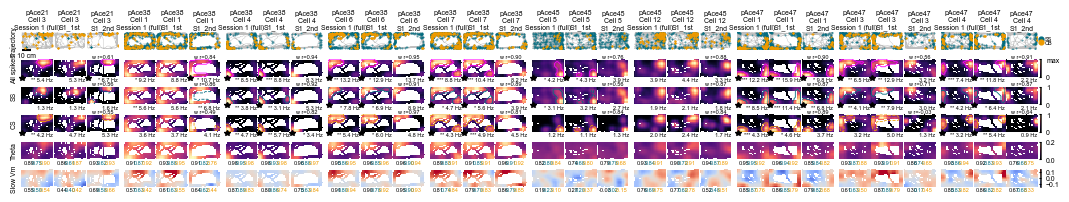

Plotting CS- comparison (n=8 cells, 3 conditions each, max 10/fig)
  Rendering CS-: n=8 -> spatial_compare_csminus_s1full_s1_1st_s1_2nd.svg
pAce21 Cell 1: CS PF mask is empty
pAce21 Cell 1: CS PF mask is empty
pAce38 Cell 5: CS PF mask is empty
pAce38 Cell 5: CS PF mask is empty
pAce38 Cell 5: CS PF mask is empty
pAce45 Cell 3: CS PF mask is empty
pAce45 Cell 3: CS PF mask is empty
pAce45 Cell 3: CS PF mask is empty
pAce45 Cell 6: CS PF mask is empty
pAce45 Cell 9: CS PF mask is empty
pAce45 Cell 9: CS PF mask is empty
pAce45 Cell 9: CS PF mask is empty
pAce46 Cell 7: CS PF mask is empty
pAce46 Cell 7: All spikes PF mask is empty
pAce46 Cell 7: SS PF mask is empty
pAce46 Cell 7: CS PF mask is empty
pAce47 Cell 2: CS PF mask is empty
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/spatial_compare_csminus_s1full_s1_1st_s1_2nd.svg


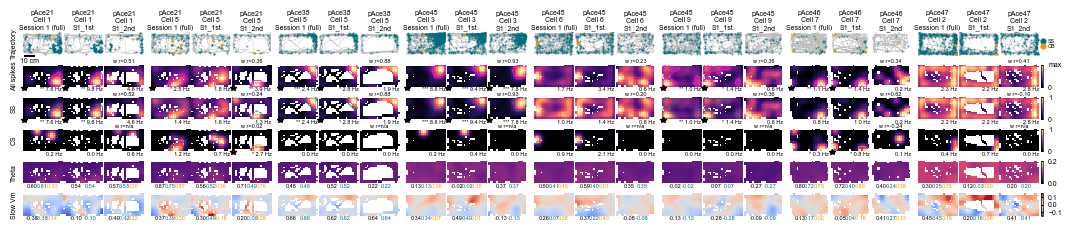

Plotting Non-PLC comparison (n=30 cells, 3 conditions each, max 10/fig)
  Rendering Non-PLC part 1/3: n=10 -> spatial_compare_nonplc_s1full_s1_1st_s1_2nd_part01.svg
pAce21 Cell 4: CS PF mask is empty
pAce21 Cell 4: CS PF mask is empty
pAce21 Cell 4: CS PF mask is empty
pAce21 Cell 7: SS PF mask is empty
pAce21 Cell 7: SS PF mask is empty
pAce21 Cell 8: All spikes PF mask is empty
pAce21 Cell 8: SS PF mask is empty
pAce21 Cell 8: CS PF mask is empty
pAce21 Cell 8: All spikes PF mask is empty
pAce21 Cell 8: SS PF mask is empty
pAce21 Cell 8: CS PF mask is empty
pAce21 Cell 8: CS PF mask is empty
pAce38 Cell 2: CS PF mask is empty
pAce38 Cell 2: CS PF mask is empty
pAce38 Cell 3: CS PF mask is empty
pAce38 Cell 3: CS PF mask is empty
pAce38 Cell 3: CS PF mask is empty
pAce38 Cell 8: CS PF mask is empty
pAce38 Cell 8: CS PF mask is empty
pAce38 Cell 8: CS PF mask is empty
pAce38 Cell 9: CS PF mask is empty
pAce38 Cell 9: CS PF mask is empty
pAce38 Cell 9: CS PF mask is empty
Saved: /Users/

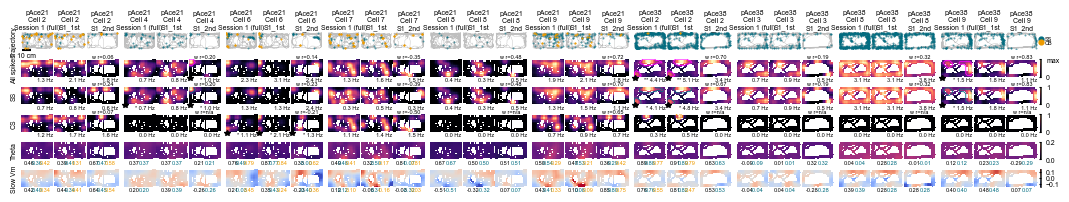

  Rendering Non-PLC part 2/3: n=10 -> spatial_compare_nonplc_s1full_s1_1st_s1_2nd_part02.svg
pAce45 Cell 4: CS PF mask is empty
pAce45 Cell 4: CS PF mask is empty
pAce45 Cell 7: CS PF mask is empty
pAce45 Cell 7: CS PF mask is empty
pAce45 Cell 7: CS PF mask is empty
pAce45 Cell 8: All spikes PF mask is empty
pAce45 Cell 8: SS PF mask is empty
pAce45 Cell 8: CS PF mask is empty
pAce45 Cell 8: CS PF mask is empty
pAce45 Cell 8: All spikes PF mask is empty
pAce45 Cell 8: SS PF mask is empty
pAce45 Cell 8: CS PF mask is empty
pAce45 Cell 10: CS PF mask is empty
pAce45 Cell 10: CS PF mask is empty
pAce45 Cell 10: CS PF mask is empty
pAce45 Cell 11: CS PF mask is empty
pAce45 Cell 11: CS PF mask is empty
pAce45 Cell 11: CS PF mask is empty
pAce45 Cell 13: CS PF mask is empty
pAce45 Cell 13: CS PF mask is empty
pAce45 Cell 13: CS PF mask is empty
pAce45 Cell 14: All spikes PF mask is empty
pAce45 Cell 14: SS PF mask is empty
pAce45 Cell 14: CS PF mask is empty
pAce45 Cell 14: SS PF mask is e

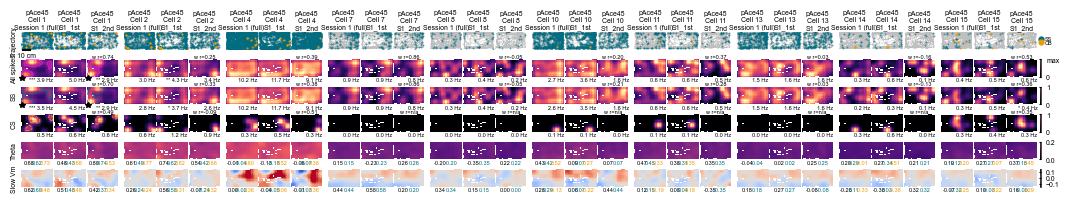

  Rendering Non-PLC part 3/3: n=10 -> spatial_compare_nonplc_s1full_s1_1st_s1_2nd_part03.svg
pAce45 Cell 16: CS PF mask is empty
pAce45 Cell 16: CS PF mask is empty
pAce45 Cell 16: CS PF mask is empty
pAce46 Cell 1: CS PF mask is empty
pAce46 Cell 1: CS PF mask is empty
pAce46 Cell 2: CS PF mask is empty
pAce46 Cell 2: CS PF mask is empty
pAce46 Cell 2: CS PF mask is empty
pAce46 Cell 3: CS PF mask is empty
pAce46 Cell 3: CS PF mask is empty
pAce46 Cell 5: CS PF mask is empty
pAce46 Cell 6: SS PF mask is empty
pAce46 Cell 6: CS PF mask is empty
pAce46 Cell 6: SS PF mask is empty
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/spatial_compare_nonplc_s1full_s1_1st_s1_2nd_part03.svg


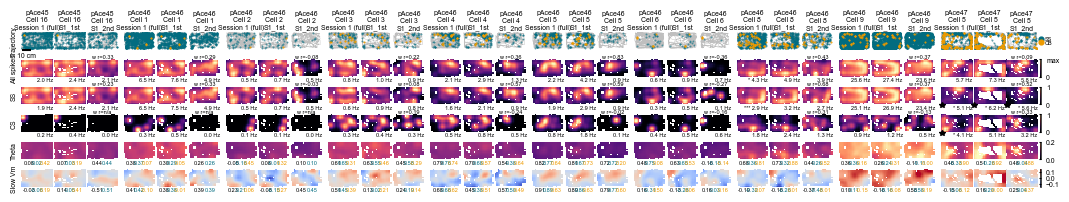

In [57]:

# Render figures
plot_putative_PF = True
show_place_cell_star = True
show_significance_marker = True

def _chunk_groups(groups, max_cells):
    if max_cells is None or max_cells <= 0:
        yield 1, groups
        return
    n = len(groups)
    if n == 0:
        return
    part = 1
    for i in range(0, n, max_cells):
        yield part, groups[i:i + max_cells]
        part += 1

def _render_group_set(groups, label, filename_base):
    n_cells = len(groups)
    if n_cells == 0:
        print(f"Skipping {label}: no cells")
        return []

    chunks = list(_chunk_groups(groups, MAX_CELLS_PER_FIG))
    n_parts = len(chunks)
    print(f"Plotting {label} comparison (n={n_cells} cells, {len(CONDITIONS)} conditions each, max {MAX_CELLS_PER_FIG}/fig)")

    saved_paths = []
    for part_idx, chunk in chunks:
        if n_parts == 1:
            out_name = f"{filename_base}.svg"
            part_msg = ""
        else:
            out_name = f"{filename_base}_part{part_idx:02d}.svg"
            part_msg = f" part {part_idx}/{n_parts}"

        out_path = os.path.join(FIGURE_SAVE_FOLDER, out_name)
        print(f"  Rendering {label}{part_msg}: n={len(chunk)} -> {out_name}")
        _ = plot_selected_cells_figure(
            cell_groups=chunk,
            theta_vlim=selected_theta_vlim,
            slow_vlim=selected_slow_vlim,
            save_path=out_path,
            plot_putative_PF=plot_putative_PF,
            show_place_cell_star=show_place_cell_star,
            show_significance_marker=show_significance_marker,
            plot_spike_shapes=PLOT_SPIKE_SHAPES,
            show_shape_counts=False,
        )
        saved_paths.append(out_path)

    return saved_paths

saved_csplus = _render_group_set(csplus_groups, 'CS+', 'spatial_compare_csplus_s1full_s1_1st_s1_2nd')
saved_csminus = _render_group_set(csminus_groups, 'CS-', 'spatial_compare_csminus_s1full_s1_1st_s1_2nd')
saved_nonplc = _render_group_set(nonpc_groups, 'Non-PLC', 'spatial_compare_nonplc_s1full_s1_1st_s1_2nd')


In [58]:

# QA summary
n_datasets = len(dataset_registry)
n_has_s2 = sum(1 for d in dataset_registry if d['has_session2'])
n_no_s2 = n_datasets - n_has_s2

print('=== Spatial S1 Half Compare Summary ===')
print(f'Total datasets: {n_datasets}')
print(f'Datasets with session 2 (combined source): {n_has_s2}')
print(f'Datasets without session 2 (combined source): {n_no_s2}')
print(f'Total valid spatial cells: {len(valid_spatial_cells)}')
print(f'CS+ count (combined labels): {len(csplus_keys)}')
print(f'CS- count (combined labels): {len(csminus_keys)}')
print(f'Non-PLC count (combined labels): {len(nonpc_keys)}')
print(f'Rendered CS+ rows: {len(csplus_groups)}')
print(f'Rendered CS- rows: {len(csminus_groups)}')
print(f'Rendered Non-PLC rows: {len(nonpc_groups)}')
print(f'Rendered rows with S1_2nd N/A (CS+): {csplus_missing_s1_2nd}')
print(f'Rendered rows with S1_2nd N/A (CS-): {csminus_missing_s1_2nd}')
print(f'Rendered rows with S1_2nd N/A (Non-PLC): {nonpc_missing_s1_2nd}')

print(f'Max cells per figure: {MAX_CELLS_PER_FIG}')
print(f'CS+ figures saved: {len(saved_csplus) if "saved_csplus" in globals() else 0}')
print(f'CS- figures saved: {len(saved_csminus) if "saved_csminus" in globals() else 0}')
print(f'Non-PLC figures saved: {len(saved_nonplc) if "saved_nonplc" in globals() else 0}')


=== Spatial S1 Half Compare Summary ===
Total datasets: 5
Datasets with session 2 (combined source): 4
Datasets without session 2 (combined source): 1
Total valid spatial cells: 48
CS+ count (combined labels): 10
CS- count (combined labels): 8
Non-PLC count (combined labels): 30
Rendered CS+ rows: 10
Rendered CS- rows: 8
Rendered Non-PLC rows: 30
Rendered rows with S1_2nd N/A (CS+): 0
Rendered rows with S1_2nd N/A (CS-): 0
Rendered rows with S1_2nd N/A (Non-PLC): 0
Max cells per figure: 10
CS+ figures saved: 1
CS- figures saved: 1
Non-PLC figures saved: 3


Low-SS outlier filter enabled: False (threshold=0.1)
Removed outlier cells: 0

=== All-Spike Maps (S1_1st vs S1_2nd) ===


,group,n_total_cells,n_with_s1_1st_and_s1_2nd,n_valid_corr,mean_r,median_r,std_r
0,CS+,10,10,10,0.832666,0.876739,0.127505
1,CS-,8,8,8,0.536047,0.442850,0.227175



=== Simple-Spike Maps (S1_1st vs S1_2nd) ===


,group,n_total_cells,n_with_s1_1st_and_s1_2nd,n_valid_corr,mean_r,median_r,std_r
0,CS+,10,10,10,0.796346,0.851520,0.144646
1,CS-,8,8,8,0.503087,0.460492,0.299333



=== Complex-Spike Maps (S1_1st vs S1_2nd, CS+ only) ===


,group,n_total_cells,n_with_s1_1st_and_s1_2nd,n_valid_corr,mean_r,median_r,std_r
0,CS+,10,10,10,0.686282,0.798934,0.263986


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1_1st_vs_s1_2nd_map_correlations.svg
CS+ SS vs CS test: paired_t, p=0.1871 (n=10; Shapiro diff p=0.68)
All-map CS+ vs CS- test: mannwhitney_u, p=0.01166 (Shapiro CS+ p=0.01759, CS- p=0.04405)
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1_1st_vs_s1_2nd_map_correlations.csv


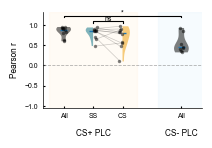

In [59]:
# S1_1st vs S1_2nd map correlations
# 1) All-spike maps: CS+ vs CS-
# 2) Simple-spike maps: CS+ vs CS-
# 3) Complex-spike maps: CS+ only

MIN_VALID_BINS_FOR_CORR = 20

def _get_session_pair_cell(dataset_id, cell_idx):
    c1 = _get_condition_cell(dataset_id, cell_idx, 's1_1st')
    c2 = _get_condition_cell(dataset_id, cell_idx, 's1_2nd')
    if c1 is None or c2 is None:
        return None, None
    c1 = copy.deepcopy(c1)
    c2 = copy.deepcopy(c2)
    # Ensure SS/CS normalized maps are condition-local before correlation.
    _renormalize_ss_cs_maps_per_condition(c1)
    _renormalize_ss_cs_maps_per_condition(c2)
    return c1, c2

def _map_pair_corr(map1, map2, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape:
        return np.nan, 0

    a = np.asarray(map1, dtype=float).ravel()
    b = np.asarray(map2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n_valid = int(np.sum(valid))

    if n_valid < int(min_valid_bins):
        return np.nan, n_valid

    x = a[valid]
    y = b[valid]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan, n_valid

    r = float(np.corrcoef(x, y)[0, 1])
    return r, n_valid

def _collect_session_corrs(cell_keys, map_key, group_label):
    rows = []
    for dataset_id, cell_idx in cell_keys:
        c1, c2 = _get_session_pair_cell(dataset_id, cell_idx)
        has_both_sessions = (c1 is not None) and (c2 is not None)

        if not has_both_sessions:
            rows.append({
                'dataset_id': dataset_id,
                'cell_idx': int(cell_idx),
                'group': group_label,
                'map_key': map_key,
                'has_both_sessions': False,
                'n_valid_bins': 0,
                'corr_r': np.nan,
            })
            continue

        r, n_valid = _map_pair_corr(
            c1.get(map_key, None),
            c2.get(map_key, None),
            min_valid_bins=MIN_VALID_BINS_FOR_CORR,
        )

        rows.append({
            'dataset_id': dataset_id,
            'cell_idx': int(cell_idx),
            'group': group_label,
            'map_key': map_key,
            'has_both_sessions': True,
            'n_valid_bins': int(n_valid),
            'corr_r': r,
        })

    return pd.DataFrame(rows)

def _summarize_corr_df(df, title):
    print(f"\n=== {title} ===")
    if df is None or len(df) == 0:
        print('No rows')
        return

    out_rows = []
    for g in sorted(df['group'].unique()):
        dfg = df[df['group'] == g].copy()
        n_total = int(len(dfg))
        n_with_s2 = int(dfg['has_both_sessions'].sum())
        dfg_valid = dfg[np.isfinite(dfg['corr_r'])]
        n_valid = int(len(dfg_valid))
        mean_r = float(np.nanmean(dfg_valid['corr_r'])) if n_valid > 0 else np.nan
        med_r = float(np.nanmedian(dfg_valid['corr_r'])) if n_valid > 0 else np.nan
        std_r = float(np.nanstd(dfg_valid['corr_r'], ddof=1)) if n_valid > 1 else np.nan

        out_rows.append({
            'group': g,
            'n_total_cells': n_total,
            'n_with_s1_1st_and_s1_2nd': n_with_s2,
            'n_valid_corr': n_valid,
            'mean_r': mean_r,
            'median_r': med_r,
            'std_r': std_r,
        })

    display(pd.DataFrame(out_rows))

# ---------------------------
# 1) All-spike map correlations
# ---------------------------
df_all_csplus = _collect_session_corrs(csplus_keys, 'rate_map', 'CS+')
df_all_csminus = _collect_session_corrs(csminus_keys, 'rate_map', 'CS-')
df_all_map = pd.concat([df_all_csplus, df_all_csminus], ignore_index=True)

# -----------------------------
# 2) Simple-spike map correlations
# -----------------------------
df_ss_csplus = _collect_session_corrs(csplus_keys, 'ss_norm_map', 'CS+')
df_ss_csminus = _collect_session_corrs(csminus_keys, 'ss_norm_map', 'CS-')
df_ss_map = pd.concat([df_ss_csplus, df_ss_csminus], ignore_index=True)

# ------------------------------
# 3) Complex-spike map correlations (CS+ only)
# ------------------------------
df_cs_map = _collect_session_corrs(csplus_keys, 'cs_norm_map', 'CS+')


def _row_keys(df):
    if df is None or len(df) == 0:
        return []
    return list(zip(df['dataset_id'].astype(str), df['cell_idx'].astype(int)))


def _exclude_rows_by_keys(df, exclude_keys):
    if df is None:
        return df
    if not exclude_keys or len(df) == 0:
        return df.copy()
    keep_mask = [k not in exclude_keys for k in _row_keys(df)]
    return df.loc[np.asarray(keep_mask, dtype=bool)].reset_index(drop=True)


# Optional outlier removal by low SS-map correlation
REMOVE_LOW_SS_OUTLIER_LOCAL = bool(globals().get('REMOVE_LOW_SS_OUTLIER', True))
SS_R_OUTLIER_THRESHOLD_LOCAL = float(globals().get('SS_R_OUTLIER_THRESHOLD', 0.1))

outlier_keys = set()
if REMOVE_LOW_SS_OUTLIER_LOCAL:
    outlier_df = df_ss_map[np.isfinite(df_ss_map['corr_r']) & (df_ss_map['corr_r'] < SS_R_OUTLIER_THRESHOLD_LOCAL)]
    outlier_keys = set(_row_keys(outlier_df))

    if len(outlier_keys) > 0:
        df_all_csplus = _exclude_rows_by_keys(df_all_csplus, outlier_keys)
        df_all_csminus = _exclude_rows_by_keys(df_all_csminus, outlier_keys)
        df_ss_csplus = _exclude_rows_by_keys(df_ss_csplus, outlier_keys)
        df_ss_csminus = _exclude_rows_by_keys(df_ss_csminus, outlier_keys)
        df_cs_map = _exclude_rows_by_keys(df_cs_map, outlier_keys)

    df_all_map = pd.concat([df_all_csplus, df_all_csminus], ignore_index=True)
    df_ss_map = pd.concat([df_ss_csplus, df_ss_csminus], ignore_index=True)

print(f"Low-SS outlier filter enabled: {REMOVE_LOW_SS_OUTLIER_LOCAL} (threshold={SS_R_OUTLIER_THRESHOLD_LOCAL})")
print(f"Removed outlier cells: {len(outlier_keys)}")

_summarize_corr_df(df_all_map, 'All-Spike Maps (S1_1st vs S1_2nd)')
_summarize_corr_df(df_ss_map, 'Simple-Spike Maps (S1_1st vs S1_2nd)')
_summarize_corr_df(df_cs_map, 'Complex-Spike Maps (S1_1st vs S1_2nd, CS+ only)')


# Combine 1-4 style grouped visualization
all_color = 'black'
ss_color = '#026C80'
cs_color = '#EE9B00'
cs_plc_bg_local = globals().get('cs_plc_bg', globals().get('cs_plc_bg_color', '#FFF3E0'))
non_cs_plc_bg_local = globals().get('non_cs_plc_bg', globals().get('non_cs_plc_bg_color', '#E3F2FD'))

VIOLIN_MEDIAN_COLOR = '#1F77B4'
VIOLIN_MEDIAN_LINEWIDTH = 1.0


def _style_violin_medians(parts, color=None, linewidth=None):
    if color is None:
        color = VIOLIN_MEDIAN_COLOR
    if linewidth is None:
        linewidth = VIOLIN_MEDIAN_LINEWIDTH
    if 'cmedians' in parts:
        parts['cmedians'].set_color(color)
        parts['cmedians'].set_linewidth(linewidth)


def _finite_values(df):
    arr = np.asarray(df['corr_r'], dtype=float)
    return arr[np.isfinite(arr)]


def _paired_valid(df_a, df_b):
    ma = df_a[['dataset_id', 'cell_idx', 'corr_r']].rename(columns={'corr_r': 'a'})
    mb = df_b[['dataset_id', 'cell_idx', 'corr_r']].rename(columns={'corr_r': 'b'})
    m = ma.merge(mb, on=['dataset_id', 'cell_idx'], how='inner')
    m = m[np.isfinite(m['a']) & np.isfinite(m['b'])]
    return m


try:
    import scipy.stats as scipy_stats
except Exception:
    scipy_stats = None


def _shapiro_p_safe(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    n = int(arr.size)
    if scipy_stats is None or n < 3:
        return np.nan
    try:
        # Shapiro is most stable up to ~5000 samples.
        if n > 5000:
            rng = np.random.default_rng(0)
            arr = rng.choice(arr, size=5000, replace=False)
        return float(scipy_stats.shapiro(arr).pvalue)
    except Exception:
        return np.nan


def _auto_unpaired_test(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    n1, n2 = int(x.size), int(y.size)
    if scipy_stats is None or n1 < 2 or n2 < 2:
        return np.nan, 'n/a', np.nan, np.nan

    shapiro_p1 = _shapiro_p_safe(x)
    shapiro_p2 = _shapiro_p_safe(y)

    can_parametric = (
        n1 >= 5 and n2 >= 5 and
        np.isfinite(shapiro_p1) and shapiro_p1 >= alpha and
        np.isfinite(shapiro_p2) and shapiro_p2 >= alpha
    )

    if can_parametric:
        try:
            _stat, p = scipy_stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
            return float(p), 'welch_t', shapiro_p1, shapiro_p2
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.mannwhitneyu(x, y, alternative='two-sided')
        return float(p), 'mannwhitney_u', shapiro_p1, shapiro_p2
    except Exception:
        return np.nan, 'mannwhitney_u', shapiro_p1, shapiro_p2


def _auto_paired_test(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    n = int(x.size)
    if scipy_stats is None or n < 2:
        return np.nan, 'n/a', np.nan

    shapiro_p = _shapiro_p_safe(x - y)
    can_parametric = (n >= 5 and np.isfinite(shapiro_p) and shapiro_p >= alpha)

    if can_parametric:
        try:
            _stat, p = scipy_stats.ttest_rel(x, y, nan_policy='omit')
            return float(p), 'paired_t', shapiro_p
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.wilcoxon(x, y, alternative='two-sided')
        return float(p), 'wilcoxon', shapiro_p
    except Exception:
        return np.nan, 'wilcoxon', shapiro_p


def _p_value_unpaired(x, y):
    return _auto_unpaired_test(x, y, alpha=0.05)


def _p_value_paired(x, y):
    return _auto_paired_test(x, y, alpha=0.05)


def _sig_label(p):
    if not np.isfinite(p):
        return 'n/a'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


def add_bracket(ax, x1, x2, y, h, label, color='black'):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color=color, linewidth=0.8)
    ax.text((x1 + x2) / 2.0, y + h, label, ha='center', va='bottom', fontsize=5, fontname='Arial', color=color)


def _draw_violin(ax, arr, pos, color, half=None, alpha=0.5):
    if len(arr) < 3:
        return
    parts = ax.violinplot([arr], positions=[pos], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    body = parts['bodies'][0]
    body.set_facecolor(color)
    body.set_edgecolor('none')
    body.set_alpha(alpha)

    if half in ('left', 'right'):
        verts = body.get_paths()[0].vertices
        segs = parts['cmedians'].get_segments()
        if half == 'left':
            verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
            segs[0][:, 0] = np.clip(segs[0][:, 0], -np.inf, pos)
        else:
            verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
            segs[0][:, 0] = np.clip(segs[0][:, 0], pos, np.inf)
        parts['cmedians'].set_segments(segs)


def _scatter_side(ax, arr, pos, direction='center', rng_seed=0):
    if len(arr) == 0:
        return
    rng = np.random.default_rng(rng_seed)
    if direction == 'right':
        x = pos + 0.02 + rng.random(len(arr)) * 0.12
    elif direction == 'left':
        x = pos - 0.02 - rng.random(len(arr)) * 0.12
    else:
        x = pos + (rng.random(len(arr)) - 0.5) * 0.14
    ax.scatter(x, arr, s=6, color='black', alpha=0.5, linewidths=0, zorder=3)


all_csplus_vals = _finite_values(df_all_csplus)
all_csminus_vals = _finite_values(df_all_csminus)
ss_csplus_vals = _finite_values(df_ss_csplus)
cs_csplus_vals = _finite_values(df_cs_map)

paired_ss_cs = _paired_valid(df_ss_csplus, df_cs_map)
p_ss_vs_cs, paired_test_name, paired_shapiro_p = _p_value_paired(paired_ss_cs['a'].to_numpy(dtype=float), paired_ss_cs['b'].to_numpy(dtype=float))
p_all_csplus_vs_csminus, unpaired_test_name, unpaired_shapiro_p1, unpaired_shapiro_p2 = _p_value_unpaired(all_csplus_vals, all_csminus_vals)

panel_w, panel_h = 2.1, 1.5
fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h))

# Background shading and group labels (Combine 1-4 style)
ax.axvspan(0.5, 3.5, alpha=0.3, color=cs_plc_bg_local, zorder=0)
ax.axvspan(4.2, 5.8, alpha=0.3, color=non_cs_plc_bg_local, zorder=0)
ax.text(2.0, -0.22, 'CS+ PLC', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())
ax.text(5.0, -0.22, 'CS- PLC', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())

# Violin bodies
_draw_violin(ax, all_csplus_vals, 1.0, all_color, half=None, alpha=0.5)
_draw_violin(ax, ss_csplus_vals, 2.0, ss_color, half='left', alpha=0.5)
_draw_violin(ax, cs_csplus_vals, 3.0, cs_color, half='right', alpha=0.5)
_draw_violin(ax, all_csminus_vals, 5.0, all_color, half=None, alpha=0.5)

# Paired lines for CS+ SS vs CS
if len(paired_ss_cs) > 0:
    a = paired_ss_cs['a'].to_numpy(dtype=float)
    b = paired_ss_cs['b'].to_numpy(dtype=float)
    for va, vb in zip(a, b):
        ax.plot([2.08, 2.92], [va, vb], color='black', alpha=0.2, linewidth=0.5, zorder=2)

# Dots
_scatter_side(ax, all_csplus_vals, 1.0, direction='center', rng_seed=1)
_scatter_side(ax, ss_csplus_vals, 2.0, direction='right', rng_seed=2)
_scatter_side(ax, cs_csplus_vals, 3.0, direction='left', rng_seed=3)
_scatter_side(ax, all_csminus_vals, 5.0, direction='center', rng_seed=4)

ax.axhline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.6)
ax.set_ylabel('Pearson r', fontsize=6, fontname='Arial')
ax.set_xticks([1.0, 2.0, 3.0, 5.0])
ax.set_xticklabels(['All', 'SS', 'CS', 'All'], fontsize=4, fontname='Arial')
ax.set_xlim(0.3, 5.7)
ax.tick_params(axis='both', labelsize=5)
for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
    label.set_fontname('Arial')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Brackets and significance labels
plot_max = np.nanmax(np.concatenate([
    all_csplus_vals if len(all_csplus_vals) else np.array([-1.0]),
    ss_csplus_vals if len(ss_csplus_vals) else np.array([-1.0]),
    cs_csplus_vals if len(cs_csplus_vals) else np.array([-1.0]),
    all_csminus_vals if len(all_csminus_vals) else np.array([-1.0]),
]))
y_top = max(0.85, float(plot_max) + 0.08)
h = 0.04
add_bracket(ax, 2.0, 3.0, y_top, h, _sig_label(p_ss_vs_cs), color='black')
add_bracket(ax, 1.0, 5.0, y_top + 0.14, h, _sig_label(p_all_csplus_vs_csminus), color=all_color)
ax.set_ylim(-1.05, y_top + 0.26)

plt.tight_layout()
corr_fig_path = os.path.join(FIGURE_SAVE_FOLDER, 's1_1st_vs_s1_2nd_map_correlations.svg')
fig.savefig(corr_fig_path, dpi=300)
print(f"Saved: {corr_fig_path}")
print(f"CS+ SS vs CS test: {paired_test_name}, p={p_ss_vs_cs:.4g} (n={len(paired_ss_cs)}; Shapiro diff p={paired_shapiro_p:.4g})")
print(f"All-map CS+ vs CS- test: {unpaired_test_name}, p={p_all_csplus_vs_csminus:.4g} (Shapiro CS+ p={unpaired_shapiro_p1:.4g}, CS- p={unpaired_shapiro_p2:.4g})")

# Save tables for downstream stats if needed
corr_table_path = os.path.join(FIGURE_SAVE_FOLDER, 's1_1st_vs_s1_2nd_map_correlations.csv')
df_out = pd.concat([
    df_all_map.assign(metric='all_spike_map'),
    df_ss_map.assign(metric='simple_spike_map'),
    df_cs_map.assign(metric='complex_spike_map'),
], ignore_index=True)
df_out.to_csv(corr_table_path, index=False)
print(f"Saved: {corr_table_path}")


Low-SS outlier filter enabled: False (threshold=0.1)
Weighted analysis outlier source: weighted_ss_map
Removed outlier cells: 0
Remaining weighted SS r below threshold after filtering: 1

=== Occupancy-weighted All-Spike Maps (S1_1st vs S1_2nd) ===


,group,n_total_cells,n_with_s1_1st_and_s1_2nd,n_valid_weighted_corr,mean_weighted_r,median_weighted_r,mean_n_eff
0,CS+,10,10,10,0.825605,0.888013,168.564658
1,CS-,8,8,8,0.501756,0.384210,193.558603



=== Occupancy-weighted Simple-Spike Maps (S1_1st vs S1_2nd) ===


,group,n_total_cells,n_with_s1_1st_and_s1_2nd,n_valid_weighted_corr,mean_weighted_r,median_weighted_r,mean_n_eff
0,CS+,10,10,10,0.802992,0.869887,168.564658
1,CS-,8,8,8,0.455283,0.437990,193.558603



=== Occupancy-weighted Complex-Spike Maps (S1_1st vs S1_2nd, CS+ only) ===


,group,n_total_cells,n_with_s1_1st_and_s1_2nd,n_valid_weighted_corr,mean_weighted_r,median_weighted_r,mean_n_eff
0,CS+,10,10,10,0.682483,0.815199,168.564658


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1_1st_vs_s1_2nd_map_correlations_weighted.svg
Weighted CS+ SS vs CS test: paired_t, p=0.203 (n=10; Shapiro diff p=0.2527)
Weighted All-map CS+ vs CS- test: mannwhitney_u, p=0.01166 (Shapiro CS+ p=0.0244, CS- p=0.04035)
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1_1st_vs_s1_2nd_map_correlations_weighted.csv


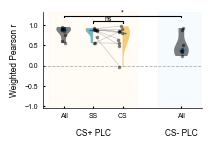

In [60]:
# S1_1st vs S1_2nd map correlations (occupancy-weighted Pearson r)
# Weight per bin: min(occupancy_s1_1st, occupancy_s1_2nd)

MIN_VALID_BINS_FOR_CORR_WEIGHTED = 20
MIN_EFFECTIVE_BINS_WEIGHTED = 20
MIN_OCCUPANCY_WEIGHT = 0.0


def _weighted_pearson_2d(map1, map2, occ1, occ2,
                         min_occ=0.0,
                         min_valid_bins=20,
                         min_eff_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0, 0.0
    if not isinstance(occ1, np.ndarray) or not isinstance(occ2, np.ndarray):
        return np.nan, 0, 0.0
    if map1.shape != map2.shape or map1.shape != occ1.shape or map1.shape != occ2.shape:
        return np.nan, 0, 0.0

    x = np.asarray(map1, dtype=float).ravel()
    y = np.asarray(map2, dtype=float).ravel()
    w = np.minimum(np.asarray(occ1, dtype=float).ravel(), np.asarray(occ2, dtype=float).ravel())

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > float(min_occ))
    n_valid = int(np.sum(valid))
    if n_valid < int(min_valid_bins):
        return np.nan, n_valid, 0.0

    x = x[valid]
    y = y[valid]
    w = w[valid]

    sw = float(np.sum(w))
    if sw <= 0:
        return np.nan, n_valid, 0.0

    mx = float(np.sum(w * x) / sw)
    my = float(np.sum(w * y) / sw)
    dx = x - mx
    dy = y - my

    num = float(np.sum(w * dx * dy))
    den_x = float(np.sum(w * dx * dx))
    den_y = float(np.sum(w * dy * dy))
    den = np.sqrt(den_x * den_y)
    if den <= 0:
        return np.nan, n_valid, 0.0

    # Effective sample size under unequal weights
    sw2 = float(np.sum(w * w))
    n_eff = (sw * sw / sw2) if sw2 > 0 else 0.0
    if n_eff < float(min_eff_bins):
        return np.nan, n_valid, n_eff

    r_w = num / den
    return float(r_w), n_valid, float(n_eff)


def _collect_weighted_session_corrs(cell_keys, map_key, group_label):
    rows = []
    for dataset_id, cell_idx in cell_keys:
        c1 = _get_condition_cell(dataset_id, cell_idx, 's1_1st')
        c2 = _get_condition_cell(dataset_id, cell_idx, 's1_2nd')

        if c1 is None or c2 is None:
            rows.append({
                'dataset_id': dataset_id,
                'cell_idx': int(cell_idx),
                'group': group_label,
                'map_key': map_key,
                'has_both_sessions': False,
                'n_valid_bins': 0,
                'n_eff_bins': 0.0,
                'corr_r_weighted': np.nan,
            })
            continue

        c1 = copy.deepcopy(c1)
        c2 = copy.deepcopy(c2)
        _renormalize_ss_cs_maps_per_condition(c1)
        _renormalize_ss_cs_maps_per_condition(c2)

        r_w, n_valid, n_eff = _weighted_pearson_2d(
            c1.get(map_key, None),
            c2.get(map_key, None),
            c1.get('occupancy', None),
            c2.get('occupancy', None),
            min_occ=MIN_OCCUPANCY_WEIGHT,
            min_valid_bins=MIN_VALID_BINS_FOR_CORR_WEIGHTED,
            min_eff_bins=MIN_EFFECTIVE_BINS_WEIGHTED,
        )

        rows.append({
            'dataset_id': dataset_id,
            'cell_idx': int(cell_idx),
            'group': group_label,
            'map_key': map_key,
            'has_both_sessions': True,
            'n_valid_bins': int(n_valid),
            'n_eff_bins': float(n_eff),
            'corr_r_weighted': r_w,
        })

    return pd.DataFrame(rows)


def _summarize_weighted_corr_df(df, title):
    print(f"\n=== {title} ===")
    if df is None or len(df) == 0:
        print('No rows')
        return

    out_rows = []
    for g in sorted(df['group'].unique()):
        dfg = df[df['group'] == g].copy()
        n_total = int(len(dfg))
        n_with_s2 = int(dfg['has_both_sessions'].sum())
        dfg_valid = dfg[np.isfinite(dfg['corr_r_weighted'])]
        n_valid = int(len(dfg_valid))
        mean_r = float(np.nanmean(dfg_valid['corr_r_weighted'])) if n_valid > 0 else np.nan
        med_r = float(np.nanmedian(dfg_valid['corr_r_weighted'])) if n_valid > 0 else np.nan
        mean_neff = float(np.nanmean(dfg_valid['n_eff_bins'])) if n_valid > 0 else np.nan

        out_rows.append({
            'group': g,
            'n_total_cells': n_total,
            'n_with_s1_1st_and_s1_2nd': n_with_s2,
            'n_valid_weighted_corr': n_valid,
            'mean_weighted_r': mean_r,
            'median_weighted_r': med_r,
            'mean_n_eff': mean_neff,
        })

    display(pd.DataFrame(out_rows))


# Compute weighted correlations for the same map sets
w_all_csplus = _collect_weighted_session_corrs(csplus_keys, 'rate_map', 'CS+')
w_all_csminus = _collect_weighted_session_corrs(csminus_keys, 'rate_map', 'CS-')
df_all_map_w = pd.concat([w_all_csplus, w_all_csminus], ignore_index=True)

w_ss_csplus = _collect_weighted_session_corrs(csplus_keys, 'ss_norm_map', 'CS+')
w_ss_csminus = _collect_weighted_session_corrs(csminus_keys, 'ss_norm_map', 'CS-')
df_ss_map_w = pd.concat([w_ss_csplus, w_ss_csminus], ignore_index=True)

w_cs_map = _collect_weighted_session_corrs(csplus_keys, 'cs_norm_map', 'CS+')


def _row_keys_w(df):
    if df is None or len(df) == 0:
        return []
    return list(zip(df['dataset_id'].astype(str), df['cell_idx'].astype(int)))


def _exclude_rows_by_keys_w(df, exclude_keys):
    if df is None:
        return df
    if not exclude_keys or len(df) == 0:
        return df.copy()
    keep_mask = [k not in exclude_keys for k in _row_keys_w(df)]
    return df.loc[np.asarray(keep_mask, dtype=bool)].reset_index(drop=True)


REMOVE_LOW_SS_OUTLIER_LOCAL = bool(globals().get('REMOVE_LOW_SS_OUTLIER', True))
SS_R_OUTLIER_THRESHOLD_LOCAL = float(globals().get('SS_R_OUTLIER_THRESHOLD', 0.1))

outlier_keys_w = set()
if REMOVE_LOW_SS_OUTLIER_LOCAL:
    # Weighted figure should be filtered by weighted SS map r directly.
    outlier_df_w = df_ss_map_w[
        np.isfinite(df_ss_map_w['corr_r_weighted'])
        & (df_ss_map_w['corr_r_weighted'] < SS_R_OUTLIER_THRESHOLD_LOCAL)
    ]
    outlier_keys_w = set(_row_keys_w(outlier_df_w))

    if len(outlier_keys_w) > 0:
        w_all_csplus = _exclude_rows_by_keys_w(w_all_csplus, outlier_keys_w)
        w_all_csminus = _exclude_rows_by_keys_w(w_all_csminus, outlier_keys_w)
        w_ss_csplus = _exclude_rows_by_keys_w(w_ss_csplus, outlier_keys_w)
        w_ss_csminus = _exclude_rows_by_keys_w(w_ss_csminus, outlier_keys_w)
        w_cs_map = _exclude_rows_by_keys_w(w_cs_map, outlier_keys_w)

    df_all_map_w = pd.concat([w_all_csplus, w_all_csminus], ignore_index=True)
    df_ss_map_w = pd.concat([w_ss_csplus, w_ss_csminus], ignore_index=True)

print(f"Low-SS outlier filter enabled: {REMOVE_LOW_SS_OUTLIER_LOCAL} (threshold={SS_R_OUTLIER_THRESHOLD_LOCAL})")
print(f"Weighted analysis outlier source: weighted_ss_map")
print(f"Removed outlier cells: {len(outlier_keys_w)}")
remaining_low_ss_w = int(np.sum(np.isfinite(df_ss_map_w['corr_r_weighted']) & (df_ss_map_w['corr_r_weighted'] < SS_R_OUTLIER_THRESHOLD_LOCAL)))
print(f"Remaining weighted SS r below threshold after filtering: {remaining_low_ss_w}")

_summarize_weighted_corr_df(df_all_map_w, 'Occupancy-weighted All-Spike Maps (S1_1st vs S1_2nd)')
_summarize_weighted_corr_df(df_ss_map_w, 'Occupancy-weighted Simple-Spike Maps (S1_1st vs S1_2nd)')
_summarize_weighted_corr_df(w_cs_map, 'Occupancy-weighted Complex-Spike Maps (S1_1st vs S1_2nd, CS+ only)')


# ---- Figure (same layout style as the unweighted grouped panel) ----
all_color = 'black'
ss_color = '#026C80'
cs_color = '#EE9B00'
cs_plc_bg_local = globals().get('cs_plc_bg', globals().get('cs_plc_bg_color', '#FFF3E0'))
non_cs_plc_bg_local = globals().get('non_cs_plc_bg', globals().get('non_cs_plc_bg_color', '#E3F2FD'))

if '_style_violin_medians' not in globals():
    def _style_violin_medians(parts, color='#1F77B4', linewidth=1.0):
        if 'cmedians' in parts:
            parts['cmedians'].set_color(color)
            parts['cmedians'].set_linewidth(linewidth)


def _finite_weighted(df):
    arr = np.asarray(df['corr_r_weighted'], dtype=float)
    return arr[np.isfinite(arr)]


def _paired_weighted(df_a, df_b):
    ma = df_a[['dataset_id', 'cell_idx', 'corr_r_weighted']].rename(columns={'corr_r_weighted': 'a'})
    mb = df_b[['dataset_id', 'cell_idx', 'corr_r_weighted']].rename(columns={'corr_r_weighted': 'b'})
    m = ma.merge(mb, on=['dataset_id', 'cell_idx'], how='inner')
    m = m[np.isfinite(m['a']) & np.isfinite(m['b'])]
    return m


try:
    import scipy.stats as scipy_stats
except Exception:
    scipy_stats = None


def _shapiro_p_safe(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    n = int(arr.size)
    if scipy_stats is None or n < 3:
        return np.nan
    try:
        # Shapiro is most stable up to ~5000 samples.
        if n > 5000:
            rng = np.random.default_rng(0)
            arr = rng.choice(arr, size=5000, replace=False)
        return float(scipy_stats.shapiro(arr).pvalue)
    except Exception:
        return np.nan


def _auto_unpaired_test(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    n1, n2 = int(x.size), int(y.size)
    if scipy_stats is None or n1 < 2 or n2 < 2:
        return np.nan, 'n/a', np.nan, np.nan

    shapiro_p1 = _shapiro_p_safe(x)
    shapiro_p2 = _shapiro_p_safe(y)

    can_parametric = (
        n1 >= 5 and n2 >= 5 and
        np.isfinite(shapiro_p1) and shapiro_p1 >= alpha and
        np.isfinite(shapiro_p2) and shapiro_p2 >= alpha
    )

    if can_parametric:
        try:
            _stat, p = scipy_stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
            return float(p), 'welch_t', shapiro_p1, shapiro_p2
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.mannwhitneyu(x, y, alternative='two-sided')
        return float(p), 'mannwhitney_u', shapiro_p1, shapiro_p2
    except Exception:
        return np.nan, 'mannwhitney_u', shapiro_p1, shapiro_p2


def _auto_paired_test(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    n = int(x.size)
    if scipy_stats is None or n < 2:
        return np.nan, 'n/a', np.nan

    shapiro_p = _shapiro_p_safe(x - y)
    can_parametric = (n >= 5 and np.isfinite(shapiro_p) and shapiro_p >= alpha)

    if can_parametric:
        try:
            _stat, p = scipy_stats.ttest_rel(x, y, nan_policy='omit')
            return float(p), 'paired_t', shapiro_p
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.wilcoxon(x, y, alternative='two-sided')
        return float(p), 'wilcoxon', shapiro_p
    except Exception:
        return np.nan, 'wilcoxon', shapiro_p


def _p_value_unpaired(x, y):
    return _auto_unpaired_test(x, y, alpha=0.05)


def _p_value_paired(x, y):
    return _auto_paired_test(x, y, alpha=0.05)


def _sig_label(p):
    if not np.isfinite(p):
        return 'n/a'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


def add_bracket(ax, x1, x2, y, h, label, color='black'):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color=color, linewidth=0.8)
    ax.text((x1 + x2) / 2.0, y + h, label, ha='center', va='bottom', fontsize=5, fontname='Arial', color=color)


def _draw_violin(ax, arr, pos, color, half=None, alpha=0.5):
    if len(arr) < 3:
        return
    parts = ax.violinplot([arr], positions=[pos], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    body = parts['bodies'][0]
    body.set_facecolor(color)
    body.set_edgecolor('none')
    body.set_alpha(alpha)

    if half in ('left', 'right'):
        verts = body.get_paths()[0].vertices
        segs = parts['cmedians'].get_segments()
        if half == 'left':
            verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
            segs[0][:, 0] = np.clip(segs[0][:, 0], -np.inf, pos)
        else:
            verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
            segs[0][:, 0] = np.clip(segs[0][:, 0], pos, np.inf)
        parts['cmedians'].set_segments(segs)


def _scatter_side(ax, arr, pos, direction='center', rng_seed=0):
    if len(arr) == 0:
        return
    rng = np.random.default_rng(rng_seed)
    if direction == 'right':
        x = pos + 0.02 + rng.random(len(arr)) * 0.12
    elif direction == 'left':
        x = pos - 0.02 - rng.random(len(arr)) * 0.12
    else:
        x = pos + (rng.random(len(arr)) - 0.5) * 0.14
    ax.scatter(x, arr, s=6, color='black', alpha=0.5, linewidths=0, zorder=3)


all_csplus_w = _finite_weighted(w_all_csplus)
all_csminus_w = _finite_weighted(w_all_csminus)
ss_csplus_w = _finite_weighted(w_ss_csplus)
cs_csplus_w = _finite_weighted(w_cs_map)

paired_w = _paired_weighted(w_ss_csplus, w_cs_map)
p_ss_vs_cs_w, paired_test_name_w, paired_shapiro_p_w = _p_value_paired(paired_w['a'].to_numpy(dtype=float), paired_w['b'].to_numpy(dtype=float))
p_all_csplus_vs_csminus_w, unpaired_test_name_w, unpaired_shapiro_p1_w, unpaired_shapiro_p2_w = _p_value_unpaired(all_csplus_w, all_csminus_w)

panel_w, panel_h = 2.1, 1.5
fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h))

ax.axvspan(0.5, 3.5, alpha=0.3, color=cs_plc_bg_local, zorder=0)
ax.axvspan(4.2, 5.8, alpha=0.3, color=non_cs_plc_bg_local, zorder=0)
ax.text(2.0, -0.22, 'CS+ PLC', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())
ax.text(5.0, -0.22, 'CS- PLC', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())

_draw_violin(ax, all_csplus_w, 1.0, all_color, half=None, alpha=0.5)
_draw_violin(ax, ss_csplus_w, 2.0, ss_color, half='left', alpha=0.5)
_draw_violin(ax, cs_csplus_w, 3.0, cs_color, half='right', alpha=0.5)
_draw_violin(ax, all_csminus_w, 5.0, all_color, half=None, alpha=0.5)

if len(paired_w) > 0:
    a = paired_w['a'].to_numpy(dtype=float)
    b = paired_w['b'].to_numpy(dtype=float)
    for va, vb in zip(a, b):
        ax.plot([2.08, 2.92], [va, vb], color='black', alpha=0.2, linewidth=0.5, zorder=2)

_scatter_side(ax, all_csplus_w, 1.0, direction='center', rng_seed=11)
_scatter_side(ax, ss_csplus_w, 2.0, direction='right', rng_seed=12)
_scatter_side(ax, cs_csplus_w, 3.0, direction='left', rng_seed=13)
_scatter_side(ax, all_csminus_w, 5.0, direction='center', rng_seed=14)

ax.axhline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.6)
ax.set_ylabel('Weighted Pearson r', fontsize=6, fontname='Arial')
ax.set_xticks([1.0, 2.0, 3.0, 5.0])
ax.set_xticklabels(['All', 'SS', 'CS', 'All'], fontsize=4, fontname='Arial')
ax.set_xlim(0.3, 5.7)
ax.tick_params(axis='both', labelsize=5)
for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
    label.set_fontname('Arial')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plot_max = np.nanmax(np.concatenate([
    all_csplus_w if len(all_csplus_w) else np.array([-1.0]),
    ss_csplus_w if len(ss_csplus_w) else np.array([-1.0]),
    cs_csplus_w if len(cs_csplus_w) else np.array([-1.0]),
    all_csminus_w if len(all_csminus_w) else np.array([-1.0]),
]))
y_top = max(0.85, float(plot_max) + 0.08)
h = 0.04
add_bracket(ax, 2.0, 3.0, y_top, h, _sig_label(p_ss_vs_cs_w), color='black')
add_bracket(ax, 1.0, 5.0, y_top + 0.14, h, _sig_label(p_all_csplus_vs_csminus_w), color=all_color)
ax.set_ylim(-1.05, y_top + 0.26)

plt.tight_layout()
weighted_fig_path = os.path.join(FIGURE_SAVE_FOLDER, 's1_1st_vs_s1_2nd_map_correlations_weighted.svg')
fig.savefig(weighted_fig_path, dpi=300)
print(f"Saved: {weighted_fig_path}")
print(f"Weighted CS+ SS vs CS test: {paired_test_name_w}, p={p_ss_vs_cs_w:.4g} (n={len(paired_w)}; Shapiro diff p={paired_shapiro_p_w:.4g})")
print(f"Weighted All-map CS+ vs CS- test: {unpaired_test_name_w}, p={p_all_csplus_vs_csminus_w:.4g} (Shapiro CS+ p={unpaired_shapiro_p1_w:.4g}, CS- p={unpaired_shapiro_p2_w:.4g})")

weighted_table_path = os.path.join(FIGURE_SAVE_FOLDER, 's1_1st_vs_s1_2nd_map_correlations_weighted.csv')
df_out_w = pd.concat([
    df_all_map_w.assign(metric='all_spike_map'),
    df_ss_map_w.assign(metric='simple_spike_map'),
    w_cs_map.assign(metric='complex_spike_map'),
], ignore_index=True)
df_out_w.to_csv(weighted_table_path, index=False)
print(f"Saved: {weighted_table_path}")


=== CS+ expansion from SI-shuffle-significant non-PLC cells ===
Non-PLC cells total: 30
Non-PLC SI-shuffle-significant ("*"): 5
Among them CS+ (CB in-PF >= 10): 2
CS+ fraction within tuned non-PLC: 40.0%
Original CS+ PLC count: 10
Combined CS+ pool (PLC + tuned non-PLC): 12
SI significance key usage: {'p_value': 5}
Low-SS outlier filter enabled: False (threshold=0.1)
Removed outlier cells from expanded CS+ SS-vs-CS comparison: 0

=== SS vs CS map-correlation in expanded CS+ pool ===
Valid paired cells for SS-vs-CS: 12
Test: paired_t, p=0.06156, Shapiro(diff) p=0.9693


,source_class,n_cells
0,CS+ PLC,10
1,CS+ tuned non-PLC,2


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1_1st_vs_s1_2nd_csplus_expanded_ss_vs_cs.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1_1st_vs_s1_2nd_csplus_expanded_ss_vs_cs.csv
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/csplus_tuned_nonplc_candidates.csv


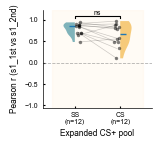

In [61]:
# CS+ PLC + CS+ spatially tuned non-PLC analysis
# Spatially tuned non-PLC = SI-shuffle significant ('*') but not place cell.

SI_ALPHA = 0.05
MIN_VALID_BINS_FOR_CORR_EXT = 20


def _get_combined_cell_record(key):
    if 'combined_cell_map' in globals() and isinstance(combined_cell_map, dict):
        c = combined_cell_map.get(key, None)
        if c is not None:
            return c
    ds, idx = key
    if '_get_condition_cell' in globals():
        return _get_condition_cell(ds, idx, 'combined')
    return None


def _cb_in_pf_count_for_key(key, cell):
    if 'cb_in_pf_counts' in globals() and isinstance(cb_in_pf_counts, dict):
        if key in cb_in_pf_counts:
            try:
                return int(cb_in_pf_counts[key])
            except Exception:
                pass

    n_in = 0
    if isinstance(cell, dict):
        spike_shapes = cell.get('spike_shapes', None)
        if isinstance(spike_shapes, dict) and 'complex' in spike_shapes:
            shapes = spike_shapes.get('complex', {}).get('shapes', {})
            n_in = len(shapes.get('run_in', []))
    return int(n_in)


def _si_shuffle_pass(cell, alpha=0.05):
    if not isinstance(cell, dict):
        return False, None, np.nan

    p_keys = [
        'p_value',
        'si_p_value',
        'si_shuffle_p',
        'si_shuffle_p_value',
        'si_p',
        'p_si_shuffle',
        'ss_p_value',
        'cs_p_value',
    ]
    for k in p_keys:
        if k in cell:
            try:
                v = float(cell.get(k))
            except Exception:
                continue
            if np.isfinite(v):
                return bool(v < alpha), k, v

    bool_keys = [
        'si_significant',
        'si_shuffle_significant',
        'is_si_significant',
        'si_is_significant',
    ]
    for k in bool_keys:
        if k in cell:
            try:
                b = bool(cell.get(k))
                return b, k, np.nan
            except Exception:
                continue

    return False, None, np.nan


# Build non-PLC SI-shuffle significant population and CS+ subset.
nonpc_spatially_tuned_keys = []
nonpc_spatially_tuned_meta = []
si_key_usage = {}

for key in nonpc_keys:
    c = _get_combined_cell_record(key)
    passed, key_used, p_val = _si_shuffle_pass(c, alpha=SI_ALPHA)
    if passed:
        ds, idx = key
        n_cb = _cb_in_pf_count_for_key(key, c)
        is_csplus_like = bool(n_cb >= CB_NUM_THRESHOLD)
        nonpc_spatially_tuned_keys.append(key)
        nonpc_spatially_tuned_meta.append({
            'dataset_id': ds,
            'cell_idx': int(idx),
            'si_key': key_used,
            'si_p_value': p_val,
            'cb_in_pf_count': int(n_cb),
            'is_csplus_like': is_csplus_like,
        })
        si_key_usage[key_used] = si_key_usage.get(key_used, 0) + 1

csplus_tuned_nonpc_keys = sorted([
    (r['dataset_id'], int(r['cell_idx']))
    for r in nonpc_spatially_tuned_meta
    if bool(r['is_csplus_like'])
])

csplus_plc_keys = sorted(csplus_keys)
combined_csplus_extended_keys = sorted(set(csplus_plc_keys) | set(csplus_tuned_nonpc_keys))

print('=== CS+ expansion from SI-shuffle-significant non-PLC cells ===')
print(f'Non-PLC cells total: {len(nonpc_keys)}')
print(f'Non-PLC SI-shuffle-significant ("*"): {len(nonpc_spatially_tuned_keys)}')
print(f'Among them CS+ (CB in-PF >= {CB_NUM_THRESHOLD}): {len(csplus_tuned_nonpc_keys)}')
if len(nonpc_spatially_tuned_keys) > 0:
    frac = 100.0 * len(csplus_tuned_nonpc_keys) / float(len(nonpc_spatially_tuned_keys))
    print(f'CS+ fraction within tuned non-PLC: {frac:.1f}%')
print(f'Original CS+ PLC count: {len(csplus_plc_keys)}')
print(f'Combined CS+ pool (PLC + tuned non-PLC): {len(combined_csplus_extended_keys)}')

if len(si_key_usage) > 0:
    print('SI significance key usage:', si_key_usage)


# Fallback in case cell 11 was not run.
if '_collect_session_corrs' not in globals():
    def _get_session_pair_cell(dataset_id, cell_idx):
        c1 = _get_condition_cell(dataset_id, cell_idx, 's1_1st')
        c2 = _get_condition_cell(dataset_id, cell_idx, 's1_2nd')
        if c1 is None or c2 is None:
            return None, None
        c1 = copy.deepcopy(c1)
        c2 = copy.deepcopy(c2)
        _renormalize_ss_cs_maps_per_condition(c1)
        _renormalize_ss_cs_maps_per_condition(c2)
        return c1, c2

    def _map_pair_corr(map1, map2, min_valid_bins=20):
        if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
            return np.nan, 0
        if map1.shape != map2.shape:
            return np.nan, 0

        a = np.asarray(map1, dtype=float).ravel()
        b = np.asarray(map2, dtype=float).ravel()
        valid = np.isfinite(a) & np.isfinite(b)
        n_valid = int(np.sum(valid))
        if n_valid < int(min_valid_bins):
            return np.nan, n_valid

        x = a[valid]
        y = b[valid]
        if np.nanstd(x) == 0 or np.nanstd(y) == 0:
            return np.nan, n_valid

        return float(np.corrcoef(x, y)[0, 1]), n_valid

    def _collect_session_corrs(cell_keys, map_key, group_label):
        rows = []
        for dataset_id, cell_idx in cell_keys:
            c1, c2 = _get_session_pair_cell(dataset_id, cell_idx)
            has_both_sessions = (c1 is not None) and (c2 is not None)
            if not has_both_sessions:
                rows.append({
                    'dataset_id': dataset_id,
                    'cell_idx': int(cell_idx),
                    'group': group_label,
                    'map_key': map_key,
                    'has_both_sessions': False,
                    'n_valid_bins': 0,
                    'corr_r': np.nan,
                })
                continue

            r, n_valid = _map_pair_corr(c1.get(map_key, None), c2.get(map_key, None), min_valid_bins=MIN_VALID_BINS_FOR_CORR_EXT)
            rows.append({
                'dataset_id': dataset_id,
                'cell_idx': int(cell_idx),
                'group': group_label,
                'map_key': map_key,
                'has_both_sessions': True,
                'n_valid_bins': int(n_valid),
                'corr_r': r,
            })
        return pd.DataFrame(rows)


# Correlations for expanded CS+ pool
ext_ss_df = _collect_session_corrs(combined_csplus_extended_keys, 'ss_norm_map', 'CS+ expanded')
ext_cs_df = _collect_session_corrs(combined_csplus_extended_keys, 'cs_norm_map', 'CS+ expanded')

# Pair by cell key (same cells for SS and CS comparison)
ext_ss_pair = ext_ss_df[['dataset_id', 'cell_idx', 'corr_r']].rename(columns={'corr_r': 'ss_r'})
ext_cs_pair = ext_cs_df[['dataset_id', 'cell_idx', 'corr_r']].rename(columns={'corr_r': 'cs_r'})
ext_pair = ext_ss_pair.merge(ext_cs_pair, on=['dataset_id', 'cell_idx'], how='inner')

valid_pair_mask = np.isfinite(ext_pair['ss_r']) & np.isfinite(ext_pair['cs_r'])
ext_pair_valid = ext_pair[valid_pair_mask].copy()

# Optional outlier removal by low SS-map correlation.
REMOVE_LOW_SS_OUTLIER_LOCAL = bool(globals().get('REMOVE_LOW_SS_OUTLIER', True))
SS_R_OUTLIER_THRESHOLD_LOCAL = float(globals().get('SS_R_OUTLIER_THRESHOLD', 0.1))
removed_ext = 0
if REMOVE_LOW_SS_OUTLIER_LOCAL and len(ext_pair_valid) > 0:
    keep_mask_ext = ~(np.isfinite(ext_pair_valid['ss_r']) & (ext_pair_valid['ss_r'] < SS_R_OUTLIER_THRESHOLD_LOCAL))
    removed_ext = int(np.sum(~keep_mask_ext))
    ext_pair_valid = ext_pair_valid.loc[keep_mask_ext].reset_index(drop=True)

print(f"Low-SS outlier filter enabled: {REMOVE_LOW_SS_OUTLIER_LOCAL} (threshold={SS_R_OUTLIER_THRESHOLD_LOCAL})")
print(f"Removed outlier cells from expanded CS+ SS-vs-CS comparison: {removed_ext}")

# Attach source class label for summary
source_class_map = {k: 'CS+ PLC' for k in csplus_plc_keys}
for k in csplus_tuned_nonpc_keys:
    source_class_map[k] = 'CS+ tuned non-PLC'
ext_pair_valid['source_class'] = [
    source_class_map.get((row.dataset_id, int(row.cell_idx)), 'Unknown')
    for row in ext_pair_valid.itertuples(index=False)
]


# Auto parametric/non-parametric paired test
try:
    import scipy.stats as scipy_stats
except Exception:
    scipy_stats = None


def _shapiro_p_safe(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    n = int(arr.size)
    if scipy_stats is None or n < 3:
        return np.nan
    try:
        if n > 5000:
            rng = np.random.default_rng(0)
            arr = rng.choice(arr, size=5000, replace=False)
        return float(scipy_stats.shapiro(arr).pvalue)
    except Exception:
        return np.nan


def _auto_paired_test(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    n = int(x.size)
    if scipy_stats is None or n < 2:
        return np.nan, 'n/a', np.nan

    shapiro_p = _shapiro_p_safe(x - y)
    can_parametric = (n >= 5 and np.isfinite(shapiro_p) and shapiro_p >= alpha)

    if can_parametric:
        try:
            _stat, p = scipy_stats.ttest_rel(x, y, nan_policy='omit')
            return float(p), 'paired_t', shapiro_p
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.wilcoxon(x, y, alternative='two-sided')
        return float(p), 'wilcoxon', shapiro_p
    except Exception:
        return np.nan, 'wilcoxon', shapiro_p


def _sig_label(p):
    if not np.isfinite(p):
        return 'n/a'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


ss_vals = ext_pair_valid['ss_r'].to_numpy(dtype=float)
cs_vals = ext_pair_valid['cs_r'].to_numpy(dtype=float)
p_ss_vs_cs_ext, test_name_ext, shapiro_p_ext = _auto_paired_test(ss_vals, cs_vals, alpha=0.05)

print('\n=== SS vs CS map-correlation in expanded CS+ pool ===')
print(f'Valid paired cells for SS-vs-CS: {len(ext_pair_valid)}')
print(f'Test: {test_name_ext}, p={p_ss_vs_cs_ext:.4g}, Shapiro(diff) p={shapiro_p_ext:.4g}')
if len(ext_pair_valid) > 0:
    display(ext_pair_valid.groupby('source_class').size().rename('n_cells').reset_index())


# Plot (Combine-style half violin with paired lines)
if '_style_violin_medians' not in globals():
    def _style_violin_medians(parts, color='#1F77B4', linewidth=1.0):
        if 'cmedians' in parts:
            parts['cmedians'].set_color(color)
            parts['cmedians'].set_linewidth(linewidth)


def _draw_violin(ax, arr, pos, color, half=None, alpha=0.5):
    if len(arr) < 3:
        return
    parts = ax.violinplot([arr], positions=[pos], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    body = parts['bodies'][0]
    body.set_facecolor(color)
    body.set_edgecolor('none')
    body.set_alpha(alpha)

    if half in ('left', 'right'):
        verts = body.get_paths()[0].vertices
        segs = parts['cmedians'].get_segments()
        if half == 'left':
            verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
            segs[0][:, 0] = np.clip(segs[0][:, 0], -np.inf, pos)
        else:
            verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
            segs[0][:, 0] = np.clip(segs[0][:, 0], pos, np.inf)
        parts['cmedians'].set_segments(segs)


def _scatter_side(ax, arr, pos, direction='center', rng_seed=0):
    if len(arr) == 0:
        return
    rng = np.random.default_rng(rng_seed)
    if direction == 'right':
        x = pos + 0.02 + rng.random(len(arr)) * 0.12
    elif direction == 'left':
        x = pos - 0.02 - rng.random(len(arr)) * 0.12
    else:
        x = pos + (rng.random(len(arr)) - 0.5) * 0.14
    ax.scatter(x, arr, s=6, color='black', alpha=0.5, linewidths=0, zorder=3)


def add_bracket(ax, x1, x2, y, h, label, color='black'):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color=color, linewidth=0.8)
    ax.text((x1 + x2) / 2.0, y + h, label, ha='center', va='bottom', fontsize=5, fontname='Arial', color=color)


panel_w, panel_h = 1.6, 1.5
fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h))

cs_plc_bg_local = globals().get('cs_plc_bg', globals().get('cs_plc_bg_color', '#FFF3E0'))
ax.axvspan(0.5, 2.5, alpha=0.3, color=cs_plc_bg_local, zorder=0)
ax.text(1.5, -0.22, 'Expanded CS+ pool', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())

_draw_violin(ax, ss_vals, 1.0, '#026C80', half='left', alpha=0.5)
_draw_violin(ax, cs_vals, 2.0, '#EE9B00', half='right', alpha=0.5)

for row in ext_pair_valid.itertuples(index=False):
    ax.plot([1.08, 1.92], [row.ss_r, row.cs_r], color='black', alpha=0.2, linewidth=0.5, zorder=2)

_scatter_side(ax, ss_vals, 1.0, direction='right', rng_seed=21)
_scatter_side(ax, cs_vals, 2.0, direction='left', rng_seed=22)

ax.axhline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.6)
ax.set_ylabel('Pearson r (s1_1st vs s1_2nd)', fontsize=6, fontname='Arial')
ax.set_xticks([1.0, 2.0])
ax.set_xticklabels([f'SS\n(n={len(ss_vals)})', f'CS\n(n={len(cs_vals)})'], fontsize=4, fontname='Arial')
ax.set_xlim(0.3, 2.7)
ax.tick_params(axis='both', labelsize=5)
for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
    label.set_fontname('Arial')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

if len(ext_pair_valid) > 0:
    y_max = float(np.nanmax(np.concatenate([ss_vals, cs_vals]))) if (len(ss_vals) + len(cs_vals)) > 0 else 0.8
    y_top = max(0.85, y_max + 0.08)
    add_bracket(ax, 1.0, 2.0, y_top, 0.04, _sig_label(p_ss_vs_cs_ext), color='black')
    ax.set_ylim(-1.05, y_top + 0.18)
else:
    ax.set_ylim(-1.05, 1.05)

plt.tight_layout()
fig_path = os.path.join(FIGURE_SAVE_FOLDER, 's1_1st_vs_s1_2nd_csplus_expanded_ss_vs_cs.svg')
fig.savefig(fig_path, dpi=300)
print(f'Saved: {fig_path}')

pair_out_path = os.path.join(FIGURE_SAVE_FOLDER, 's1_1st_vs_s1_2nd_csplus_expanded_ss_vs_cs.csv')
ext_pair_valid.to_csv(pair_out_path, index=False)
print(f'Saved: {pair_out_path}')

meta_out_path = os.path.join(FIGURE_SAVE_FOLDER, 'csplus_tuned_nonplc_candidates.csv')
pd.DataFrame(nonpc_spatially_tuned_meta).to_csv(meta_out_path, index=False)
print(f'Saved: {meta_out_path}')


pearson: outlier filter enabled=False, removed=0
spearman: outlier filter enabled=False, removed=0
cosine: outlier filter enabled=False, removed=0

=== Pearson Similarity (r): All-Spike Maps (S1_1st vs S1_2nd) ===


,group,n_total_cells,n_with_s1_1st_and_s1_2nd,n_valid_similarity,mean_similarity,median_similarity,std_similarity
0,CS+,10,10,10,0.832666,0.876739,0.127505
1,CS-,8,8,8,0.536047,0.442850,0.227175



=== Pearson Similarity (r): Simple-Spike Maps (S1_1st vs S1_2nd) ===


,group,n_total_cells,n_with_s1_1st_and_s1_2nd,n_valid_similarity,mean_similarity,median_similarity,std_similarity
0,CS+,10,10,10,0.796346,0.851520,0.144646
1,CS-,8,8,8,0.503087,0.460492,0.299333



=== Pearson Similarity (r): Complex-Spike Maps (S1_1st vs S1_2nd, CS+ only) ===


...


=== Cosine Similarity: Simple-Spike Maps (S1_1st vs S1_2nd) ===


,group,n_total_cells,n_with_s1_1st_and_s1_2nd,n_valid_similarity,mean_similarity,median_similarity,std_similarity
0,CS+,10,10,10,0.913511,0.946153,0.098862
1,CS-,8,8,8,0.866232,0.897873,0.096992



=== Cosine Similarity: Complex-Spike Maps (S1_1st vs S1_2nd, CS+ only) ===


,group,n_total_cells,n_with_s1_1st_and_s1_2nd,n_valid_similarity,mean_similarity,median_similarity,std_similarity
0,CS+,10,10,10,0.836098,0.891085,0.135



=== Similarity Statistical Tests ===
Pearson: SS vs CS (CS+) -> paired_t, p=0.1871, n=10, Shapiro(diff) p=0.68
Pearson: All CS+ vs CS- -> mannwhitney_u, p=0.01166, n_cs+=10, n_cs-=8, Shapiro CS+ p=0.01759, CS- p=0.04405
Spearman: SS vs CS (CS+) -> paired_t, p=0.0982, n=10, Shapiro(diff) p=0.4427
Spearman: All CS+ vs CS- -> mannwhitney_u, p=0.004388, n_cs+=10, n_cs-=8, Shapiro CS+ p=0.01163, CS- p=0.2432
Cosine: SS vs CS (CS+) -> paired_t, p=0.0961, n=10, Shapiro(diff) p=0.4159
Cosine: All CS+ vs CS- -> mannwhitney_u, p=0.01554, n_cs+=10, n_cs-=8, Shapiro CS+ p=0.0003467, CS- p=0.162
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1_1st_vs_s1_2nd_map_similarities_pearson_spearman_cosine.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1_1st_vs_s1_2nd_map_similarities_pearson_spearman_cosine.csv


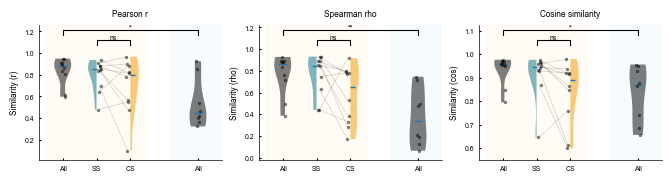

In [62]:
# Additional map similarities: Spearman rho and Cosine similarity
# Compared between S1_1st and S1_2nd.

MIN_VALID_BINS_FOR_DISTANCE = 20

try:
    from scipy import stats as scipy_stats
except Exception:
    scipy_stats = None


def _map_pair_spearman_distance(map1, map2, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape:
        return np.nan, 0

    a = np.asarray(map1, dtype=float).ravel()
    b = np.asarray(map2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n_valid = int(np.sum(valid))
    if n_valid < int(min_valid_bins):
        return np.nan, n_valid

    x = a[valid]
    y = b[valid]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0 or scipy_stats is None:
        return np.nan, n_valid

    try:
        rho, _p = scipy_stats.spearmanr(x, y)
    except Exception:
        return np.nan, n_valid

    if not np.isfinite(rho):
        return np.nan, n_valid

    sim = float(rho)
    return sim, n_valid


def _map_pair_cosine_distance(map1, map2, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape:
        return np.nan, 0

    a = np.asarray(map1, dtype=float).ravel()
    b = np.asarray(map2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n_valid = int(np.sum(valid))
    if n_valid < int(min_valid_bins):
        return np.nan, n_valid

    x = a[valid]
    y = b[valid]
    nx = float(np.linalg.norm(x))
    ny = float(np.linalg.norm(y))
    if nx <= 0 or ny <= 0:
        return np.nan, n_valid

    cos_sim = float(np.dot(x, y) / (nx * ny))
    cos_sim = float(np.clip(cos_sim, -1.0, 1.0))
    sim = cos_sim
    return sim, n_valid



def _map_pair_pearson_distance(map1, map2, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape:
        return np.nan, 0

    a = np.asarray(map1, dtype=float).ravel()
    b = np.asarray(map2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n_valid = int(np.sum(valid))
    if n_valid < int(min_valid_bins):
        return np.nan, n_valid

    x = a[valid]
    y = b[valid]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan, n_valid

    r = float(np.corrcoef(x, y)[0, 1])
    if not np.isfinite(r):
        return np.nan, n_valid
    return r, n_valid

def _collect_session_distance(cell_keys, map_key, group_label, metric='spearman'):
    rows = []
    for dataset_id, cell_idx in cell_keys:
        c1 = _get_condition_cell(dataset_id, cell_idx, 's1_1st')
        c2 = _get_condition_cell(dataset_id, cell_idx, 's1_2nd')

        if c1 is None or c2 is None:
            rows.append({
                'dataset_id': dataset_id,
                'cell_idx': int(cell_idx),
                'group': group_label,
                'map_key': map_key,
                'metric': metric,
                'has_both_halves': False,
                'n_valid_bins': 0,
                'similarity': np.nan,
            })
            continue

        c1 = copy.deepcopy(c1)
        c2 = copy.deepcopy(c2)
        _renormalize_ss_cs_maps_per_condition(c1)
        _renormalize_ss_cs_maps_per_condition(c2)

        if metric == 'pearson':
            d, n_valid = _map_pair_pearson_distance(c1.get(map_key, None), c2.get(map_key, None), min_valid_bins=MIN_VALID_BINS_FOR_DISTANCE)
        elif metric == 'spearman':
            d, n_valid = _map_pair_spearman_distance(c1.get(map_key, None), c2.get(map_key, None), min_valid_bins=MIN_VALID_BINS_FOR_DISTANCE)
        elif metric == 'cosine':
            d, n_valid = _map_pair_cosine_distance(c1.get(map_key, None), c2.get(map_key, None), min_valid_bins=MIN_VALID_BINS_FOR_DISTANCE)
        else:
            raise ValueError(f'Unknown metric: {metric}')

        rows.append({
            'dataset_id': dataset_id,
            'cell_idx': int(cell_idx),
            'group': group_label,
            'map_key': map_key,
            'metric': metric,
            'has_both_halves': True,
            'n_valid_bins': int(n_valid),
            'similarity': d,
        })

    return pd.DataFrame(rows)


def _summarize_distance_df(df, title):
    print(f"\n=== {title} ===")
    if df is None or len(df) == 0:
        print('No rows')
        return

    out_rows = []
    for g in sorted(df['group'].unique()):
        dfg = df[df['group'] == g].copy()
        n_total = int(len(dfg))
        n_both = int(dfg['has_both_halves'].sum())
        dfg_valid = dfg[np.isfinite(dfg['similarity'])]
        n_valid = int(len(dfg_valid))
        mean_d = float(np.nanmean(dfg_valid['similarity'])) if n_valid > 0 else np.nan
        med_d = float(np.nanmedian(dfg_valid['similarity'])) if n_valid > 0 else np.nan
        std_d = float(np.nanstd(dfg_valid['similarity'], ddof=1)) if n_valid > 1 else np.nan

        out_rows.append({
            'group': g,
            'n_total_cells': n_total,
            'n_with_s1_1st_and_s1_2nd': n_both,
            'n_valid_similarity': n_valid,
            'mean_similarity': mean_d,
            'median_similarity': med_d,
            'std_similarity': std_d,
        })

    display(pd.DataFrame(out_rows))


def _row_keys(df):
    if df is None or len(df) == 0:
        return []
    return list(zip(df['dataset_id'].astype(str), df['cell_idx'].astype(int)))


def _exclude_rows_by_keys(df, exclude_keys):
    if df is None:
        return df
    if not exclude_keys or len(df) == 0:
        return df.copy()
    keep_mask = [k not in exclude_keys for k in _row_keys(df)]
    return df.loc[np.asarray(keep_mask, dtype=bool)].reset_index(drop=True)


def _compute_distance_tables(metric_name):
    d_all_csplus = _collect_session_distance(csplus_keys, 'rate_map', 'CS+', metric=metric_name)
    d_all_csminus = _collect_session_distance(csminus_keys, 'rate_map', 'CS-', metric=metric_name)
    d_ss_csplus = _collect_session_distance(csplus_keys, 'ss_norm_map', 'CS+', metric=metric_name)
    d_ss_csminus = _collect_session_distance(csminus_keys, 'ss_norm_map', 'CS-', metric=metric_name)
    d_cs_map = _collect_session_distance(csplus_keys, 'cs_norm_map', 'CS+', metric=metric_name)

    # Optional outlier removal based on Pearson SS r threshold (same policy as other figures)
    REMOVE_LOW_SS_OUTLIER_LOCAL = bool(globals().get('REMOVE_LOW_SS_OUTLIER', True))
    SS_R_OUTLIER_THRESHOLD_LOCAL = float(globals().get('SS_R_OUTLIER_THRESHOLD', 0.1))

    outlier_keys = set()
    if REMOVE_LOW_SS_OUTLIER_LOCAL and ('df_ss_map' in globals()) and isinstance(df_ss_map, pd.DataFrame) and ('corr_r' in df_ss_map.columns):
        outlier_df = df_ss_map[np.isfinite(df_ss_map['corr_r']) & (df_ss_map['corr_r'] < SS_R_OUTLIER_THRESHOLD_LOCAL)]
        outlier_keys = set(_row_keys(outlier_df))

        d_all_csplus = _exclude_rows_by_keys(d_all_csplus, outlier_keys)
        d_all_csminus = _exclude_rows_by_keys(d_all_csminus, outlier_keys)
        d_ss_csplus = _exclude_rows_by_keys(d_ss_csplus, outlier_keys)
        d_ss_csminus = _exclude_rows_by_keys(d_ss_csminus, outlier_keys)
        d_cs_map = _exclude_rows_by_keys(d_cs_map, outlier_keys)

    d_all_map = pd.concat([d_all_csplus, d_all_csminus], ignore_index=True)
    d_ss_map = pd.concat([d_ss_csplus, d_ss_csminus], ignore_index=True)

    print(f"{metric_name}: outlier filter enabled={REMOVE_LOW_SS_OUTLIER_LOCAL}, removed={len(outlier_keys)}")

    return d_all_csplus, d_all_csminus, d_ss_csplus, d_ss_csminus, d_cs_map, d_all_map, d_ss_map


# Compute tables
pe_all_csplus, pe_all_csminus, pe_ss_csplus, pe_ss_csminus, pe_cs_map, pe_all_map, pe_ss_map = _compute_distance_tables('pearson')
sp_all_csplus, sp_all_csminus, sp_ss_csplus, sp_ss_csminus, sp_cs_map, sp_all_map, sp_ss_map = _compute_distance_tables('spearman')
co_all_csplus, co_all_csminus, co_ss_csplus, co_ss_csminus, co_cs_map, co_all_map, co_ss_map = _compute_distance_tables('cosine')

_summarize_distance_df(pe_all_map, 'Pearson Similarity (r): All-Spike Maps (S1_1st vs S1_2nd)')
_summarize_distance_df(pe_ss_map, 'Pearson Similarity (r): Simple-Spike Maps (S1_1st vs S1_2nd)')
_summarize_distance_df(pe_cs_map, 'Pearson Similarity (r): Complex-Spike Maps (S1_1st vs S1_2nd, CS+ only)')

_summarize_distance_df(sp_all_map, 'Spearman Similarity (rho): All-Spike Maps (S1_1st vs S1_2nd)')
_summarize_distance_df(sp_ss_map, 'Spearman Similarity (rho): Simple-Spike Maps (S1_1st vs S1_2nd)')
_summarize_distance_df(sp_cs_map, 'Spearman Similarity (rho): Complex-Spike Maps (S1_1st vs S1_2nd, CS+ only)')

_summarize_distance_df(co_all_map, 'Cosine Similarity: All-Spike Maps (S1_1st vs S1_2nd)')
_summarize_distance_df(co_ss_map, 'Cosine Similarity: Simple-Spike Maps (S1_1st vs S1_2nd)')
_summarize_distance_df(co_cs_map, 'Cosine Similarity: Complex-Spike Maps (S1_1st vs S1_2nd, CS+ only)')


# Plot grouped style (CS+ left: All/SS/CS, CS- right: All)

def _shapiro_p_safe(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    n = int(arr.size)
    if scipy_stats is None or n < 3:
        return np.nan
    try:
        if n > 5000:
            rng = np.random.default_rng(0)
            arr = rng.choice(arr, size=5000, replace=False)
        return float(scipy_stats.shapiro(arr).pvalue)
    except Exception:
        return np.nan


def _auto_unpaired_test(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    n1, n2 = int(x.size), int(y.size)
    if scipy_stats is None or n1 < 2 or n2 < 2:
        return np.nan, 'n/a', np.nan, np.nan

    sh1 = _shapiro_p_safe(x)
    sh2 = _shapiro_p_safe(y)
    can_parametric = (
        n1 >= 5 and n2 >= 5 and
        np.isfinite(sh1) and sh1 >= alpha and
        np.isfinite(sh2) and sh2 >= alpha
    )

    if can_parametric:
        try:
            _stat, p = scipy_stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
            return float(p), 'welch_t', sh1, sh2
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.mannwhitneyu(x, y, alternative='two-sided')
        return float(p), 'mannwhitney_u', sh1, sh2
    except Exception:
        return np.nan, 'mannwhitney_u', sh1, sh2


def _auto_paired_test(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    n = int(x.size)
    if scipy_stats is None or n < 2:
        return np.nan, 'n/a', np.nan

    sh = _shapiro_p_safe(x - y)
    can_parametric = (n >= 5 and np.isfinite(sh) and sh >= alpha)

    if can_parametric:
        try:
            _stat, p = scipy_stats.ttest_rel(x, y, nan_policy='omit')
            return float(p), 'paired_t', sh
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.wilcoxon(x, y, alternative='two-sided')
        return float(p), 'wilcoxon', sh
    except Exception:
        return np.nan, 'wilcoxon', sh


def _sig_label(p):
    if not np.isfinite(p):
        return 'n/a'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


def _add_bracket(ax, x1, x2, y, h, label, color='black'):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color=color, linewidth=0.8)
    ax.text((x1 + x2) / 2.0, y + h, label, ha='center', va='bottom', fontsize=5, fontname='Arial', color=color)


def _finite_vals(df):
    arr = np.asarray(df['similarity'], dtype=float)
    return arr[np.isfinite(arr)]


def _draw_violin(ax, arr, pos, color, half=None, alpha=0.5):
    if len(arr) < 3:
        return
    parts = ax.violinplot([arr], positions=[pos], showmedians=True, showextrema=False)
    if 'cmedians' in parts:
        parts['cmedians'].set_color('#1F77B4')
        parts['cmedians'].set_linewidth(1.0)
    body = parts['bodies'][0]
    body.set_facecolor(color)
    body.set_edgecolor('none')
    body.set_alpha(alpha)

    if half in ('left', 'right'):
        verts = body.get_paths()[0].vertices
        segs = parts['cmedians'].get_segments()
        if half == 'left':
            verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
            segs[0][:, 0] = np.clip(segs[0][:, 0], -np.inf, pos)
        else:
            verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
            segs[0][:, 0] = np.clip(segs[0][:, 0], pos, np.inf)
        parts['cmedians'].set_segments(segs)


def _scatter_side(ax, arr, pos, direction='center', rng_seed=0):
    if len(arr) == 0:
        return
    rng = np.random.default_rng(rng_seed)
    if direction == 'right':
        x = pos + 0.02 + rng.random(len(arr)) * 0.12
    elif direction == 'left':
        x = pos - 0.02 - rng.random(len(arr)) * 0.12
    else:
        x = pos + (rng.random(len(arr)) - 0.5) * 0.14
    ax.scatter(x, arr, s=6, color='black', alpha=0.5, linewidths=0, zorder=3)


def _plot_distance_panel(ax, all_csplus_df, all_csminus_df, ss_csplus_df, cs_csplus_df, title, ylabel):
    all_csplus_vals = _finite_vals(all_csplus_df)
    all_csminus_vals = _finite_vals(all_csminus_df)
    ss_csplus_vals = _finite_vals(ss_csplus_df)
    cs_csplus_vals = _finite_vals(cs_csplus_df)

    cs_plc_bg_local = globals().get('cs_plc_bg', globals().get('cs_plc_bg_color', '#FFF3E0'))
    non_cs_plc_bg_local = globals().get('non_cs_plc_bg', globals().get('non_cs_plc_bg_color', '#E3F2FD'))

    ax.axvspan(0.5, 3.5, alpha=0.3, color=cs_plc_bg_local, zorder=0)
    ax.axvspan(4.2, 5.8, alpha=0.3, color=non_cs_plc_bg_local, zorder=0)

    _draw_violin(ax, all_csplus_vals, 1.0, 'black', half=None, alpha=0.5)
    _draw_violin(ax, ss_csplus_vals, 2.0, '#026C80', half='left', alpha=0.5)
    _draw_violin(ax, cs_csplus_vals, 3.0, '#EE9B00', half='right', alpha=0.5)
    _draw_violin(ax, all_csminus_vals, 5.0, 'black', half=None, alpha=0.5)

    # Paired table for CS+ SS vs CS
    ma = ss_csplus_df[['dataset_id', 'cell_idx', 'similarity']].rename(columns={'similarity': 'a'})
    mb = cs_csplus_df[['dataset_id', 'cell_idx', 'similarity']].rename(columns={'similarity': 'b'})
    m = ma.merge(mb, on=['dataset_id', 'cell_idx'], how='inner')
    m = m[np.isfinite(m['a']) & np.isfinite(m['b'])]
    for row in m.itertuples(index=False):
        ax.plot([2.08, 2.92], [row.a, row.b], color='black', alpha=0.18, linewidth=0.5, zorder=2)

    _scatter_side(ax, all_csplus_vals, 1.0, direction='center', rng_seed=101)
    _scatter_side(ax, ss_csplus_vals, 2.0, direction='right', rng_seed=102)
    _scatter_side(ax, cs_csplus_vals, 3.0, direction='left', rng_seed=103)
    _scatter_side(ax, all_csminus_vals, 5.0, direction='center', rng_seed=104)

    # Tests
    p_paired, paired_test, paired_sh = _auto_paired_test(m['a'].to_numpy(dtype=float), m['b'].to_numpy(dtype=float), alpha=0.05)
    p_unpaired, unpaired_test, sh1, sh2 = _auto_unpaired_test(all_csplus_vals, all_csminus_vals, alpha=0.05)

    ax.set_title(title, fontsize=6, fontname='Arial')
    ax.set_ylabel(ylabel, fontsize=6, fontname='Arial')
    ax.set_xticks([1.0, 2.0, 3.0, 5.0])
    ax.set_xticklabels(['All', 'SS', 'CS', 'All'], fontsize=4, fontname='Arial')
    ax.set_xlim(0.3, 5.7)
    ax.tick_params(axis='both', labelsize=5)
    for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
        label.set_fontname('Arial')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Dynamic y-limits + brackets
    all_vals = np.concatenate([
        all_csplus_vals if len(all_csplus_vals) else np.array([0.0]),
        all_csminus_vals if len(all_csminus_vals) else np.array([0.0]),
        ss_csplus_vals if len(ss_csplus_vals) else np.array([0.0]),
        cs_csplus_vals if len(cs_csplus_vals) else np.array([0.0]),
    ])
    if np.any(np.isfinite(all_vals)):
        y_min = float(np.nanmin(all_vals))
        y_max = float(np.nanmax(all_vals))
    else:
        y_min, y_max = 0.0, 1.0

    base_pad = max(0.05, 0.1 * (y_max - y_min) if y_max > y_min else 0.1)
    y0 = y_min - base_pad
    y_top = y_max + base_pad
    yr = max(0.2, y_top - y0)
    h = 0.04 * yr
    gap = 0.05 * yr

    y1 = y_top + 0.02 * yr
    _add_bracket(ax, 2.0, 3.0, y1, h, _sig_label(p_paired), color='black')
    y2 = y1 + h + gap
    _add_bracket(ax, 1.0, 5.0, y2, h, _sig_label(p_unpaired), color='black')

    ax.set_ylim(y0, y2 + h + 0.05 * yr)

    return {
        'paired_p': p_paired,
        'paired_test': paired_test,
        'paired_shapiro_p': paired_sh,
        'paired_n': int(len(m)),
        'unpaired_p': p_unpaired,
        'unpaired_test': unpaired_test,
        'unpaired_shapiro_csplus_p': sh1,
        'unpaired_shapiro_csminus_p': sh2,
        'unpaired_n_csplus': int(len(all_csplus_vals)),
        'unpaired_n_csminus': int(len(all_csminus_vals)),
    }


fig, axes = plt.subplots(1, 3, figsize=(6.6, 1.7), constrained_layout=True)
stats_pearson = _plot_distance_panel(
    axes[0],
    pe_all_csplus, pe_all_csminus,
    pe_ss_csplus, pe_cs_map,
    title='Pearson r',
    ylabel='Similarity (r)',
)
stats_spearman = _plot_distance_panel(
    axes[1],
    sp_all_csplus, sp_all_csminus,
    sp_ss_csplus, sp_cs_map,
    title='Spearman rho',
    ylabel='Similarity (rho)',
)
stats_cosine = _plot_distance_panel(
    axes[2],
    co_all_csplus, co_all_csminus,
    co_ss_csplus, co_cs_map,
    title='Cosine similarity',
    ylabel='Similarity (cos)',
)

print("\n=== Similarity Statistical Tests ===")
print(
    f"Pearson: SS vs CS (CS+) -> {stats_pearson['paired_test']}, "
    f"p={stats_pearson['paired_p']:.4g}, n={stats_pearson['paired_n']}, "
    f"Shapiro(diff) p={stats_pearson['paired_shapiro_p']:.4g}"
)
print(
    f"Pearson: All CS+ vs CS- -> {stats_pearson['unpaired_test']}, "
    f"p={stats_pearson['unpaired_p']:.4g}, "
    f"n_cs+={stats_pearson['unpaired_n_csplus']}, n_cs-={stats_pearson['unpaired_n_csminus']}, "
    f"Shapiro CS+ p={stats_pearson['unpaired_shapiro_csplus_p']:.4g}, "
    f"CS- p={stats_pearson['unpaired_shapiro_csminus_p']:.4g}"
)
print(
    f"Spearman: SS vs CS (CS+) -> {stats_spearman['paired_test']}, "
    f"p={stats_spearman['paired_p']:.4g}, n={stats_spearman['paired_n']}, "
    f"Shapiro(diff) p={stats_spearman['paired_shapiro_p']:.4g}"
)
print(
    f"Spearman: All CS+ vs CS- -> {stats_spearman['unpaired_test']}, "
    f"p={stats_spearman['unpaired_p']:.4g}, "
    f"n_cs+={stats_spearman['unpaired_n_csplus']}, n_cs-={stats_spearman['unpaired_n_csminus']}, "
    f"Shapiro CS+ p={stats_spearman['unpaired_shapiro_csplus_p']:.4g}, "
    f"CS- p={stats_spearman['unpaired_shapiro_csminus_p']:.4g}"
)
print(
    f"Cosine: SS vs CS (CS+) -> {stats_cosine['paired_test']}, "
    f"p={stats_cosine['paired_p']:.4g}, n={stats_cosine['paired_n']}, "
    f"Shapiro(diff) p={stats_cosine['paired_shapiro_p']:.4g}"
)
print(
    f"Cosine: All CS+ vs CS- -> {stats_cosine['unpaired_test']}, "
    f"p={stats_cosine['unpaired_p']:.4g}, "
    f"n_cs+={stats_cosine['unpaired_n_csplus']}, n_cs-={stats_cosine['unpaired_n_csminus']}, "
    f"Shapiro CS+ p={stats_cosine['unpaired_shapiro_csplus_p']:.4g}, "
    f"CS- p={stats_cosine['unpaired_shapiro_csminus_p']:.4g}"
)

fig_path = os.path.join(FIGURE_SAVE_FOLDER, 's1_1st_vs_s1_2nd_map_similarities_pearson_spearman_cosine.svg')
fig.savefig(fig_path, dpi=300)
print(f'Saved: {fig_path}')

out_table = pd.concat([
    pe_all_map.assign(metric_type='pearson', map_group='all_map'),
    pe_ss_map.assign(metric_type='pearson', map_group='ss_map'),
    pe_cs_map.assign(metric_type='pearson', map_group='cs_map'),
    sp_all_map.assign(metric_type='spearman', map_group='all_map'),
    sp_ss_map.assign(metric_type='spearman', map_group='ss_map'),
    sp_cs_map.assign(metric_type='spearman', map_group='cs_map'),
    co_all_map.assign(metric_type='cosine', map_group='all_map'),
    co_ss_map.assign(metric_type='cosine', map_group='ss_map'),
    co_cs_map.assign(metric_type='cosine', map_group='cs_map'),
], ignore_index=True)
out_csv = os.path.join(FIGURE_SAVE_FOLDER, 's1_1st_vs_s1_2nd_map_similarities_pearson_spearman_cosine.csv')
out_table.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')


=== 4-group S1Half map similarity populations ===
CS+ PLC: 10
CS- PLC: 8
CS+ Non-PLC (SS>0.5, CS>0.5): 9
CS- Non-PLC (SS>0.5, CS<0.5): 14
Outlier filter applied=False, removed_keys=0

=== S1_1st vs S1_2nd similarity summary (map-specific groups x 5 maps x 3 metrics) ===


,metric,metric_label,map_key,map_label,group,n_total_cells,n_with_s1_1st_and_s1_2nd,n_valid_similarity,mean_similarity,median_similarity,std_similarity
0,pearson,Pearson r,rate_map,All-spike map,CS+ PLC,10,10,10,0.832666,0.876739,0.127505
1,pearson,Pearson r,rate_map,All-spike map,CS- PLC,8,8,8,0.536047,0.442850,0.227175
2,pearson,Pearson r,rate_map,All-spike map,CS+ Non-PLC,9,9,9,0.401573,0.299152,0.235657
3,pearson,Pearson r,rate_map,All-spike map,CS- Non-PLC,14,14,14,0.383068,0.304264,0.264510
4,pearson,Pearson r,ss_norm_map,SS map,CS+ PLC,10,10,10,0.796346,0.851520,0.144646
5,pearson,Pearson r,ss_norm_map,SS map,CS- PLC,8,8,8,0.503087,0.460492,0.299333
6,pearson,Pearson r,ss_norm_map,SS map,CS+ Non-PLC,9,9,9,0.497882,0.548442,0.169002
7,pearson,Pearson r,ss_norm_map,SS map,CS- Non-PLC,14,14,14,0.357461,0.277481,0.277143
8,pearson,Pearson r,cs_norm_map,CS map,CS+ PLC,10,10,10,0.686282,0.798934,0.263986
9,pearson,Pearson r,cs_norm_map,CS map,CS+ Non-PLC,9,9,9,0.107819,0.022978,0.260900


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1half_similarity_4groups_all_ss_cs_theta_slow_pearson.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1half_similarity_4groups_all_ss_cs_theta_slow_spearman.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1half_similarity_4groups_all_ss_cs_theta_slow_cosine.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1half_similarity_4groups_all_ss_cs_theta_slow_allmetrics.csv
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1half_similarity_4groups_all_ss_cs_theta_slow_allmetrics_summary.csv
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI

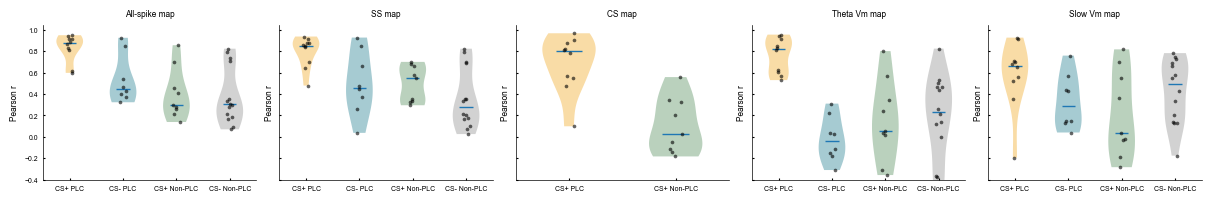

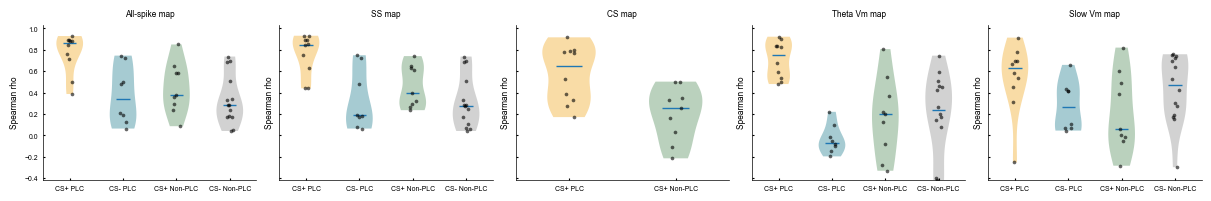

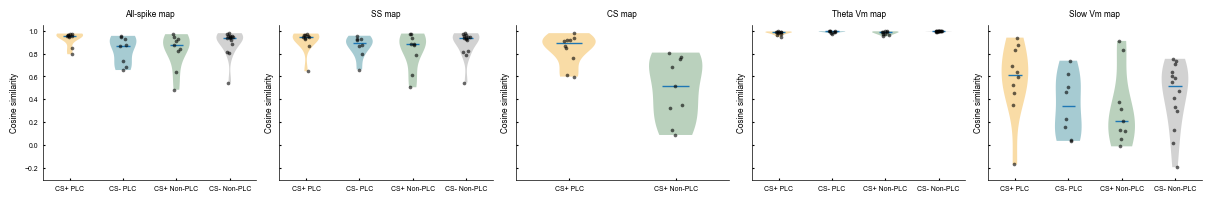

In [67]:
# 4-group S1_1st vs S1_2nd map similarities
# Groups: CS+ PLC, CS- PLC, CS+ Non-PLC, CS- Non-PLC
# Map order: All spike, SS, CS, Theta Vm, Slow Vm
# Metrics: Pearson r, Spearman rho, Cosine similarity

MIN_VALID_BINS_FOR_4GROUP_MAP_SIM_HALF = 20
NONPC_SS_PEAK_THRESHOLD_HZ = 0.5
NONPC_CS_PEAK_THRESHOLD_HZ = 0.5
APPLY_OUTLIER_FILTER_4GROUP_HALF = False

ALL_GROUPS_4GROUP_HALF = ['CS+ PLC', 'CS- PLC', 'CS+ Non-PLC', 'CS- Non-PLC']
CS_GROUPS_4GROUP_HALF = ['CS+ PLC', 'CS+ Non-PLC']

MAP_SPECS_4GROUP_HALF = [
    ('rate_map', 'All-spike map', ALL_GROUPS_4GROUP_HALF),
    ('ss_norm_map', 'SS map', ALL_GROUPS_4GROUP_HALF),
    ('cs_norm_map', 'CS map', CS_GROUPS_4GROUP_HALF),
    ('theta_map', 'Theta Vm map', ALL_GROUPS_4GROUP_HALF),
    ('slow_map', 'Slow Vm map', ALL_GROUPS_4GROUP_HALF),
]

METRIC_SPECS_4GROUP_HALF = [
    ('pearson', 'Pearson r'),
    ('spearman', 'Spearman rho'),
    ('cosine', 'Cosine similarity'),
]

if 'scipy_stats' not in globals() or scipy_stats is None:
    try:
        from scipy import stats as scipy_stats
    except Exception:
        scipy_stats = None


def _safe_nanmax_4group_half(arr):
    if not isinstance(arr, np.ndarray):
        return np.nan
    if arr.size == 0 or (not np.any(np.isfinite(arr))):
        return np.nan
    return float(np.nanmax(arr))


def _get_reference_cell_4group_half(dataset_id, cell_idx):
    # S1Half notebook reference condition is full session 1
    c = _get_condition_cell(dataset_id, int(cell_idx), 'session1_full')
    if c is not None:
        return c
    if 'combined_cell_map' in globals() and isinstance(combined_cell_map, dict):
        return combined_cell_map.get((dataset_id, int(cell_idx)), None)
    return None


def _build_nonpc_groups_4group_half(ss_thr=0.5, cs_thr=0.5):
    csplus_nonpc = []
    csminus_nonpc = []
    rows = []

    for dataset_id, cell_idx in sorted(nonpc_keys):
        c = _get_reference_cell_4group_half(dataset_id, cell_idx)
        if c is None:
            continue

        ss_peak = _safe_nanmax_4group_half(c.get('ss_rate_map', None))
        cs_peak = _safe_nanmax_4group_half(c.get('cs_rate_map', None))

        is_csplus_nonpc = bool(np.isfinite(ss_peak) and np.isfinite(cs_peak) and ss_peak > float(ss_thr) and cs_peak > float(cs_thr))
        is_csminus_nonpc = bool(np.isfinite(ss_peak) and np.isfinite(cs_peak) and ss_peak > float(ss_thr) and cs_peak < float(cs_thr))

        if is_csplus_nonpc:
            csplus_nonpc.append((dataset_id, int(cell_idx)))
        if is_csminus_nonpc:
            csminus_nonpc.append((dataset_id, int(cell_idx)))

        rows.append({
            'dataset_id': str(dataset_id),
            'cell_idx': int(cell_idx),
            'ss_peak_hz': ss_peak,
            'cs_peak_hz': cs_peak,
            'is_csplus_nonpc': is_csplus_nonpc,
            'is_csminus_nonpc': is_csminus_nonpc,
        })

    return sorted(set(csplus_nonpc)), sorted(set(csminus_nonpc)), pd.DataFrame(rows)


def _pearson_similarity_4group_half(map1, map2, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape:
        return np.nan, 0

    a = np.asarray(map1, dtype=float).ravel()
    b = np.asarray(map2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n_valid = int(np.sum(valid))
    if n_valid < int(min_valid_bins):
        return np.nan, n_valid

    x = a[valid]
    y = b[valid]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan, n_valid

    r = float(np.corrcoef(x, y)[0, 1])
    if not np.isfinite(r):
        return np.nan, n_valid
    return r, n_valid


def _spearman_similarity_4group_half(map1, map2, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape:
        return np.nan, 0

    a = np.asarray(map1, dtype=float).ravel()
    b = np.asarray(map2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n_valid = int(np.sum(valid))
    if n_valid < int(min_valid_bins):
        return np.nan, n_valid

    x = a[valid]
    y = b[valid]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan, n_valid

    if scipy_stats is not None:
        try:
            rho, _p = scipy_stats.spearmanr(x, y)
            if np.isfinite(rho):
                return float(rho), n_valid
            return np.nan, n_valid
        except Exception:
            return np.nan, n_valid

    rx = pd.Series(x).rank(method='average').to_numpy(dtype=float)
    ry = pd.Series(y).rank(method='average').to_numpy(dtype=float)
    if np.nanstd(rx) == 0 or np.nanstd(ry) == 0:
        return np.nan, n_valid
    return float(np.corrcoef(rx, ry)[0, 1]), n_valid


def _cosine_similarity_4group_half(map1, map2, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape:
        return np.nan, 0

    a = np.asarray(map1, dtype=float).ravel()
    b = np.asarray(map2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n_valid = int(np.sum(valid))
    if n_valid < int(min_valid_bins):
        return np.nan, n_valid

    x = a[valid]
    y = b[valid]
    nx = float(np.linalg.norm(x))
    ny = float(np.linalg.norm(y))
    if nx <= 0 or ny <= 0:
        return np.nan, n_valid

    c = float(np.dot(x, y) / (nx * ny))
    return float(np.clip(c, -1.0, 1.0)), n_valid


def _map_similarity_by_metric_4group_half(map1, map2, metric_name, min_valid_bins=20):
    if metric_name == 'pearson':
        return _pearson_similarity_4group_half(map1, map2, min_valid_bins=min_valid_bins)
    if metric_name == 'spearman':
        return _spearman_similarity_4group_half(map1, map2, min_valid_bins=min_valid_bins)
    if metric_name == 'cosine':
        return _cosine_similarity_4group_half(map1, map2, min_valid_bins=min_valid_bins)
    raise ValueError(f'Unknown metric: {metric_name}')


def _collect_similarity_for_map_metric_4group_half(keys, group_label, map_key, map_label, metric_name, metric_label):
    rows = []
    for dataset_id, cell_idx in sorted(keys):
        c1 = _get_condition_cell(dataset_id, int(cell_idx), 's1_1st')
        c2 = _get_condition_cell(dataset_id, int(cell_idx), 's1_2nd')

        if c1 is None or c2 is None:
            rows.append({
                'dataset_id': str(dataset_id),
                'cell_idx': int(cell_idx),
                'group': group_label,
                'map_key': map_key,
                'map_label': map_label,
                'metric': metric_name,
                'metric_label': metric_label,
                'has_both_halves': False,
                'n_valid_bins': 0,
                'similarity': np.nan,
            })
            continue

        c1 = copy.deepcopy(c1)
        c2 = copy.deepcopy(c2)
        _renormalize_ss_cs_maps_per_condition(c1)
        _renormalize_ss_cs_maps_per_condition(c2)

        sim, n_valid = _map_similarity_by_metric_4group_half(
            c1.get(map_key, None),
            c2.get(map_key, None),
            metric_name=metric_name,
            min_valid_bins=MIN_VALID_BINS_FOR_4GROUP_MAP_SIM_HALF,
        )

        rows.append({
            'dataset_id': str(dataset_id),
            'cell_idx': int(cell_idx),
            'group': group_label,
            'map_key': map_key,
            'map_label': map_label,
            'metric': metric_name,
            'metric_label': metric_label,
            'has_both_halves': True,
            'n_valid_bins': int(n_valid),
            'similarity': sim,
        })

    return pd.DataFrame(rows)


def _maybe_apply_outlier_filter_4group_half(df_in):
    if not APPLY_OUTLIER_FILTER_4GROUP_HALF:
        return df_in.copy(), 0

    outlier_keys = set()
    if ('df_ss_map' in globals()) and isinstance(df_ss_map, pd.DataFrame) and ('corr_r' in df_ss_map.columns):
        thr = float(globals().get('SS_R_OUTLIER_THRESHOLD', 0.1))
        odf = df_ss_map[np.isfinite(df_ss_map['corr_r']) & (df_ss_map['corr_r'] < thr)]
        outlier_keys = set(list(zip(odf['dataset_id'].astype(str), odf['cell_idx'].astype(int))))

    if len(outlier_keys) == 0:
        return df_in.copy(), 0

    keys = list(zip(df_in['dataset_id'].astype(str), df_in['cell_idx'].astype(int)))
    keep = [k not in outlier_keys for k in keys]
    return df_in.loc[np.asarray(keep, dtype=bool)].reset_index(drop=True), len(outlier_keys)


def _draw_group_violin_4group_half(ax, vals, pos, color, seed):
    if len(vals) >= 3:
        parts = ax.violinplot([vals], positions=[pos], showmedians=True, showextrema=False)
        if 'cmedians' in parts:
            parts['cmedians'].set_color('#1F77B4')
            parts['cmedians'].set_linewidth(1.0)
        for b in parts['bodies']:
            b.set_facecolor(color)
            b.set_edgecolor('none')
            b.set_alpha(0.35)
    if len(vals) > 0:
        rng = np.random.default_rng(seed)
        xj = pos + (rng.random(len(vals)) - 0.5) * 0.14
        ax.scatter(xj, vals, s=7, color='black', alpha=0.6, linewidths=0, zorder=3)


csplus_nonpc_keys_4group_half, csminus_nonpc_keys_4group_half, nonpc_peak_meta_4group_half = _build_nonpc_groups_4group_half(
    ss_thr=NONPC_SS_PEAK_THRESHOLD_HZ,
    cs_thr=NONPC_CS_PEAK_THRESHOLD_HZ,
)

group_keys_4group_half = {
    'CS+ PLC': sorted(csplus_keys),
    'CS- PLC': sorted(csminus_keys),
    'CS+ Non-PLC': csplus_nonpc_keys_4group_half,
    'CS- Non-PLC': csminus_nonpc_keys_4group_half,
}

print('=== 4-group S1Half map similarity populations ===')
print(f"CS+ PLC: {len(group_keys_4group_half['CS+ PLC'])}")
print(f"CS- PLC: {len(group_keys_4group_half['CS- PLC'])}")
print(f"CS+ Non-PLC (SS>{NONPC_SS_PEAK_THRESHOLD_HZ}, CS>{NONPC_CS_PEAK_THRESHOLD_HZ}): {len(group_keys_4group_half['CS+ Non-PLC'])}")
print(f"CS- Non-PLC (SS>{NONPC_SS_PEAK_THRESHOLD_HZ}, CS<{NONPC_CS_PEAK_THRESHOLD_HZ}): {len(group_keys_4group_half['CS- Non-PLC'])}")

all_rows_4group_half = []
for metric_name, metric_label in METRIC_SPECS_4GROUP_HALF:
    for map_key, map_label, map_groups in MAP_SPECS_4GROUP_HALF:
        for group_label in map_groups:
            keys = group_keys_4group_half[group_label]
            all_rows_4group_half.append(
                _collect_similarity_for_map_metric_4group_half(
                    keys,
                    group_label,
                    map_key,
                    map_label,
                    metric_name,
                    metric_label,
                )
            )

similarity_4group_half_df = pd.concat(all_rows_4group_half, ignore_index=True)
similarity_4group_half_df, n_removed_outlier_keys_half = _maybe_apply_outlier_filter_4group_half(similarity_4group_half_df)
print(f'Outlier filter applied={APPLY_OUTLIER_FILTER_4GROUP_HALF}, removed_keys={n_removed_outlier_keys_half}')

summary_rows_half = []
for metric_name, metric_label in METRIC_SPECS_4GROUP_HALF:
    for map_key, map_label, map_groups in MAP_SPECS_4GROUP_HALF:
        for group_label in map_groups:
            d = similarity_4group_half_df[
                (similarity_4group_half_df['metric'] == metric_name) &
                (similarity_4group_half_df['map_key'] == map_key) &
                (similarity_4group_half_df['group'] == group_label)
            ].copy()
            vals = np.asarray(d['similarity'], dtype=float)
            vals = vals[np.isfinite(vals)]
            summary_rows_half.append({
                'metric': metric_name,
                'metric_label': metric_label,
                'map_key': map_key,
                'map_label': map_label,
                'group': group_label,
                'n_total_cells': int(len(d)),
                'n_with_s1_1st_and_s1_2nd': int(d['has_both_halves'].sum()) if len(d) > 0 else 0,
                'n_valid_similarity': int(len(vals)),
                'mean_similarity': float(np.nanmean(vals)) if len(vals) > 0 else np.nan,
                'median_similarity': float(np.nanmedian(vals)) if len(vals) > 0 else np.nan,
                'std_similarity': float(np.nanstd(vals, ddof=1)) if len(vals) > 1 else np.nan,
            })

similarity_4group_half_summary_df = pd.DataFrame(summary_rows_half)
print()
print('=== S1_1st vs S1_2nd similarity summary (map-specific groups x 5 maps x 3 metrics) ===')
display(similarity_4group_half_summary_df)

plot_colors_half = {
    'CS+ PLC': '#EE9B00',
    'CS- PLC': '#026C80',
    'CS+ Non-PLC': '#3A7D44',
    'CS- Non-PLC': '#7F7F7F',
}

for metric_name, metric_label in METRIC_SPECS_4GROUP_HALF:
    fig, axes = plt.subplots(1, 5, figsize=(12, 1.9), constrained_layout=True, sharey=True)

    for ax, (map_key, map_label, map_groups) in zip(axes, MAP_SPECS_4GROUP_HALF):
        vals_by_group = {}
        for g in map_groups:
            vals = np.asarray(
                similarity_4group_half_df.loc[
                    (similarity_4group_half_df['metric'] == metric_name) &
                    (similarity_4group_half_df['map_key'] == map_key) &
                    (similarity_4group_half_df['group'] == g),
                    'similarity'
                ],
                dtype=float,
            )
            vals_by_group[g] = vals[np.isfinite(vals)]

        for i, g in enumerate(map_groups, start=1):
            _draw_group_violin_4group_half(ax, vals_by_group[g], i, plot_colors_half[g], seed=1400 + i)

        n_map = {g: int(len(vals_by_group[g])) for g in map_groups}
        ax.set_title(map_label, fontsize=6, fontname='Arial')
        ax.set_ylabel(metric_label, fontsize=6, fontname='Arial')
        ax.set_xticks(list(range(1, len(map_groups) + 1)))
        ax.set_xticklabels([f'{g}' for g in map_groups], fontsize=4, fontname='Arial')
        ax.tick_params(axis='both', labelsize=5)
        for lbl in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
            lbl.set_fontname('Arial')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_xlim(0.5, len(map_groups) + 0.5)

        flat = np.concatenate([v for v in vals_by_group.values() if len(v) > 0]) if any(len(v) > 0 for v in vals_by_group.values()) else np.array([0.0, 1.0])
        y_min = float(np.nanmin(flat))
        y_max = float(np.nanmax(flat))
        pad = max(0.05, 0.1 * (y_max - y_min) if y_max > y_min else 0.1)
        ax.set_ylim(y_min - pad, y_max + pad)

    fig_path = os.path.join(FIGURE_SAVE_FOLDER, f's1half_similarity_4groups_all_ss_cs_theta_slow_{metric_name}.svg')
    fig.savefig(fig_path, dpi=300)
    print(f'Saved: {fig_path}')

detail_csv = os.path.join(FIGURE_SAVE_FOLDER, 's1half_similarity_4groups_all_ss_cs_theta_slow_allmetrics.csv')
similarity_4group_half_df.to_csv(detail_csv, index=False)
print(f'Saved: {detail_csv}')

summary_csv = os.path.join(FIGURE_SAVE_FOLDER, 's1half_similarity_4groups_all_ss_cs_theta_slow_allmetrics_summary.csv')
similarity_4group_half_summary_df.to_csv(summary_csv, index=False)
print(f'Saved: {summary_csv}')

meta_csv = os.path.join(FIGURE_SAVE_FOLDER, 's1half_nonpc_csplus_csminus_peak_groups_meta.csv')
nonpc_peak_meta_4group_half.to_csv(meta_csv, index=False)
print(f'Saved: {meta_csv}')


=== CS+ PLC slow-vs-other similarity correlation (S1Half) ===
Rows in source table: 549
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1half_csplusplc_slow_vs_other_similarity_scatter_pearson.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1half_csplusplc_slow_vs_other_similarity_scatter_spearman.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1half_csplusplc_slow_vs_other_similarity_scatter_cosine.svg

=== Regression/correlation summary (CS+ PLC, S1Half) ===


,metric,x_map,y_map,n,slope,intercept,corr_r,corr_p
0,pearson,slow_map,rate_map,10,0.075563,0.788802,0.190712,0.597662
1,pearson,slow_map,ss_norm_map,10,0.163455,0.701461,0.363655,0.301620
2,pearson,slow_map,cs_norm_map,10,0.013819,0.678260,0.016846,0.963159
3,pearson,slow_map,theta_map,10,0.209966,0.641020,0.413467,0.234948
4,spearman,slow_map,rate_map,10,0.061930,0.733815,0.108754,0.764895
5,spearman,slow_map,ss_norm_map,10,0.277839,0.609418,0.474349,0.166006
6,spearman,slow_map,cs_norm_map,10,-0.106438,0.631833,-0.129672,0.721064
7,spearman,slow_map,theta_map,10,0.206544,0.597834,0.389601,0.265755
8,cosine,slow_map,rate_map,10,-0.001168,0.934996,-0.006120,0.986614
9,cosine,slow_map,ss_norm_map,10,-0.000356,0.913715,-0.001157,0.997469


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1half_csplusplc_slow_vs_other_similarity_scatter_stats.csv


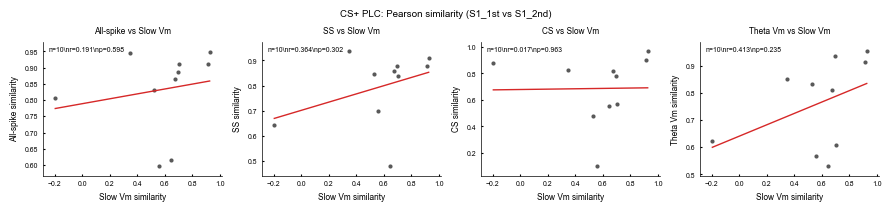

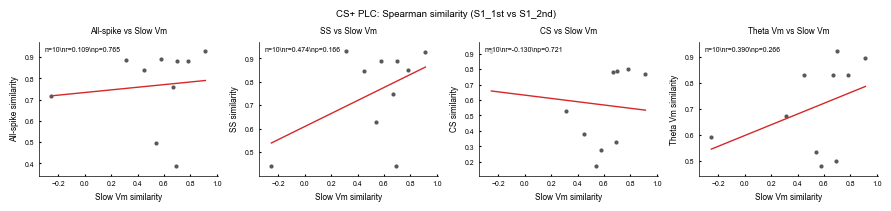

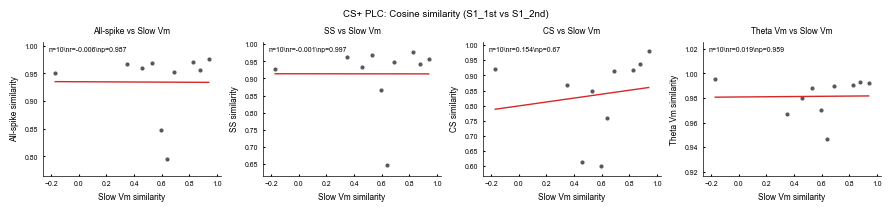

In [64]:
# CS+ PLC only: correlation between Slow Vm similarity and other map similarities (S1_1st vs S1_2nd)
# Output: 3 figures (Pearson/Spearman/Cosine), each with fitted lines

if 'scipy_stats' not in globals() or scipy_stats is None:
    try:
        from scipy import stats as scipy_stats
    except Exception:
        scipy_stats = None

TARGET_GROUP_FOR_SCATTER_HALF = 'CS+ PLC'
METRICS_FOR_SCATTER_HALF = ['pearson', 'spearman', 'cosine']
X_MAP_KEY_HALF = 'slow_map'
X_MAP_LABEL_HALF = 'Slow Vm'
Y_MAPS_HALF = [
    ('rate_map', 'All-spike'),
    ('ss_norm_map', 'SS'),
    ('cs_norm_map', 'CS'),
    ('theta_map', 'Theta Vm'),
]


def _ensure_similarity_df_for_scatter_half():
    if 'similarity_4group_half_df' in globals() and isinstance(similarity_4group_half_df, pd.DataFrame) and len(similarity_4group_half_df) > 0:
        req_cols = {'dataset_id', 'cell_idx', 'group', 'map_key', 'metric', 'similarity'}
        if req_cols.issubset(set(similarity_4group_half_df.columns)):
            return similarity_4group_half_df.copy()
    raise RuntimeError('Run the 4-group S1Half similarity cell first to create similarity_4group_half_df.')


def _pair_xy_for_metric_map_half(df, metric_name, y_map_key):
    d = df[(df['group'] == TARGET_GROUP_FOR_SCATTER_HALF) & (df['metric'] == metric_name)].copy()
    dx = d[d['map_key'] == X_MAP_KEY_HALF][['dataset_id', 'cell_idx', 'similarity']].rename(columns={'similarity': 'x'})
    dy = d[d['map_key'] == y_map_key][['dataset_id', 'cell_idx', 'similarity']].rename(columns={'similarity': 'y'})
    m = dx.merge(dy, on=['dataset_id', 'cell_idx'], how='inner')
    m = m[np.isfinite(m['x']) & np.isfinite(m['y'])].reset_index(drop=True)
    return m


def _fit_line_and_corr_half(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    n = int(len(x))

    if n < 2:
        return np.nan, np.nan, np.nan, np.nan, n

    if np.nanstd(x) == 0:
        slope = np.nan
        intercept = np.nan
    else:
        slope, intercept = np.polyfit(x, y, 1)

    if scipy_stats is not None and n >= 3 and np.nanstd(x) > 0 and np.nanstd(y) > 0:
        try:
            r_val, p_val = scipy_stats.pearsonr(x, y)
            return float(slope), float(intercept), float(r_val), float(p_val), n
        except Exception:
            return float(slope), float(intercept), np.nan, np.nan, n

    if np.nanstd(x) > 0 and np.nanstd(y) > 0:
        r_val = float(np.corrcoef(x, y)[0, 1])
    else:
        r_val = np.nan
    return float(slope), float(intercept), r_val, np.nan, n


def _metric_label_half(metric_name):
    return {
        'pearson': 'Pearson similarity',
        'spearman': 'Spearman similarity',
        'cosine': 'Cosine similarity',
    }.get(metric_name, metric_name)


scatter_source_half_df = _ensure_similarity_df_for_scatter_half()
print('=== CS+ PLC slow-vs-other similarity correlation (S1Half) ===')
print(f'Rows in source table: {len(scatter_source_half_df)}')

stats_rows_half = []
for metric_name in METRICS_FOR_SCATTER_HALF:
    fig, axes = plt.subplots(1, 4, figsize=(8.8, 2.0), constrained_layout=True)

    for ax, (y_map_key, y_map_label) in zip(axes, Y_MAPS_HALF):
        paired = _pair_xy_for_metric_map_half(scatter_source_half_df, metric_name, y_map_key)
        x = paired['x'].to_numpy(dtype=float)
        y = paired['y'].to_numpy(dtype=float)

        slope, intercept, r_val, p_val, n = _fit_line_and_corr_half(x, y)
        stats_rows_half.append({
            'metric': metric_name,
            'x_map': X_MAP_KEY_HALF,
            'y_map': y_map_key,
            'n': int(n),
            'slope': slope,
            'intercept': intercept,
            'corr_r': r_val,
            'corr_p': p_val,
        })

        if n > 0:
            ax.scatter(x, y, s=9, color='black', alpha=0.65, linewidths=0)

        if n >= 2 and np.isfinite(slope) and np.isfinite(intercept):
            x_min = float(np.nanmin(x))
            x_max = float(np.nanmax(x))
            if x_max > x_min:
                xx = np.linspace(x_min, x_max, 100)
                yy = slope * xx + intercept
                ax.plot(xx, yy, color='#D62828', linewidth=1.0)

        ax.set_title(f'{y_map_label} vs {X_MAP_LABEL_HALF}', fontsize=6, fontname='Arial')
        ax.set_xlabel(f'{X_MAP_LABEL_HALF} similarity', fontsize=6, fontname='Arial')
        ax.set_ylabel(f'{y_map_label} similarity', fontsize=6, fontname='Arial')
        ax.tick_params(axis='both', labelsize=5)
        for lbl in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
            lbl.set_fontname('Arial')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if n > 0:
            x_pad = max(0.03, 0.08 * (np.nanmax(x) - np.nanmin(x)) if np.nanmax(x) > np.nanmin(x) else 0.1)
            y_pad = max(0.03, 0.08 * (np.nanmax(y) - np.nanmin(y)) if np.nanmax(y) > np.nanmin(y) else 0.1)
            ax.set_xlim(float(np.nanmin(x)) - x_pad, float(np.nanmax(x)) + x_pad)
            ax.set_ylim(float(np.nanmin(y)) - y_pad, float(np.nanmax(y)) + y_pad)

        p_txt = f'{p_val:.3g}' if np.isfinite(p_val) else 'n/a'
        r_txt = f'{r_val:.3f}' if np.isfinite(r_val) else 'n/a'
        ax.text(
            0.03, 0.97,
            f'n={n}\\nr={r_txt}\\np={p_txt}',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=5,
            fontname='Arial',
            bbox=dict(boxstyle='round,pad=0.18', facecolor='white', alpha=0.75, edgecolor='none')
        )

    fig.suptitle(f'CS+ PLC: {_metric_label_half(metric_name)} (S1_1st vs S1_2nd)', fontsize=7, fontname='Arial')
    fig_path = os.path.join(FIGURE_SAVE_FOLDER, f's1half_csplusplc_slow_vs_other_similarity_scatter_{metric_name}.svg')
    fig.savefig(fig_path, dpi=300)
    print(f'Saved: {fig_path}')

csplus_slow_vs_other_half_stats_df = pd.DataFrame(stats_rows_half)
print()
print('=== Regression/correlation summary (CS+ PLC, S1Half) ===')
display(csplus_slow_vs_other_half_stats_df)

stats_csv = os.path.join(FIGURE_SAVE_FOLDER, 's1half_csplusplc_slow_vs_other_similarity_scatter_stats.csv')
csplus_slow_vs_other_half_stats_df.to_csv(stats_csv, index=False)
print(f'Saved: {stats_csv}')


=== CS+ PLC only: SS-vs-CS map similarity within each half ===


,metric,test,p_value,n_pairs,shapiro_diff_p,mean_s1_1st,mean_s1_2nd
0,pearson,wilcoxon,0.027344,10,0.028075,0.830393,0.668644
1,spearman,paired_t,0.026384,10,0.228605,0.770131,0.594902
2,cosine,wilcoxon,0.064453,10,0.023541,0.905345,0.806431


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1_1st_vs_s1_2nd_csplus_plc_ss_vs_cs_within_half_similarity.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1_1st_vs_s1_2nd_csplus_plc_ss_vs_cs_within_half_similarity.csv
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1_1st_vs_s1_2nd_csplus_plc_ss_vs_cs_within_half_similarity_stats.csv


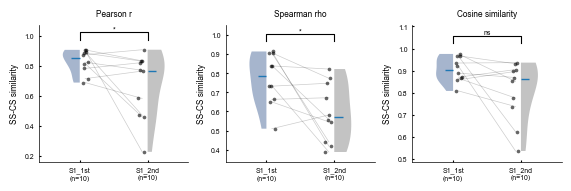

In [65]:
# CS+ place cells only: SS-vs-CS map similarity within each half
# Two groups: S1_1st vs S1_2nd
# Metric computed per cell: similarity(ss_norm_map, cs_norm_map) within a session

MIN_VALID_BINS_FOR_SSCS = 20

try:
    from scipy import stats as scipy_stats
except Exception:
    scipy_stats = None


def _pearson_sim(m1, m2, min_valid_bins=20):
    if not isinstance(m1, np.ndarray) or not isinstance(m2, np.ndarray):
        return np.nan, 0
    if m1.shape != m2.shape:
        return np.nan, 0
    a = np.asarray(m1, dtype=float).ravel()
    b = np.asarray(m2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n = int(np.sum(valid))
    if n < int(min_valid_bins):
        return np.nan, n
    x = a[valid]
    y = b[valid]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan, n
    return float(np.corrcoef(x, y)[0, 1]), n


def _spearman_sim(m1, m2, min_valid_bins=20):
    if not isinstance(m1, np.ndarray) or not isinstance(m2, np.ndarray):
        return np.nan, 0
    if m1.shape != m2.shape:
        return np.nan, 0
    a = np.asarray(m1, dtype=float).ravel()
    b = np.asarray(m2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n = int(np.sum(valid))
    if n < int(min_valid_bins):
        return np.nan, n
    x = a[valid]
    y = b[valid]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan, n
    if scipy_stats is not None:
        try:
            rho, _p = scipy_stats.spearmanr(x, y)
            return (float(rho) if np.isfinite(rho) else np.nan), n
        except Exception:
            return np.nan, n
    rx = pd.Series(x).rank(method='average').to_numpy(dtype=float)
    ry = pd.Series(y).rank(method='average').to_numpy(dtype=float)
    if np.nanstd(rx) == 0 or np.nanstd(ry) == 0:
        return np.nan, n
    return float(np.corrcoef(rx, ry)[0, 1]), n


def _cosine_sim(m1, m2, min_valid_bins=20):
    if not isinstance(m1, np.ndarray) or not isinstance(m2, np.ndarray):
        return np.nan, 0
    if m1.shape != m2.shape:
        return np.nan, 0
    a = np.asarray(m1, dtype=float).ravel()
    b = np.asarray(m2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n = int(np.sum(valid))
    if n < int(min_valid_bins):
        return np.nan, n
    x = a[valid]
    y = b[valid]
    nx = float(np.linalg.norm(x))
    ny = float(np.linalg.norm(y))
    if nx <= 0 or ny <= 0:
        return np.nan, n
    cs = float(np.dot(x, y) / (nx * ny))
    return float(np.clip(cs, -1.0, 1.0)), n


def _shapiro_safe(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) < 3 or scipy_stats is None:
        return np.nan
    try:
        return float(scipy_stats.shapiro(vals).pvalue)
    except Exception:
        return np.nan


def _auto_paired(vals1, vals2, alpha=0.05):
    x = np.asarray(vals1, dtype=float)
    y = np.asarray(vals2, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    n = int(len(x))
    if n < 2 or scipy_stats is None:
        return np.nan, 'n/a', np.nan

    sh = _shapiro_safe(x - y)
    can_param = (n >= 5 and np.isfinite(sh) and sh >= alpha)

    if can_param:
        try:
            _stat, p = scipy_stats.ttest_rel(x, y, nan_policy='omit')
            return float(p), 'paired_t', sh
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.wilcoxon(x, y, alternative='two-sided')
        return float(p), 'wilcoxon', sh
    except Exception:
        return np.nan, 'wilcoxon', sh


def _sig_label(p):
    if not np.isfinite(p):
        return 'n/a'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


def _collect_sscs_within_session_similarity(metric='pearson'):
    rows = []
    for dataset_id, cell_idx in sorted(csplus_keys):
        for sess in ('s1_1st', 's1_2nd'):
            c = _get_condition_cell(dataset_id, cell_idx, sess)
            if c is None:
                rows.append({
                    'dataset_id': dataset_id,
                    'cell_idx': int(cell_idx),
                    'session': sess,
                    'metric': metric,
                    'n_valid_bins': 0,
                    'similarity': np.nan,
                })
                continue

            c = copy.deepcopy(c)
            _renormalize_ss_cs_maps_per_condition(c)
            ss_map = c.get('ss_norm_map', None)
            cs_map = c.get('cs_norm_map', None)

            if metric == 'pearson':
                sim, n_valid = _pearson_sim(ss_map, cs_map, MIN_VALID_BINS_FOR_SSCS)
            elif metric == 'spearman':
                sim, n_valid = _spearman_sim(ss_map, cs_map, MIN_VALID_BINS_FOR_SSCS)
            elif metric == 'cosine':
                sim, n_valid = _cosine_sim(ss_map, cs_map, MIN_VALID_BINS_FOR_SSCS)
            else:
                raise ValueError(metric)

            rows.append({
                'dataset_id': dataset_id,
                'cell_idx': int(cell_idx),
                'session': sess,
                'metric': metric,
                'n_valid_bins': int(n_valid),
                'similarity': sim,
            })

    return pd.DataFrame(rows)


def _paired_arrays(df_metric):
    d1 = df_metric[df_metric['session'] == 's1_1st'][['dataset_id', 'cell_idx', 'similarity']].rename(columns={'similarity':'s1'})
    d2 = df_metric[df_metric['session'] == 's1_2nd'][['dataset_id', 'cell_idx', 'similarity']].rename(columns={'similarity':'s2'})
    m = d1.merge(d2, on=['dataset_id','cell_idx'], how='inner')
    m = m[np.isfinite(m['s1']) & np.isfinite(m['s2'])]
    return m


SESSION1_GROUP_COLOR = '#3B5B92'
SESSION2_GROUP_COLOR = '#7A7A7A'

def _draw_panel(ax, pair_df, title):
    s1 = pair_df['s1'].to_numpy(dtype=float)
    s2 = pair_df['s2'].to_numpy(dtype=float)

    def _draw_half(vals, pos, color, side):
        if len(vals) < 3:
            return
        parts = ax.violinplot([vals], positions=[pos], showmedians=True, showextrema=False)
        if 'cmedians' in parts:
            parts['cmedians'].set_color('#1F77B4')
            parts['cmedians'].set_linewidth(1.0)
        body = parts['bodies'][0]
        body.set_facecolor(color)
        body.set_edgecolor('none')
        body.set_alpha(0.45)
        verts = body.get_paths()[0].vertices
        segs = parts['cmedians'].get_segments()
        if side == 'left':
            verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
            segs[0][:, 0] = np.clip(segs[0][:, 0], -np.inf, pos)
        else:
            verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
            segs[0][:, 0] = np.clip(segs[0][:, 0], pos, np.inf)
        parts['cmedians'].set_segments(segs)

    _draw_half(s1, 1.0, SESSION1_GROUP_COLOR, 'left')
    _draw_half(s2, 2.0, SESSION2_GROUP_COLOR, 'right')

    for r in pair_df.itertuples(index=False):
        ax.plot([1.08, 1.92], [r.s1, r.s2], color='black', alpha=0.2, linewidth=0.5, zorder=2)

    rng = np.random.default_rng(2026)
    if len(s1) > 0:
        ax.scatter(1.0 + 0.02 + rng.random(len(s1))*0.12, s1, s=7, color='black', alpha=0.6, linewidths=0, zorder=3)
    if len(s2) > 0:
        ax.scatter(2.0 - 0.02 - rng.random(len(s2))*0.12, s2, s=7, color='black', alpha=0.6, linewidths=0, zorder=3)

    p, test_name, sh = _auto_paired(s1, s2, alpha=0.05)

    vals = np.concatenate([s1 if len(s1) else np.array([0.0]), s2 if len(s2) else np.array([0.0])])
    y_min = float(np.nanmin(vals))
    y_max = float(np.nanmax(vals))
    pad = max(0.05, 0.1 * (y_max - y_min) if y_max > y_min else 0.1)
    y0 = y_min - pad
    y1 = y_max + pad
    h = 0.06 * max(0.2, y1 - y0)

    ax.plot([1.0,1.0,2.0,2.0], [y1,y1+h,y1+h,y1], color='black', linewidth=0.8)
    ax.text(1.5, y1+h, _sig_label(p), ha='center', va='bottom', fontsize=5, fontname='Arial')

    ax.set_title(title, fontsize=6, fontname='Arial')
    ax.set_ylabel('SS-CS similarity', fontsize=6, fontname='Arial')
    ax.set_xticks([1.0,2.0])
    ax.set_xticklabels([f'S1_1st\n(n={len(s1)})', f'S1_2nd\n(n={len(s2)})'], fontsize=4, fontname='Arial')
    ax.tick_params(axis='both', labelsize=5)
    for lbl in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
        lbl.set_fontname('Arial')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0.4, 2.6)
    ax.set_ylim(y0, y1 + h + 0.05)

    return p, test_name, sh, len(s1)


metrics = ['pearson', 'spearman', 'cosine']
metric_title = {'pearson': 'Pearson r', 'spearman': 'Spearman rho', 'cosine': 'Cosine similarity'}

all_rows = []
stats_rows = []

fig, axes = plt.subplots(1, 3, figsize=(5.6, 1.8), constrained_layout=True)
for ax, metric in zip(axes, metrics):
    d = _collect_sscs_within_session_similarity(metric=metric)
    all_rows.append(d)
    pair_df = _paired_arrays(d)

    p, test_name, sh, n_pairs = _draw_panel(ax, pair_df, metric_title[metric])
    stats_rows.append({
        'metric': metric,
        'test': test_name,
        'p_value': p,
        'n_pairs': int(n_pairs),
        'shapiro_diff_p': sh,
        'mean_s1_1st': float(np.nanmean(pair_df['s1'])) if n_pairs > 0 else np.nan,
        'mean_s1_2nd': float(np.nanmean(pair_df['s2'])) if n_pairs > 0 else np.nan,
    })

sim_df = pd.concat(all_rows, ignore_index=True)
stats_df = pd.DataFrame(stats_rows)

print('=== CS+ PLC only: SS-vs-CS map similarity within each half ===')
display(stats_df)

fig_path = os.path.join(FIGURE_SAVE_FOLDER, 's1_1st_vs_s1_2nd_csplus_plc_ss_vs_cs_within_half_similarity.svg')
fig.savefig(fig_path, dpi=300)
print(f'Saved: {fig_path}')

csv_path = os.path.join(FIGURE_SAVE_FOLDER, 's1_1st_vs_s1_2nd_csplus_plc_ss_vs_cs_within_half_similarity.csv')
sim_df.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

stats_csv_path = os.path.join(FIGURE_SAVE_FOLDER, 's1_1st_vs_s1_2nd_csplus_plc_ss_vs_cs_within_half_similarity_stats.csv')
stats_df.to_csv(stats_csv_path, index=False)
print(f'Saved: {stats_csv_path}')


=== Session1_full: SS-vs-CS similarity ===
CS+ PLC cells: 10
CS+ Non-PLC cells (SS>0.5, CS>0.5): 6

-- pearson --
CS+ PLC: n=10, mean=0.877, median=0.895
CS+ Non-PLC: n=6, mean=0.318, median=0.440

-- spearman --
CS+ PLC: n=10, mean=0.806, median=0.831
CS+ Non-PLC: n=6, mean=0.282, median=0.433

-- cosine --
CS+ PLC: n=10, mean=0.935, median=0.934
CS+ Non-PLC: n=6, mean=0.763, median=0.797

=== Statistical tests: CS+ PLC vs CS+ Non-PLC (combined maps) ===


,metric,test,p_value,n_csplus_plc,n_csplus_nonplc,shapiro_csplus_plc_p,shapiro_nonpc_peak_p
0,pearson,mannwhitney_u,0.000250,10,6,0.054390,0.013117
1,spearman,welch_t,0.014454,10,6,0.057380,0.231815
2,cosine,welch_t,0.033648,10,6,0.582162,0.353474


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1full_ss_vs_cs_similarity_csplusplc_vs_nonpc_peak_gt0p5.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1full_ss_vs_cs_similarity_csplusplc_vs_nonpc_peak_gt0p5.csv
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1full_ss_vs_cs_similarity_csplusplc_vs_nonpc_peak_gt0p5_stats.csv
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/s1full_nonpc_peak_filter_meta_gt0p5.csv


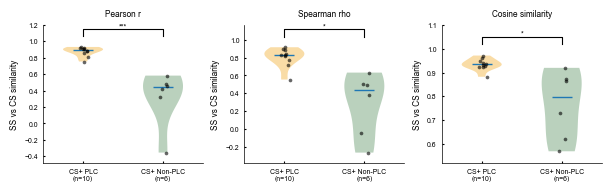

In [66]:
# Session1_full SS-vs-CS similarity:
# Group 1 = CS+ PLC
# Group 2 = non-place cells with max SS rate > 0.5 and max CS rate > 0.5

MIN_VALID_BINS_FOR_SSCS_COMBINED = 20
NONPC_SS_PEAK_THRESHOLD = 0.5
NONPC_CS_PEAK_THRESHOLD = 0.5

if 'scipy_stats' not in globals() or scipy_stats is None:
    try:
        from scipy import stats as scipy_stats
    except Exception:
        scipy_stats = None


def _get_session1full_cell_local(dataset_id, cell_idx):
    if 'combined_cell_map' in globals() and isinstance(combined_cell_map, dict):
        c = combined_cell_map.get((dataset_id, int(cell_idx)), None)
        if c is not None:
            return c
        c = _get_condition_cell(dataset_id, int(cell_idx), 'session1_full')
    if c is not None:
        return c
    return _get_condition_cell(dataset_id, int(cell_idx), 'combined')


def _safe_nanmax(arr):
    if not isinstance(arr, np.ndarray):
        return np.nan
    if arr.size == 0 or (not np.any(np.isfinite(arr))):
        return np.nan
    return float(np.nanmax(arr))


def _select_nonpc_peak_keys(ss_thr=0.5, cs_thr=0.5):
    keys = []
    rows = []
    for dataset_id, cell_idx in sorted(nonpc_keys):
        c = _get_session1full_cell_local(dataset_id, cell_idx)
        if c is None:
            continue

        ss_peak = _safe_nanmax(c.get('ss_rate_map', None))
        cs_peak = _safe_nanmax(c.get('cs_rate_map', None))

        pass_peak = bool(np.isfinite(ss_peak) and np.isfinite(cs_peak) and ss_peak > float(ss_thr) and cs_peak > float(cs_thr))
        rows.append({
            'dataset_id': str(dataset_id),
            'cell_idx': int(cell_idx),
            'ss_peak_rate': ss_peak,
            'cs_peak_rate': cs_peak,
            'pass_peak_rule': pass_peak,
        })
        if pass_peak:
            keys.append((str(dataset_id), int(cell_idx)))

    meta = pd.DataFrame(rows)
    return sorted(set(keys)), meta


def _pearson_sscs(map1, map2, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape:
        return np.nan, 0
    a = np.asarray(map1, dtype=float).ravel()
    b = np.asarray(map2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n = int(np.sum(valid))
    if n < int(min_valid_bins):
        return np.nan, n
    x = a[valid]
    y = b[valid]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan, n
    return float(np.corrcoef(x, y)[0, 1]), n


def _spearman_sscs(map1, map2, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape:
        return np.nan, 0
    a = np.asarray(map1, dtype=float).ravel()
    b = np.asarray(map2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n = int(np.sum(valid))
    if n < int(min_valid_bins):
        return np.nan, n
    x = a[valid]
    y = b[valid]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan, n
    if scipy_stats is not None:
        try:
            rho, _p = scipy_stats.spearmanr(x, y)
            return (float(rho) if np.isfinite(rho) else np.nan), n
        except Exception:
            return np.nan, n
    rx = pd.Series(x).rank(method='average').to_numpy(dtype=float)
    ry = pd.Series(y).rank(method='average').to_numpy(dtype=float)
    if np.nanstd(rx) == 0 or np.nanstd(ry) == 0:
        return np.nan, n
    return float(np.corrcoef(rx, ry)[0, 1]), n


def _cosine_sscs(map1, map2, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape:
        return np.nan, 0
    a = np.asarray(map1, dtype=float).ravel()
    b = np.asarray(map2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n = int(np.sum(valid))
    if n < int(min_valid_bins):
        return np.nan, n
    x = a[valid]
    y = b[valid]
    nx = float(np.linalg.norm(x))
    ny = float(np.linalg.norm(y))
    if nx <= 0 or ny <= 0:
        return np.nan, n
    c = float(np.dot(x, y) / (nx * ny))
    return float(np.clip(c, -1.0, 1.0)), n


def _collect_s1full_sscs_similarity(keys, group_label, metric='pearson'):
    rows = []
    for dataset_id, cell_idx in sorted(keys):
        c = _get_session1full_cell_local(dataset_id, cell_idx)
        if c is None:
            rows.append({
                'dataset_id': str(dataset_id),
                'cell_idx': int(cell_idx),
                'group': group_label,
                'metric': metric,
                'n_valid_bins': 0,
                'similarity': np.nan,
                'has_session1_full': False,
            })
            continue

        c = copy.deepcopy(c)
        _renormalize_ss_cs_maps_per_condition(c)
        ss_map = c.get('ss_norm_map', None)
        cs_map = c.get('cs_norm_map', None)

        if metric == 'pearson':
            sim, n_valid = _pearson_sscs(ss_map, cs_map, MIN_VALID_BINS_FOR_SSCS_COMBINED)
        elif metric == 'spearman':
            sim, n_valid = _spearman_sscs(ss_map, cs_map, MIN_VALID_BINS_FOR_SSCS_COMBINED)
        elif metric == 'cosine':
            sim, n_valid = _cosine_sscs(ss_map, cs_map, MIN_VALID_BINS_FOR_SSCS_COMBINED)
        else:
            raise ValueError(metric)

        rows.append({
            'dataset_id': str(dataset_id),
            'cell_idx': int(cell_idx),
            'group': group_label,
            'metric': metric,
            'n_valid_bins': int(n_valid),
            'similarity': sim,
            'has_session1_full': True,
        })

    return pd.DataFrame(rows)


def _auto_unpaired_param_first(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    n1, n2 = int(x.size), int(y.size)
    if n1 < 2 or n2 < 2 or scipy_stats is None:
        return np.nan, 'n/a', np.nan, np.nan

    def _shapiro_safe(v):
        vv = np.asarray(v, dtype=float)
        vv = vv[np.isfinite(vv)]
        if vv.size < 3:
            return np.nan
        try:
            return float(scipy_stats.shapiro(vv).pvalue)
        except Exception:
            return np.nan

    sh1 = _shapiro_safe(x)
    sh2 = _shapiro_safe(y)
    can_param = (
        n1 >= 5 and n2 >= 5 and
        np.isfinite(sh1) and sh1 >= alpha and
        np.isfinite(sh2) and sh2 >= alpha
    )

    if can_param:
        try:
            _stat, p = scipy_stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
            return float(p), 'welch_t', sh1, sh2
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.mannwhitneyu(x, y, alternative='two-sided')
        return float(p), 'mannwhitney_u', sh1, sh2
    except Exception:
        return np.nan, 'mannwhitney_u', sh1, sh2


def _sig_label_s1full(p):
    if not np.isfinite(p):
        return 'n/a'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


def _add_bracket_s1full(ax, x1, x2, y, h, label, color='black'):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], color=color, linewidth=0.8)
    ax.text((x1+x2)/2, y+h, label, ha='center', va='bottom', fontsize=5, fontname='Arial', color=color)


csplus_plc_group = sorted(csplus_keys)
nonpc_peak_group, nonpc_peak_meta = _select_nonpc_peak_keys(
    ss_thr=NONPC_SS_PEAK_THRESHOLD,
    cs_thr=NONPC_CS_PEAK_THRESHOLD,
)

print('=== Session1_full: SS-vs-CS similarity ===')
print(f'CS+ PLC cells: {len(csplus_plc_group)}')
print(f'CS+ Non-PLC cells (SS>{NONPC_SS_PEAK_THRESHOLD}, CS>{NONPC_CS_PEAK_THRESHOLD}): {len(nonpc_peak_group)}')

# Optional outlier filter (same policy: drop keys with low SS S1_1st-vs-S1_2nd r)
outlier_keys = set()
if bool(globals().get('REMOVE_LOW_SS_OUTLIER', True)) and ('df_ss_map' in globals()) and isinstance(df_ss_map, pd.DataFrame):
    thr = float(globals().get('SS_R_OUTLIER_THRESHOLD', 0.1))
    if 'corr_r' in df_ss_map.columns:
        odf = df_ss_map[np.isfinite(df_ss_map['corr_r']) & (df_ss_map['corr_r'] < thr)]
        outlier_keys = set(list(zip(odf['dataset_id'].astype(str), odf['cell_idx'].astype(int))))
    print(f'Outlier filter enabled (SS r < {thr}): removed keys={len(outlier_keys)}')

metrics = ['pearson', 'spearman', 'cosine']
s1full_sscs_frames = []
for metric_name in metrics:
    d1 = _collect_s1full_sscs_similarity(csplus_plc_group, 'CS+ PLC', metric=metric_name)
    d2 = _collect_s1full_sscs_similarity(nonpc_peak_group, 'CS+ Non-PLC', metric=metric_name)

    if len(outlier_keys) > 0:
        keep1 = [k not in outlier_keys for k in zip(d1['dataset_id'].astype(str), d1['cell_idx'].astype(int))]
        keep2 = [k not in outlier_keys for k in zip(d2['dataset_id'].astype(str), d2['cell_idx'].astype(int))]
        d1 = d1.loc[np.asarray(keep1, dtype=bool)].reset_index(drop=True)
        d2 = d2.loc[np.asarray(keep2, dtype=bool)].reset_index(drop=True)

    s1full_sscs_frames.append(pd.concat([d1, d2], ignore_index=True))

s1full_sscs_df = pd.concat(s1full_sscs_frames, ignore_index=True)

for metric_name in metrics:
    d = s1full_sscs_df[s1full_sscs_df['metric'] == metric_name]
    print(f'\n-- {metric_name} --')
    for g in ['CS+ PLC', 'CS+ Non-PLC']:
        vals = np.asarray(d.loc[d['group'] == g, 'similarity'], dtype=float)
        vals = vals[np.isfinite(vals)]
        print(f"{g}: n={len(vals)}, mean={np.nanmean(vals) if len(vals)>0 else np.nan:.3f}, median={np.nanmedian(vals) if len(vals)>0 else np.nan:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(6.0, 1.8), constrained_layout=True)
metric_titles = {'pearson': 'Pearson r', 'spearman': 'Spearman rho', 'cosine': 'Cosine similarity'}
plot_groups = ['CS+ PLC', 'CS+ Non-PLC']
plot_colors = {'CS+ PLC': '#EE9B00', 'CS+ Non-PLC': '#3A7D44'}
stats_rows = []

for ax, metric_name in zip(axes, metrics):
    d = s1full_sscs_df[s1full_sscs_df['metric'] == metric_name].copy()

    g1 = np.asarray(d.loc[d['group'] == plot_groups[0], 'similarity'], dtype=float)
    g2 = np.asarray(d.loc[d['group'] == plot_groups[1], 'similarity'], dtype=float)
    g1 = g1[np.isfinite(g1)]
    g2 = g2[np.isfinite(g2)]

    vals_list = [g1, g2]
    for pos, group_name, vals in zip([1.0, 2.0], plot_groups, vals_list):
        if len(vals) >= 3:
            parts = ax.violinplot([vals], positions=[pos], showmedians=True, showextrema=False)
            if 'cmedians' in parts:
                parts['cmedians'].set_color('#1F77B4')
                parts['cmedians'].set_linewidth(1.0)
            for b in parts['bodies']:
                b.set_facecolor(plot_colors[group_name])
                b.set_edgecolor('none')
                b.set_alpha(0.35)
        if len(vals) > 0:
            rng = np.random.default_rng(123 + len(vals))
            xj = pos + (rng.random(len(vals)) - 0.5) * 0.14
            ax.scatter(xj, vals, s=7, color='black', alpha=0.6, linewidths=0, zorder=3)

    p, test_name, sh1, sh2 = _auto_unpaired_param_first(g1, g2, alpha=0.05)
    stats_rows.append({
        'metric': metric_name,
        'test': test_name,
        'p_value': p,
        'n_csplus_plc': int(len(g1)),
        'n_csplus_nonplc': int(len(g2)),
        'shapiro_csplus_plc_p': sh1,
        'shapiro_nonpc_peak_p': sh2,
    })

    y_vals = np.concatenate([g1 if len(g1) else np.array([0.0]), g2 if len(g2) else np.array([0.0])])
    y_min = float(np.nanmin(y_vals)) if len(y_vals) else 0.0
    y_max = float(np.nanmax(y_vals)) if len(y_vals) else 1.0
    pad = max(0.05, 0.1 * (y_max - y_min) if y_max > y_min else 0.1)
    y0 = y_min - pad
    y1 = y_max + pad
    h = 0.06 * max(0.2, y1 - y0)
    _add_bracket_s1full(ax, 1.0, 2.0, y1, h, _sig_label_s1full(p), color='black')

    ax.set_title(metric_titles[metric_name], fontsize=6, fontname='Arial')
    ax.set_xticks([1.0, 2.0])
    ax.set_xticklabels([f'CS+ PLC\n(n={len(g1)})', f'CS+ Non-PLC\n(n={len(g2)})'], fontsize=4, fontname='Arial')
    ax.set_ylabel('SS vs CS similarity', fontsize=6, fontname='Arial')
    ax.tick_params(axis='both', labelsize=5)
    for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
        label.set_fontname('Arial')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0.5, 2.5)
    ax.set_ylim(y0, y1 + h + 0.05)

s1full_sscs_stats_df = pd.DataFrame(stats_rows)
print('\n=== Statistical tests: CS+ PLC vs CS+ Non-PLC (combined maps) ===')
display(s1full_sscs_stats_df)

fig_path = os.path.join(FIGURE_SAVE_FOLDER, 's1full_ss_vs_cs_similarity_csplusplc_vs_nonpc_peak_gt0p5.svg')
fig.savefig(fig_path, dpi=300)
print(f'Saved: {fig_path}')

csv_path = os.path.join(FIGURE_SAVE_FOLDER, 's1full_ss_vs_cs_similarity_csplusplc_vs_nonpc_peak_gt0p5.csv')
s1full_sscs_df.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

stats_csv_path = os.path.join(FIGURE_SAVE_FOLDER, 's1full_ss_vs_cs_similarity_csplusplc_vs_nonpc_peak_gt0p5_stats.csv')
s1full_sscs_stats_df.to_csv(stats_csv_path, index=False)
print(f'Saved: {stats_csv_path}')

nonpc_meta_path = os.path.join(FIGURE_SAVE_FOLDER, 's1full_nonpc_peak_filter_meta_gt0p5.csv')
nonpc_peak_meta.to_csv(nonpc_meta_path, index=False)
print(f'Saved: {nonpc_meta_path}')